# CS1090B Final Notebook: PBMC Cell-Type Classification Under Dataset Shift

**Group 13:** Zichen Deng, Douglas Jiang, Romy Li, Siheng Tao, Haihan Yuan  
**Primary dataset:** `GSE96583` PBMC scRNA-seq  
**Main task:** predict PBMC cell type from processed gene-expression profiles.

This final notebook is organized as a final reproducible analysis rather than as separate checkpoint material. It contains data loading, preprocessing, EDA, fixed same-split model comparison, shift-aware stress tests, baseline models, and autoencoder result summaries.

Run note: this project has been verified with the `CS1090B` conda environment. If the default `python3` kernel points to base Anaconda, `h5py` may fail to import; use the `CS1090B` environment/kernel for restart-and-run-all.


## PCA / Data / EDA Block

This block contains data loading, preprocessing, EDA, PCA-based checks, and the fixed split setup. It can be collapsed as one section.

### Data Source and Unit of Observation

`GSE96583` is a public GEO PBMC single-cell RNA-seq dataset with five count matrices:

- `batch1`: samples `A`, `B`, and `C`
- `batch2`: one `ctrl` sample and one `stim` sample

Each row in the final modeling object is one PBMC cell. The input is a processed gene-expression vector in a shared gene space, and the target is the annotated PBMC cell type. The dataset is useful for the final project because it contains both a technical batch contrast (`batch1` vs `batch2`) and a biological condition contrast inside `batch2` (`ctrl` vs `stim`).

Source links:
- GEO accession: <https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE96583>
- GEO supplementary FTP: <https://ftp.ncbi.nlm.nih.gov/geo/series/GSE96nnn/GSE96583/suppl/>


In [1]:
# Basic imports
from pathlib import Path
import gzip
import tarfile
from urllib.request import urlretrieve

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import io
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# Plot style and display settings
sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_colwidth', 120)
sc.settings.set_figure_params(dpi=110, facecolor='white')

# Find the project root
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if not (ROOT / 'data').exists():
    raise FileNotFoundError('Could not locate the project root containing the data directory.')

# Main data folders
RAW_ROOT = ROOT / 'data' / 'raw' / 'GSE96583'
PROCESSED_ROOT = ROOT / 'data' / 'processed'
FIGURE_ROOT = ROOT / 'deliverables' / 'ms2_ab' / 'figures'
RAW_ROOT.mkdir(parents=True, exist_ok=True)
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

# Dataset files and preprocessing settings
RAW_ARCHIVE_URL = 'https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE96583&format=file'
SUPPL_URL_ROOT = 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE96nnn/GSE96583/suppl'
EXPECTED_RAW_ARCHIVE_MEMBERS = [
    'GSM2560245_A.mat.gz', 'GSM2560245_barcodes.tsv.gz',
    'GSM2560246_B.mat.gz', 'GSM2560246_barcodes.tsv.gz',
    'GSM2560247_C.mat.gz', 'GSM2560247_barcodes.tsv.gz',
    'GSM2560248_2.1.mtx.gz', 'GSM2560248_barcodes.tsv.gz',
    'GSM2560249_2.2.mtx.gz', 'GSM2560249_barcodes.tsv.gz',
]
SUPPLEMENTARY_FILES = [
    'GSE96583_batch1.genes.tsv.gz',
    'GSE96583_batch1.total.tsne.df.tsv.gz',
    'GSE96583_batch2.genes.tsv.gz',
    'GSE96583_batch2.total.tsne.df.tsv.gz',
    'GSE96583_genes.txt.gz',
    'filelist.txt',
]
BATCH1_SAMPLE_MAP = {'GSM2560245_A': 'A', 'GSM2560246_B': 'B', 'GSM2560247_C': 'C'}
BATCH2_SAMPLE_MAP = {'GSM2560248_2.1': 'ctrl', 'GSM2560249_2.2': 'stim'}
MIN_GENES = 200
MIN_CELLS = 3
SCRUBLET_EXPECTED_DOUBLET_RATE = 0.08
TAIL_QUANTILE = 0.995
HVG_PER_BATCH = 2000
UMAP_MIN_DIST = 0.2
BATCH_PALETTE = {'batch1': '#133C55', 'batch2': '#D05D4E'}
CELL_PALETTE = {
    'CD4 T cells': '#1b9e77',
    'CD14+ Monocytes': '#d95f02',
    'B cells': '#7570b3',
    'CD8 T cells': '#e7298a',
    'NK cells': '#66a61e',
    'FCGR3A+ Monocytes': '#e6ab02',
    'Dendritic cells': '#a6761d',
    'Megakaryocytes': '#666666',
}


# Download one file if it is not already saved
def download_file(url, destination):
    destination = Path(destination)
    if not destination.exists():
        destination.parent.mkdir(parents=True, exist_ok=True)
        print(f'Downloading {destination.name}')
        urlretrieve(url, destination)
    return destination


# Make sure all raw GEO files are available locally
def ensure_raw_data():
    archive_path = RAW_ROOT.parent / 'GSE96583.tar'
    download_file(RAW_ARCHIVE_URL, archive_path)
    missing = [name for name in EXPECTED_RAW_ARCHIVE_MEMBERS if not (RAW_ROOT / name).exists()]
    if missing:
        print('Extracting GSE96583 tar archive')
        with tarfile.open(archive_path, 'r') as tar:
            tar.extractall(RAW_ROOT)
    for name in SUPPLEMENTARY_FILES:
        download_file(f'{SUPPL_URL_ROOT}/{name}', RAW_ROOT / name)
    return RAW_ROOT


# List the raw files and their file types
def raw_file_inventory(raw_dir=RAW_ROOT):
    rows = []
    for path in sorted(Path(raw_dir).glob('*')):
        if path.is_file():
            rows.append({
                'file': path.name,
                'size_mb': round(path.stat().st_size / (1024 * 1024), 2),
                'kind': (
                    'count matrix' if path.name.endswith(('.mat.gz', '.mtx.gz')) else
                    'barcode table' if 'barcodes' in path.name else
                    'gene metadata' if 'genes' in path.name else
                    'cell metadata' if 'tsne' in path.name else
                    'inventory' if path.name.endswith('.txt') else
                    'other'
                ),
            })
    return pd.DataFrame(rows)


# Build a small table for sample, batch, and condition info
def sample_manifest():
    return pd.DataFrame([
        {'batch_label': 'batch1', 'sample_accession': 'GSM2560245_A', 'sample_label': 'A', 'condition': 'batch1'},
        {'batch_label': 'batch1', 'sample_accession': 'GSM2560246_B', 'sample_label': 'B', 'condition': 'batch1'},
        {'batch_label': 'batch1', 'sample_accession': 'GSM2560247_C', 'sample_label': 'C', 'condition': 'batch1'},
        {'batch_label': 'batch2', 'sample_accession': 'GSM2560248_2.1', 'sample_label': 'ctrl', 'condition': 'ctrl'},
        {'batch_label': 'batch2', 'sample_accession': 'GSM2560249_2.2', 'sample_label': 'stim', 'condition': 'stim'},
    ])


# Read the gene annotation table
def read_gene_table(path):
    return pd.read_csv(path, sep='	', header=None, names=['ensembl_id', 'gene_symbol'])


# Read the barcode list for one sample
def read_barcodes(path):
    return pd.read_csv(path, sep='	', header=None).iloc[:, 0].astype(str)


# Read one compressed count matrix
def read_sparse_matrix(path):
    with gzip.open(path, 'rt') as handle:
        return io.mmread(handle).tocsr()


# Load one batch and combine its sample matrices
def load_subset(file_stems, genes_file, batch_label):
    genes = read_gene_table(RAW_ROOT / genes_file)
    adatas = []
    for stem in file_stems:
        suffix = '.mat.gz' if (RAW_ROOT / f'{stem}.mat.gz').exists() else '.mtx.gz'
        matrix = read_sparse_matrix(RAW_ROOT / f'{stem}{suffix}').T.tocsr()
        barcodes = read_barcodes(RAW_ROOT / f"{stem.split('_')[0]}_barcodes.tsv.gz")
        adata = ad.AnnData(matrix)
        adata.obs_names = [f'{stem}:{barcode}' for barcode in barcodes]
        adata.var_names = genes['gene_symbol'].astype(str)
        adata.var['ensembl_id'] = genes['ensembl_id'].astype(str).values
        adata.var_names_make_unique()
        adata.obs['sample_accession'] = stem
        adata.obs['batch_label'] = batch_label
        adatas.append(adata)
    return ad.concat(adatas, join='inner', merge='same')


# Clean obs column types after metadata is added
def finalize_obs_dtypes(adata, numeric_columns):
    for col in adata.obs.columns:
        if col in numeric_columns:
            adata.obs[col] = pd.to_numeric(adata.obs[col], errors='coerce')
        elif adata.obs[col].dtype == 'object':
            adata.obs[col] = adata.obs[col].astype('category')
    return adata


# Attach GEO metadata and labels to batch1 cells
def annotate_batch1(adata):
    meta = pd.read_csv(RAW_ROOT / 'GSE96583_batch1.total.tsne.df.tsv.gz', sep='	', index_col=0)
    meta.index = meta.index.astype(str)
    adata = adata.copy()
    barcodes = adata.obs_names.to_series().str.split(':', n=1).str[1]
    sample_codes = adata.obs['sample_accession'].map(BATCH1_SAMPLE_MAP)
    for col in meta.columns:
        adata.obs[col] = pd.NA
    for code in sorted(sample_codes.dropna().unique()):
        mask = sample_codes == code
        joined = meta[meta['batch'] == code].reindex(barcodes[mask])
        for col in meta.columns:
            adata.obs.loc[mask, col] = joined[col].values
    adata.obs['sample_label'] = sample_codes
    adata.obs['condition'] = 'batch1'
    adata.obs['cell_type'] = adata.obs['cell.type'].astype(str)
    adata.obs['dataset'] = 'GSE96583'
    return finalize_obs_dtypes(adata, ['tsne1', 'tsne2', 'cluster', 'ind'])


# Attach GEO metadata and labels to batch2 cells
def annotate_batch2(adata):
    meta = pd.read_csv(RAW_ROOT / 'GSE96583_batch2.total.tsne.df.tsv.gz', sep='	', index_col=0)
    meta.index = meta.index.astype(str)
    adata = adata.copy()
    barcodes = adata.obs_names.to_series().str.split(':', n=1).str[1]
    sample_conditions = adata.obs['sample_accession'].map(BATCH2_SAMPLE_MAP)
    for col in meta.columns:
        adata.obs[col] = pd.NA
    for stim in sorted(sample_conditions.dropna().unique()):
        mask = sample_conditions == stim
        joined = meta[meta['stim'] == stim].reindex(barcodes[mask])
        for col in meta.columns:
            adata.obs.loc[mask, col] = joined[col].values
    adata.obs['sample_label'] = sample_conditions
    adata.obs['condition'] = adata.obs['stim'].astype(str)
    adata.obs['cell_type'] = adata.obs['cell'].astype(str)
    adata.obs['dataset'] = 'GSE96583'
    return finalize_obs_dtypes(adata, ['tsne1', 'tsne2', 'cluster', 'ind'])


# Add basic QC metrics for each cell
def add_qc_metrics(adata):
    adata.var['mt'] = adata.var_names.str.upper().str.startswith('MT-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True, percent_top=None, log1p=False)
    adata.obs['sparsity'] = 1.0 - (adata.X.getnnz(axis=1) / adata.n_vars)


# Run filtering, singlet selection, and strict QC
def preprocess_batch(adata):
    summary = {'raw_cells': int(adata.n_obs), 'raw_genes': int(adata.n_vars)}
    add_qc_metrics(adata)
    sc.pp.filter_cells(adata, min_genes=MIN_GENES)
    sc.pp.filter_genes(adata, min_cells=MIN_CELLS)
    add_qc_metrics(adata)
    summary['qc_cells'], summary['qc_genes'] = int(adata.n_obs), int(adata.n_vars)

    adata = adata[adata.obs['multiplets'] == 'singlet'].copy()
    add_qc_metrics(adata)
    summary['metadata_singlet_cells'], summary['metadata_singlet_genes'] = int(adata.n_obs), int(adata.n_vars)

    scrublet_input = adata.copy()
    sc.pp.scrublet(scrublet_input, expected_doublet_rate=SCRUBLET_EXPECTED_DOUBLET_RATE, random_state=0, verbose=False)
    adata.obs['doublet_score'] = scrublet_input.obs['doublet_score'].to_numpy()
    adata.obs['predicted_doublet'] = scrublet_input.obs['predicted_doublet'].to_numpy()
    gene_cutoff = float(adata.obs['n_genes_by_counts'].quantile(TAIL_QUANTILE))
    count_cutoff = float(adata.obs['total_counts'].quantile(TAIL_QUANTILE))
    adata.obs['tail_outlier'] = (adata.obs['n_genes_by_counts'] > gene_cutoff) | (adata.obs['total_counts'] > count_cutoff)
    adata.obs['extra_doublet_flag'] = adata.obs['predicted_doublet'] | adata.obs['tail_outlier']
    adata = adata[~adata.obs['extra_doublet_flag']].copy()
    add_qc_metrics(adata)

    for col in ['cell_type', 'batch_label', 'condition', 'sample_label']:
        adata.obs[col] = adata.obs[col].astype('category')

    summary['final_cells'], summary['final_genes'] = int(adata.n_obs), int(adata.n_vars)
    summary['scrublet_flagged'] = int(scrublet_input.obs['predicted_doublet'].sum())
    summary['tail_outliers'] = int(adata.obs.get('tail_outlier', pd.Series(dtype=bool)).sum())
    return adata, summary


# Measure how much the embedding reflects batch, condition, and cell type
def compute_embedding_metrics(embedding, obs, label):
    rep = embedding[:, :20]
    nn = NearestNeighbors(n_neighbors=16).fit(rep)
    neighbor_idx = nn.kneighbors(return_distance=False)[:, 1:]
    batch = obs['batch_label'].astype(str).to_numpy()
    condition = obs['condition'].astype(str).to_numpy()
    cell_type = obs['cell_type'].astype(str).to_numpy()
    return pd.DataFrame([
        {'metric': 'silhouette_batch', 'value': float(silhouette_score(rep, batch)), 'embedding': label},
        {'metric': 'silhouette_condition', 'value': float(silhouette_score(rep, condition)), 'embedding': label},
        {'metric': 'silhouette_cell_type', 'value': float(silhouette_score(rep, cell_type)), 'embedding': label},
        {'metric': 'neighbor_same_batch', 'value': float((batch[neighbor_idx] == batch[:, None]).mean()), 'embedding': label},
        {'metric': 'neighbor_same_condition', 'value': float((condition[neighbor_idx] == condition[:, None]).mean()), 'embedding': label},
        {'metric': 'neighbor_same_cell_type', 'value': float((cell_type[neighbor_idx] == cell_type[:, None]).mean()), 'embedding': label},
    ])


# Build the shared-gene dataset and embeddings for both batches
def build_combined(batch1, batch2):
    shared_genes = batch1.var_names.intersection(batch2.var_names)
    b1_counts, b2_counts = batch1[:, shared_genes].copy(), batch2[:, shared_genes].copy()
    b1, b2 = b1_counts.copy(), b2_counts.copy()
    for a in (b1, b2):
        sc.pp.normalize_total(a, target_sum=1e4)
        sc.pp.log1p(a)
        sc.pp.highly_variable_genes(a, n_top_genes=HVG_PER_BATCH, flavor='seurat')
    hvg_genes = shared_genes[b1.var['highly_variable'].to_numpy() | b2.var['highly_variable'].to_numpy()]

    combined = ad.concat([b1, b2], join='inner', merge='same')
    combined.layers['counts'] = ad.concat([b1_counts, b2_counts], join='inner', merge='same').X.copy()
    combined.var['highly_variable'] = combined.var_names.isin(hvg_genes)
    add_qc_metrics(combined)

    embed = combined[:, combined.var['highly_variable']].copy()
    sc.pp.scale(embed, max_value=10)
    sc.tl.pca(embed, svd_solver='arpack')
    sc.pp.neighbors(embed, n_neighbors=15, n_pcs=30)
    sc.tl.umap(embed, min_dist=UMAP_MIN_DIST, random_state=0)
    combined.obsm['X_pca'] = embed.obsm['X_pca']
    combined.obsm['X_umap'] = embed.obsm['X_umap']

    import harmonypy as hm
    harmony_out = hm.run_harmony(combined.obsm['X_pca'], combined.obs, ['batch_label'], verbose=False)
    combined.obsm['X_pca_harmony'] = harmony_out.Z_corr.astype('float32', copy=False)
    tmp = ad.AnnData(obs=combined.obs.copy())
    tmp.obsm['X_pca_harmony'] = combined.obsm['X_pca_harmony']
    sc.pp.neighbors(tmp, use_rep='X_pca_harmony', n_neighbors=15)
    sc.tl.umap(tmp, min_dist=UMAP_MIN_DIST, random_state=0)
    combined.obsm['X_umap_harmony'] = tmp.obsm['X_umap']

    metrics = pd.concat([
        compute_embedding_metrics(combined.obsm['X_pca'], combined.obs, 'before_harmony'),
        compute_embedding_metrics(combined.obsm['X_pca_harmony'], combined.obs, 'after_harmony'),
    ], ignore_index=True)
    combined.uns['ms2_pipeline'] = {
        'normalization': 'per-batch normalize_total(1e4) + log1p',
        'feature_selection': f'union of top {HVG_PER_BATCH} HVGs from each batch',
        'batch_correction': 'Harmony on PCA space',
        'shared_genes': int(len(shared_genes)),
        'n_hvg': int(combined.var['highly_variable'].sum()),
    }
    return combined, int(len(shared_genes)), metrics


# Summarize cell and gene counts at each preprocessing stage
def build_stage_counts(summaries, shared_genes):
    rows = []
    for batch_label, s in summaries.items():
        rows.extend([
            {'batch_label': batch_label, 'stage': 'raw', 'cells': s['raw_cells'], 'genes': s['raw_genes']},
            {'batch_label': batch_label, 'stage': 'qc_filtered', 'cells': s['qc_cells'], 'genes': s['qc_genes']},
            {'batch_label': batch_label, 'stage': 'metadata_singlets', 'cells': s['metadata_singlet_cells'], 'genes': s['metadata_singlet_genes']},
            {'batch_label': batch_label, 'stage': 'strict_qc_final', 'cells': s['final_cells'], 'genes': s['final_genes']},
        ])
    stage_counts = pd.DataFrame(rows)
    stage_counts['shared_genes_after_qc_singlets'] = shared_genes
    return stage_counts


# Load cached outputs or rebuild the full processed dataset
def prepare_gse96583(force=False):
    ensure_raw_data()
    paths = {
        'batch1': PROCESSED_ROOT / 'GSE96583_batch1_qc_annotated_singlets.h5ad',
        'batch2': PROCESSED_ROOT / 'GSE96583_batch2_qc_annotated_singlets.h5ad',
        'combined': PROCESSED_ROOT / 'GSE96583_combined_shared_qc_singlets.h5ad',
        'stage_counts': PROCESSED_ROOT / 'GSE96583_wrangling_stage_counts.csv',
        'metrics': PROCESSED_ROOT / 'GSE96583_batch_effect_metrics.csv',
    }
    if (not force) and all(path.exists() for path in paths.values()):
        return {
            'batch1': sc.read_h5ad(paths['batch1']),
            'batch2': sc.read_h5ad(paths['batch2']),
            'combined': sc.read_h5ad(paths['combined']),
            'stage_counts': pd.read_csv(paths['stage_counts']),
            'metrics': pd.read_csv(paths['metrics']),
            'shared_genes': int(pd.read_csv(paths['stage_counts'])['shared_genes_after_qc_singlets'].iloc[0]),
            'paths': paths,
        }

    batch1 = annotate_batch1(load_subset(list(BATCH1_SAMPLE_MAP), 'GSE96583_batch1.genes.tsv.gz', 'batch1'))
    batch2 = annotate_batch2(load_subset(list(BATCH2_SAMPLE_MAP), 'GSE96583_batch2.genes.tsv.gz', 'batch2'))
    batch1, batch1_summary = preprocess_batch(batch1)
    batch2, batch2_summary = preprocess_batch(batch2)
    combined, shared_genes, metrics = build_combined(batch1, batch2)
    stage_counts = build_stage_counts({'batch1': batch1_summary, 'batch2': batch2_summary}, shared_genes)

    batch1.write_h5ad(paths['batch1'])
    batch2.write_h5ad(paths['batch2'])
    combined.write_h5ad(paths['combined'])
    stage_counts.to_csv(paths['stage_counts'], index=False)
    metrics.to_csv(paths['metrics'], index=False)

    return {
        'batch1': batch1,
        'batch2': batch2,
        'combined': combined,
        'stage_counts': stage_counts,
        'metrics': metrics,
        'shared_genes': shared_genes,
        'paths': paths,
    }


# Build legend handles for plotting
def legend_handles(order, palette, labels, alpha=0.5):
    values = set(pd.Series(labels).astype(str))
    return [
        Line2D([0], [0], marker='o', linestyle='', markersize=8, markerfacecolor=palette.get(v, '#777777'), markeredgewidth=0, alpha=min(alpha + 0.25, 1.0), label=v)
        for v in order if v in values
    ]


# Sample the same number of cells from each label
def balanced_indices(labels, random_state=0):
    labels = pd.Series(labels).astype(str)
    n = labels.value_counts().min()
    rng = np.random.default_rng(random_state)
    out = []
    values = labels.to_numpy()
    for label in labels.value_counts().index:
        choices = np.where(values == label)[0]
        out.extend(rng.choice(choices, size=n, replace=False).tolist())
    out = np.array(out)
    rng.shuffle(out)
    return out


# Limit each label to a maximum number of cells for plotting
def capped_indices(labels, max_per_label=2500, random_state=0):
    labels = pd.Series(labels).astype(str)
    rng = np.random.default_rng(random_state)
    out = []
    values = labels.to_numpy()
    for label in labels.value_counts().index:
        choices = np.where(values == label)[0]
        if len(choices) > max_per_label:
            choices = rng.choice(choices, size=max_per_label, replace=False)
        out.extend(np.asarray(choices).tolist())
    out = np.array(out)
    rng.shuffle(out)
    return out


# Draw a PCA or UMAP scatter plot with consistent colors
def draw_embedding(ax, coords, labels, palette, title, order, alpha=0.5, shuffle=False, random_state=0):
    labels = pd.Series(labels).astype(str).reset_index(drop=True)
    plot_df = pd.DataFrame({'x': coords[:, 0], 'y': coords[:, 1], 'label': labels})
    plot_df['color'] = plot_df['label'].map(lambda x: palette.get(x, '#777777'))
    if shuffle:
        plot_df = plot_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    ax.scatter(plot_df['x'], plot_df['y'], s=5, alpha=alpha, linewidths=0, c=plot_df['color'])
    ax.set_title(title)
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')


C:\Users\96398\AppData\Local\Temp\ipykernel_38080\2320481331.py:21: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=110, facecolor='white')


### Data Loading

The notebook downloads or loads everything needed for the GSE96583 analysis:

- `GSE96583.tar` for raw matrices and barcode tables
- batch-specific gene tables
- batch-specific `total.tsne.df` metadata tables
- cached processed `.h5ad` files under `data/processed` when available

The next cell either loads cached processed outputs or rebuilds them from the raw GEO files.


In [2]:
artifacts = prepare_gse96583(force=False)
inventory = raw_file_inventory()
manifest = sample_manifest()

adata_b1 = artifacts['batch1']
adata_b2 = artifacts['batch2']
adata = artifacts['combined']
stage_counts = artifacts['stage_counts']
metrics_df = artifacts['metrics']
shared_genes = artifacts['shared_genes']

print('batch1 shape:', adata_b1.shape)
print('batch2 shape:', adata_b2.shape)
print('combined shape:', adata.shape)
print('shared genes:', shared_genes)
print('pipeline:', adata.uns['ms2_pipeline'])

display(inventory)
display(manifest)
display(stage_counts)


batch1 shape: (11308, 14794)
batch2 shape: (23906, 16142)
combined shape: (35214, 14222)
shared genes: 14222
pipeline: {'batch_correction': 'Harmony on PCA space', 'feature_selection': 'union of top 2000 HVGs from each batch', 'n_hvg': 3656, 'normalization': 'per-batch normalize_total(1e4) + log1p', 'shared_genes': 14222}


,file,size_mb,kind
0,filelist.txt,0.00,inventory
1,GSE96583_batch1.genes.tsv.gz,0.25,gene metadata
2,GSE96583_batch1.total.tsne.df.tsv.gz,0.36,cell metadata
3,GSE96583_batch2.genes.tsv.gz,0.26,gene metadata
4,GSE96583_batch2.total.tsne.df.tsv.gz,0.72,cell metadata
5,GSE96583_genes.txt.gz,0.18,gene metadata
6,GSM2560245_A.mat.gz,4.89,count matrix
7,GSM2560245_barcodes.tsv.gz,0.01,barcode table
8,GSM2560246_B.mat.gz,5.22,count matrix
9,GSM2560246_barcodes.tsv.gz,0.02,barcode table


,batch_label,sample_accession,sample_label,condition
0,batch1,GSM2560245_A,A,batch1
1,batch1,GSM2560246_B,B,batch1
2,batch1,GSM2560247_C,C,batch1
3,batch2,GSM2560248_2.1,ctrl,ctrl
4,batch2,GSM2560249_2.2,stim,stim


,batch_label,stage,cells,genes,shared_genes_after_qc_singlets
0,batch1,raw,14030,32738,14222
1,batch1,qc_filtered,13385,14794,14222
2,batch1,metadata_singlets,11432,14794,14222
3,batch1,strict_qc_final,11308,14794,14222
4,batch2,raw,29065,35635,14222
5,batch2,qc_filtered,28871,16142,14222
6,batch2,metadata_singlets,24250,16142,14222
7,batch2,strict_qc_final,23906,16142,14222


### Final Processed Object Summary

The final object summary below is the compact version to use in the report. It records the number of cells, shared genes, HVGs, batches, conditions, and target classes after QC and preprocessing.


In [3]:
# Final object summary for the report and video
final_object_summary = pd.DataFrame([
    {'quantity': 'final_combined_cells', 'value': int(adata.n_obs)},
    {'quantity': 'final_shared_genes', 'value': int(adata.n_vars)},
    {'quantity': 'shared_genes_after_qc_singlets', 'value': int(shared_genes)},
    {'quantity': 'highly_variable_gene_union', 'value': int(adata.var['highly_variable'].sum())},
    {'quantity': 'batch1_cells', 'value': int((adata.obs['batch_label'].astype(str) == 'batch1').sum())},
    {'quantity': 'batch2_cells', 'value': int((adata.obs['batch_label'].astype(str) == 'batch2').sum())},
    {'quantity': 'ctrl_cells', 'value': int((adata.obs['condition'].astype(str) == 'ctrl').sum())},
    {'quantity': 'stim_cells', 'value': int((adata.obs['condition'].astype(str) == 'stim').sum())},
    {'quantity': 'cell_type_classes', 'value': int(adata.obs['cell_type'].nunique())},
])

final_object_summary.to_csv(ROOT / 'deliverables' / 'ms2_ab' / 'final_object_summary.csv', index=False)
display(final_object_summary)


,quantity,value
0,final_combined_cells,35214
1,final_shared_genes,14222
2,shared_genes_after_qc_singlets,14222
3,highly_variable_gene_union,3656
4,batch1_cells,11308
5,batch2_cells,23906
6,ctrl_cells,12097
7,stim_cells,11809
8,cell_type_classes,8


### Preprocessing Workflow

The preprocessing steps are:

1. Read each GEO matrix and attach barcode-level metadata.
2. Define `batch1`, `batch2`, `ctrl`, and `stim` from the sample manifest.
3. Apply basic QC: `min_genes >= 200`, `min_cells >= 3`.
4. Keep GEO singlets with `multiplets == 'singlet'`.
5. Remove residual doublet-like cells with Scrublet and conservative high-count / high-gene tail filtering.
6. Restrict cross-batch analyses to shared genes.
7. Normalize each batch separately with total-count normalization, apply `log1p`, select per-batch HVGs, take the HVG union, then run PCA and Harmony.

These steps create one shared-gene PBMC object for EDA and downstream modeling.


In [4]:
sample_counts = (
    adata.obs.groupby(['batch_label', 'sample_accession', 'sample_label', 'condition'], observed=True)
    .size().rename('cells').reset_index().sort_values(['batch_label', 'sample_label'])
)
cell_type_counts = adata.obs['cell_type'].value_counts().rename_axis('cell_type').reset_index(name='cells')
cell_type_counts['percent'] = 100 * cell_type_counts['cells'] / cell_type_counts['cells'].sum()
cell_type_counts['is_rare_under_2pct'] = cell_type_counts['percent'] < 2.0

sample_counts


,batch_label,sample_accession,sample_label,condition,cells
0,batch1,GSM2560245_A,A,batch1,3087
1,batch1,GSM2560246_B,B,batch1,3502
2,batch1,GSM2560247_C,C,batch1,4719
3,batch2,GSM2560248_2.1,ctrl,ctrl,12097
4,batch2,GSM2560249_2.2,stim,stim,11809


### Class Distribution and Rare Classes

The final benchmark is usable but imbalanced. Large T-cell and monocyte classes dominate, while dendritic cells and megakaryocytes remain rare.


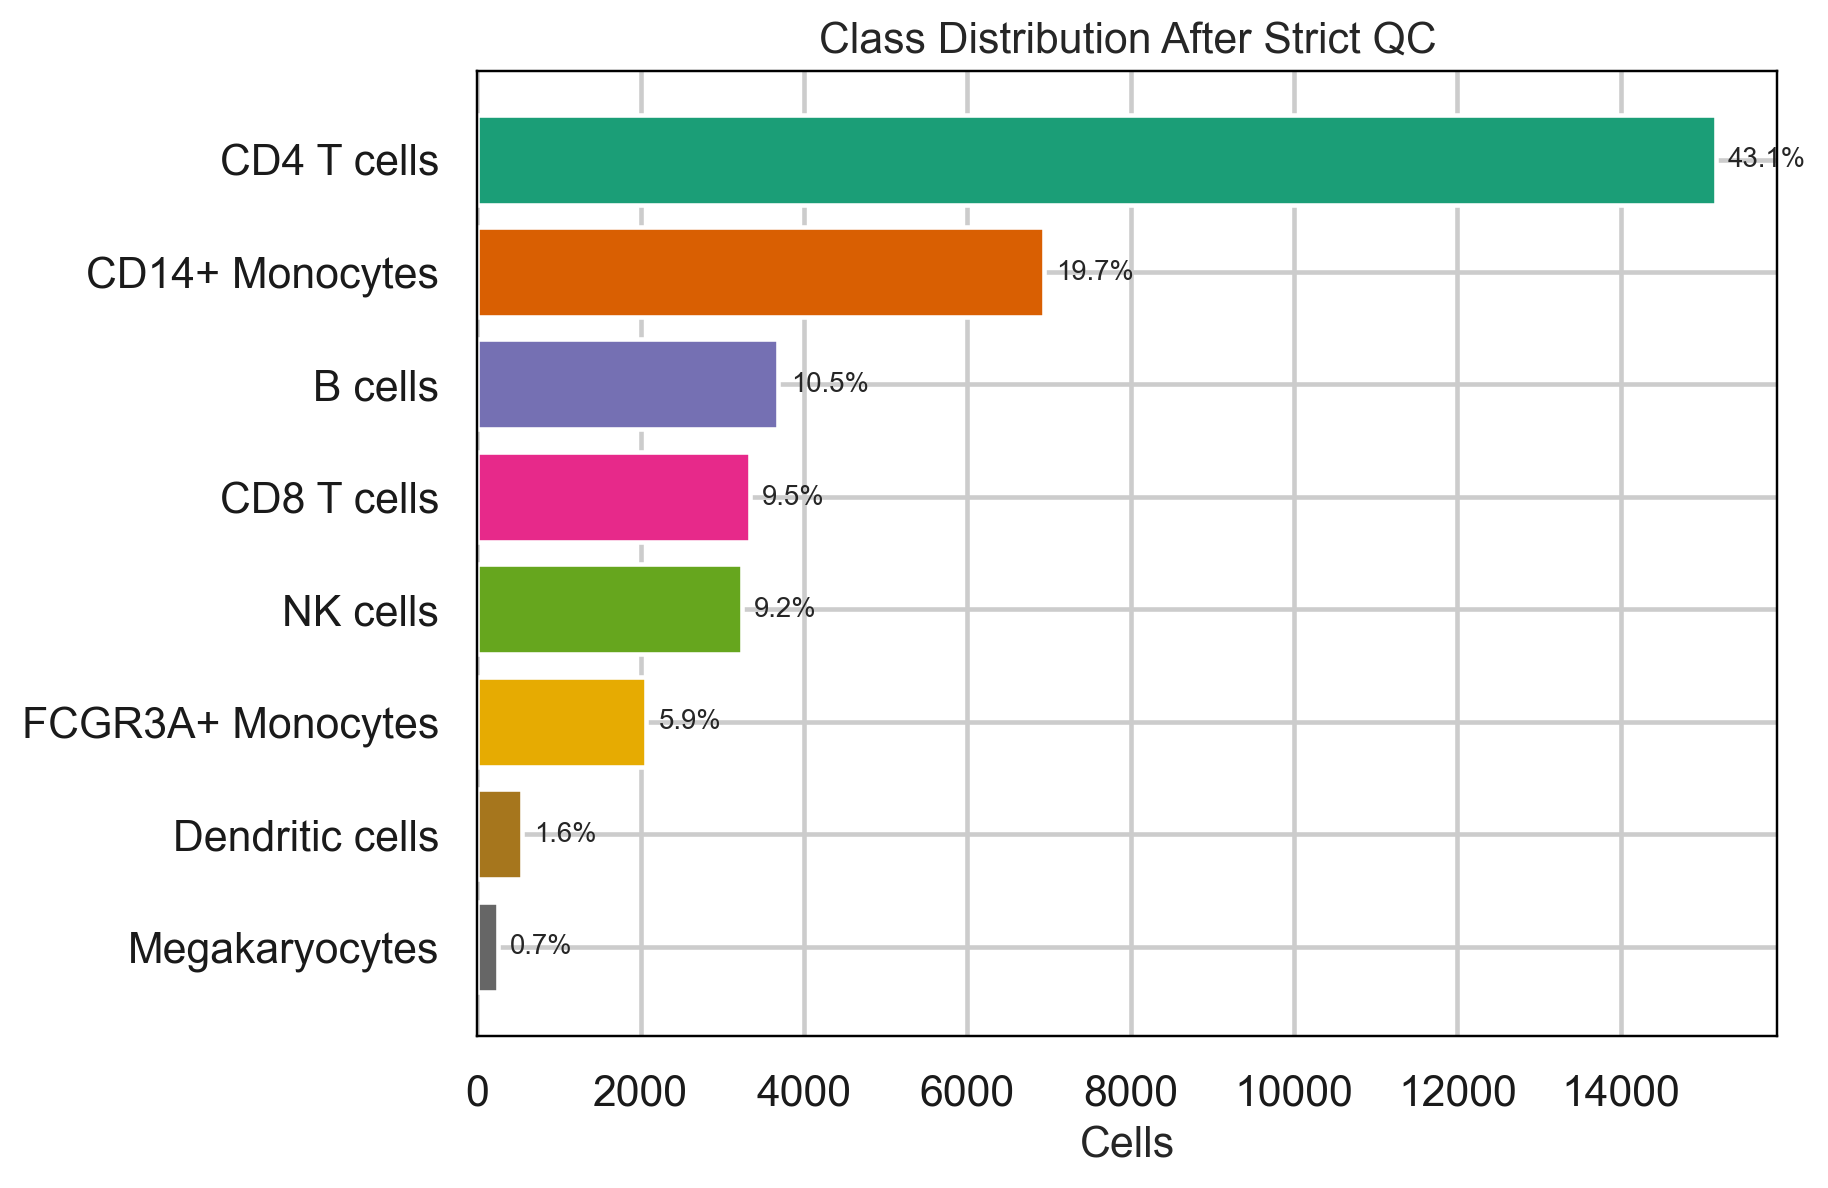

,cell_type,cells,percent,is_rare_under_2pct
6,Dendritic cells,547,1.553359,True
7,Megakaryocytes,246,0.698586,True


In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5.6))
plot_df = cell_type_counts.sort_values('cells', ascending=True)
ax.barh(plot_df['cell_type'], plot_df['cells'], color=[CELL_PALETTE.get(x, '#777777') for x in plot_df['cell_type']])
ax.set_title('Class Distribution After Strict QC')
ax.set_xlabel('Cells')
ax.set_ylabel('')
for _, row in plot_df.iterrows():
    ax.text(row['cells'] + plot_df['cells'].max() * 0.01, row['cell_type'], f"{row['percent']:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

cell_type_counts.query('is_rare_under_2pct')


### Batch, Condition, and QC Overview


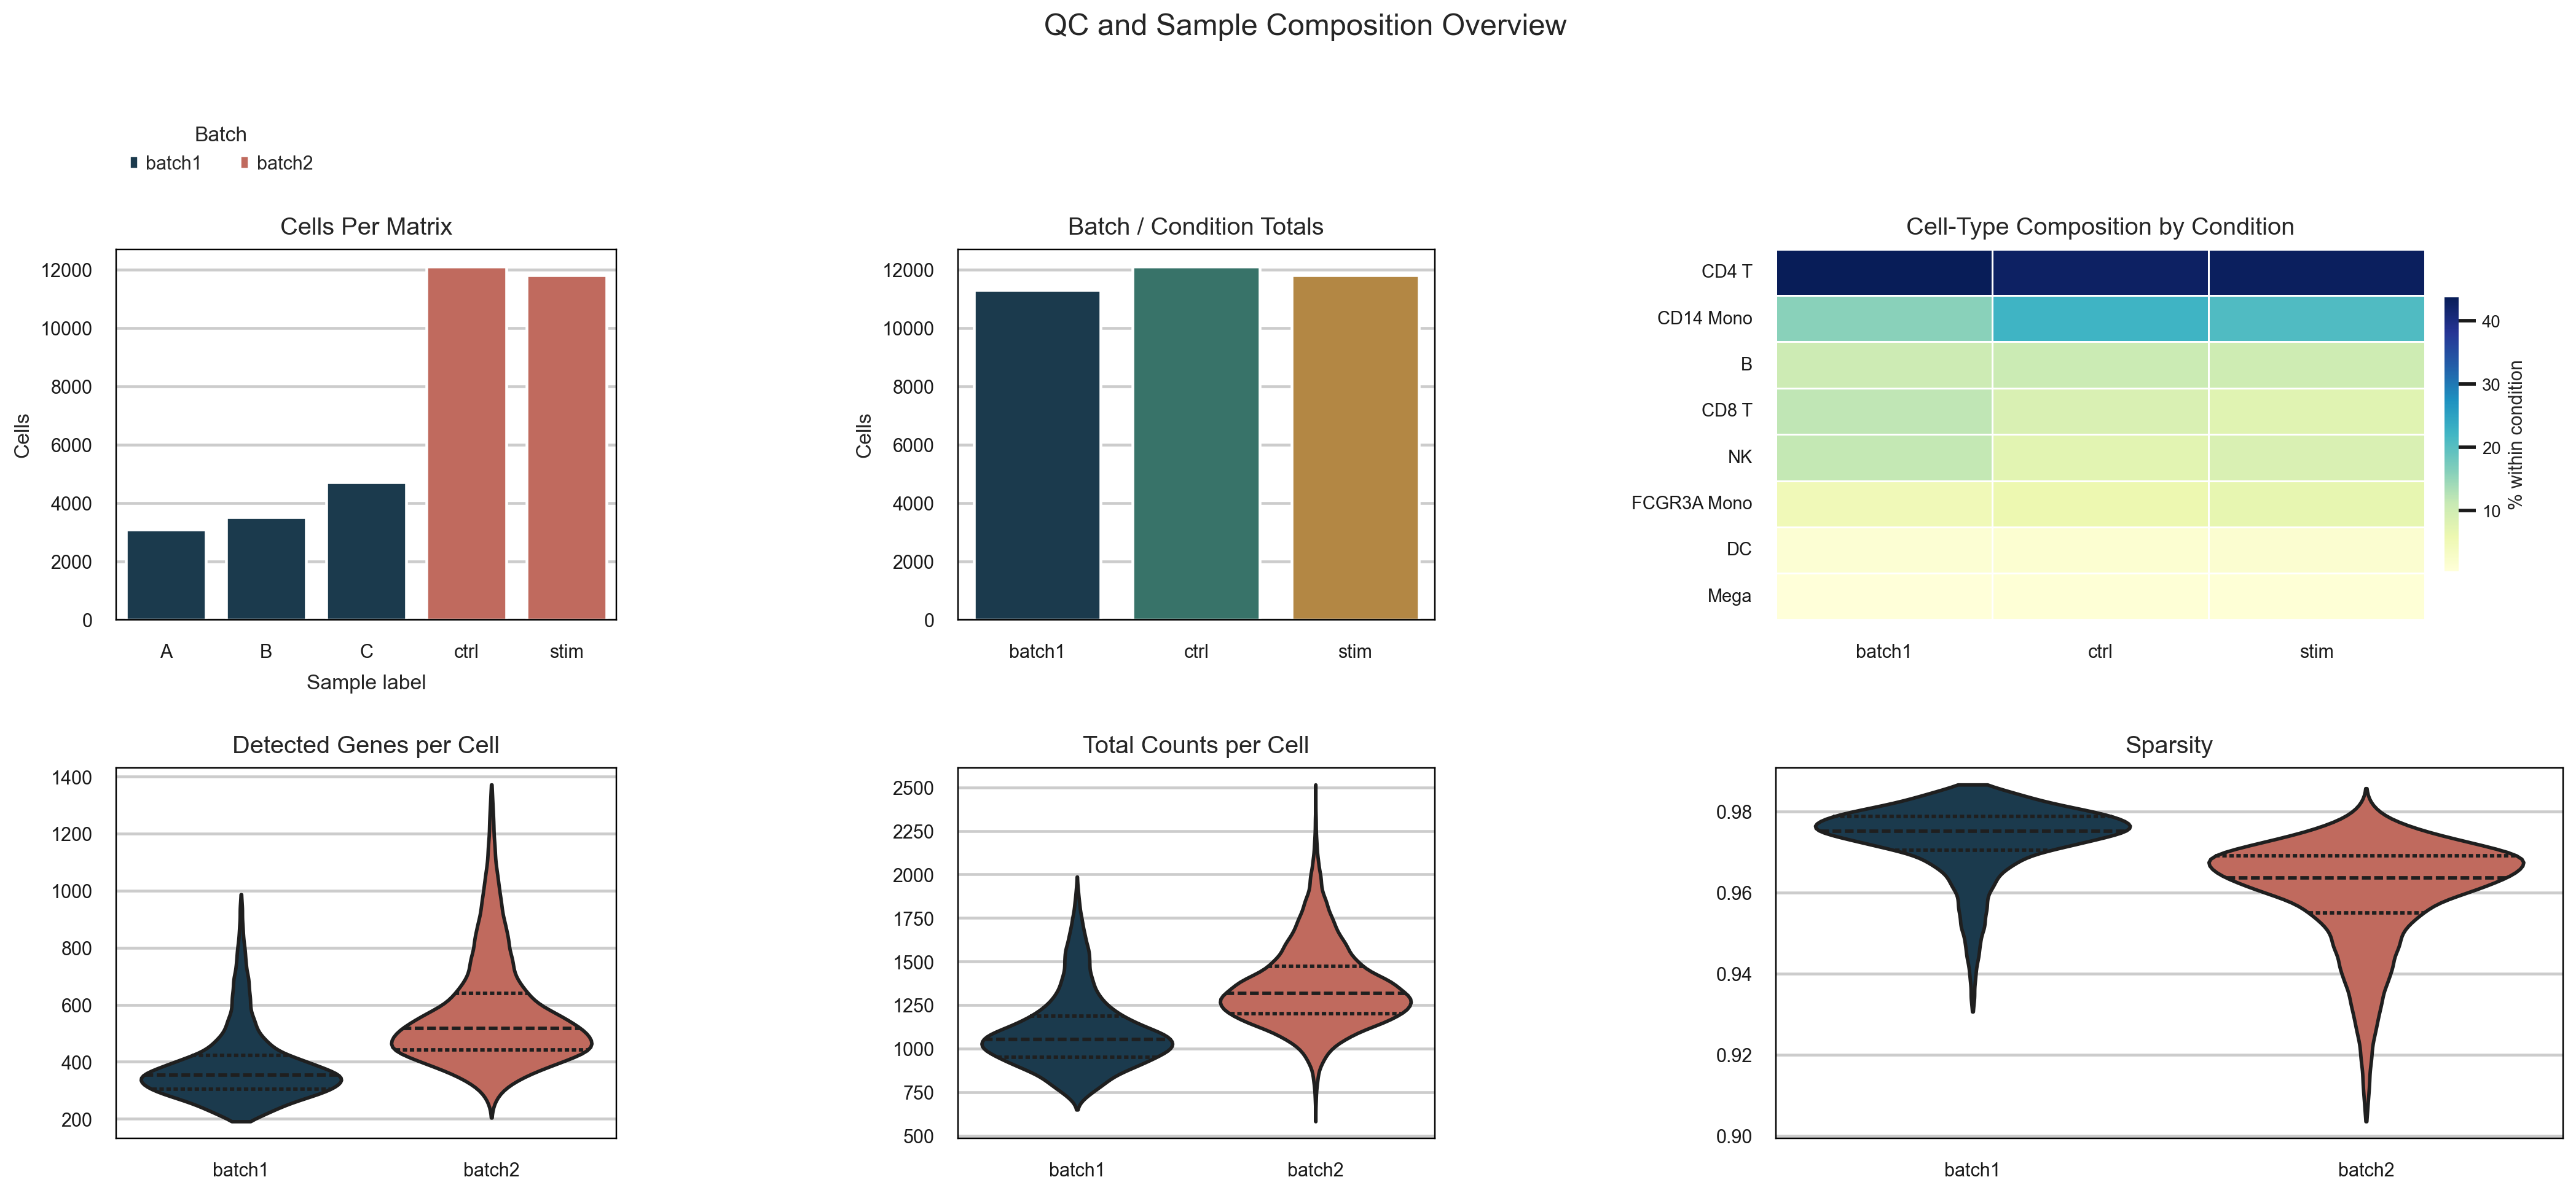

In [6]:
condition_counts = adata.obs['condition'].value_counts().rename_axis('condition').reset_index(name='cells')
composition = pd.crosstab(adata.obs['cell_type'], adata.obs['condition'], normalize='columns').mul(100)
qc_long = adata.obs[['batch_label', 'n_genes_by_counts', 'total_counts', 'sparsity']].copy()

sample_order = ['A', 'B', 'C', 'ctrl', 'stim']
condition_order = [c for c in ['batch1', 'ctrl', 'stim'] if c in composition.columns]
cell_type_order = [ct for ct in cell_type_counts['cell_type'] if ct in composition.index]
cell_type_short_labels = {
    'CD4 T cells': 'CD4 T',
    'CD14+ Monocytes': 'CD14 Mono',
    'B cells': 'B',
    'CD8 T cells': 'CD8 T',
    'NK cells': 'NK',
    'FCGR3A+ Monocytes': 'FCGR3A Mono',
    'Dendritic cells': 'DC',
    'Megakaryocytes': 'Mega',
}

sample_plot = sample_counts.copy()
sample_plot['sample_label'] = pd.Categorical(sample_plot['sample_label'], categories=sample_order, ordered=True)
sample_plot = sample_plot.sort_values('sample_label')
cond_plot = condition_counts.assign(
    condition=pd.Categorical(condition_counts['condition'], categories=condition_order, ordered=True)
).sort_values('condition')

qc_titles = {
    'n_genes_by_counts': 'Detected Genes per Cell',
    'total_counts': 'Total Counts per Cell',
    'sparsity': 'Sparsity',
}


def draw_sample_counts(ax):
    sns.barplot(
        data=sample_plot,
        x='sample_label',
        y='cells',
        hue='batch_label',
        palette=BATCH_PALETTE,
        ax=ax,
    )
    ax.set_title('Cells Per Matrix', fontsize=13, pad=8)
    ax.set_xlabel('Sample label', fontsize=11, labelpad=7)
    ax.set_ylabel('Cells', fontsize=11)
    ax.tick_params(axis='both', labelsize=10)
    handles, labels = ax.get_legend_handles_labels()
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    return handles, labels


def draw_condition_counts(ax):
    sns.barplot(
        data=cond_plot,
        x='condition',
        y='cells',
        hue='condition',
        palette=['#133C55', '#2E7D6F', '#C68B31'][:len(condition_order)],
        legend=False,
        ax=ax,
    )
    ax.set_title('Batch / Condition Totals', fontsize=13, pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('Cells', fontsize=11)
    ax.tick_params(axis='both', labelsize=10)


def draw_composition_heatmap(ax):
    composition_plot = composition.loc[cell_type_order, condition_order].rename(index=cell_type_short_labels)
    sns.heatmap(
        composition_plot,
        cmap='YlGnBu',
        linewidths=0.35,
        cbar_kws={'shrink': 0.74, 'pad': 0.025, 'label': '% within condition'},
        ax=ax,
    )
    ax.set_title('Cell-Type Composition by Condition', fontsize=13, pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=10, rotation=0)
    ax.tick_params(axis='y', labelsize=9.5, rotation=0)
    ax.collections[0].colorbar.ax.tick_params(labelsize=9)
    ax.collections[0].colorbar.ax.yaxis.label.set_size(10)


def draw_qc_violin(ax, metric):
    sns.violinplot(
        data=qc_long,
        x='batch_label',
        y=metric,
        hue='batch_label',
        palette=BATCH_PALETTE,
        cut=0,
        inner='quartile',
        legend=False,
        ax=ax,
    )
    ax.set_title(qc_titles[metric], fontsize=13, pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=10)

# One QC overview only: avoid repeating the same QC content multiple times in the executed notebook.
fig = plt.figure(figsize=(20.0, 9.2))
gs = fig.add_gridspec(
    2,
    3,
    width_ratios=[1.05, 1.0, 1.65],
    height_ratios=[1.0, 1.0],
    left=0.06,
    right=0.965,
    top=0.80,
    bottom=0.085,
    wspace=0.58,
    hspace=0.40,
)
ax1 = fig.add_subplot(gs[0, 0])
batch_handles, batch_labels = draw_sample_counts(ax1)
draw_condition_counts(fig.add_subplot(gs[0, 1]))
draw_composition_heatmap(fig.add_subplot(gs[0, 2]))
for i, metric in enumerate(['n_genes_by_counts', 'total_counts', 'sparsity']):
    draw_qc_violin(fig.add_subplot(gs[1, i]), metric)

fig.legend(
    batch_handles,
    batch_labels,
    title='Batch',
    frameon=False,
    loc='upper left',
    bbox_to_anchor=(0.062, 0.905),
    ncol=2,
    fontsize=10,
    title_fontsize=11,
    borderaxespad=0,
)
fig.suptitle('QC and Sample Composition Overview', fontsize=16, y=0.99)
fig.savefig(FIGURE_ROOT / 'qc_overview_fixed.png', dpi=220, bbox_inches='tight')
plt.show()


### Batch Effect Before Correction

Before correction, the shared-gene representation is strongly separated by `batch1` and `batch2`. This section checks three main questions:

- How imbalanced are the cell types?
- How strong is the raw batch effect?
- Is the `ctrl` vs `stim` condition difference still visible inside `batch2`?

The table below summarizes these effects in the first 20 PCA dimensions before and after Harmony.


In [7]:
metrics_summary = metrics_df.pivot(index='metric', columns='embedding', values='value').round(4)
metrics_summary


embedding,after_harmony,before_harmony
metric,,
neighbor_same_batch,0.7763,0.9950
neighbor_same_cell_type,0.9089,0.9095
neighbor_same_condition,0.7562,0.9728
silhouette_batch,-0.0163,0.0976
silhouette_cell_type,0.2106,0.1554
silhouette_condition,-0.0026,0.1134


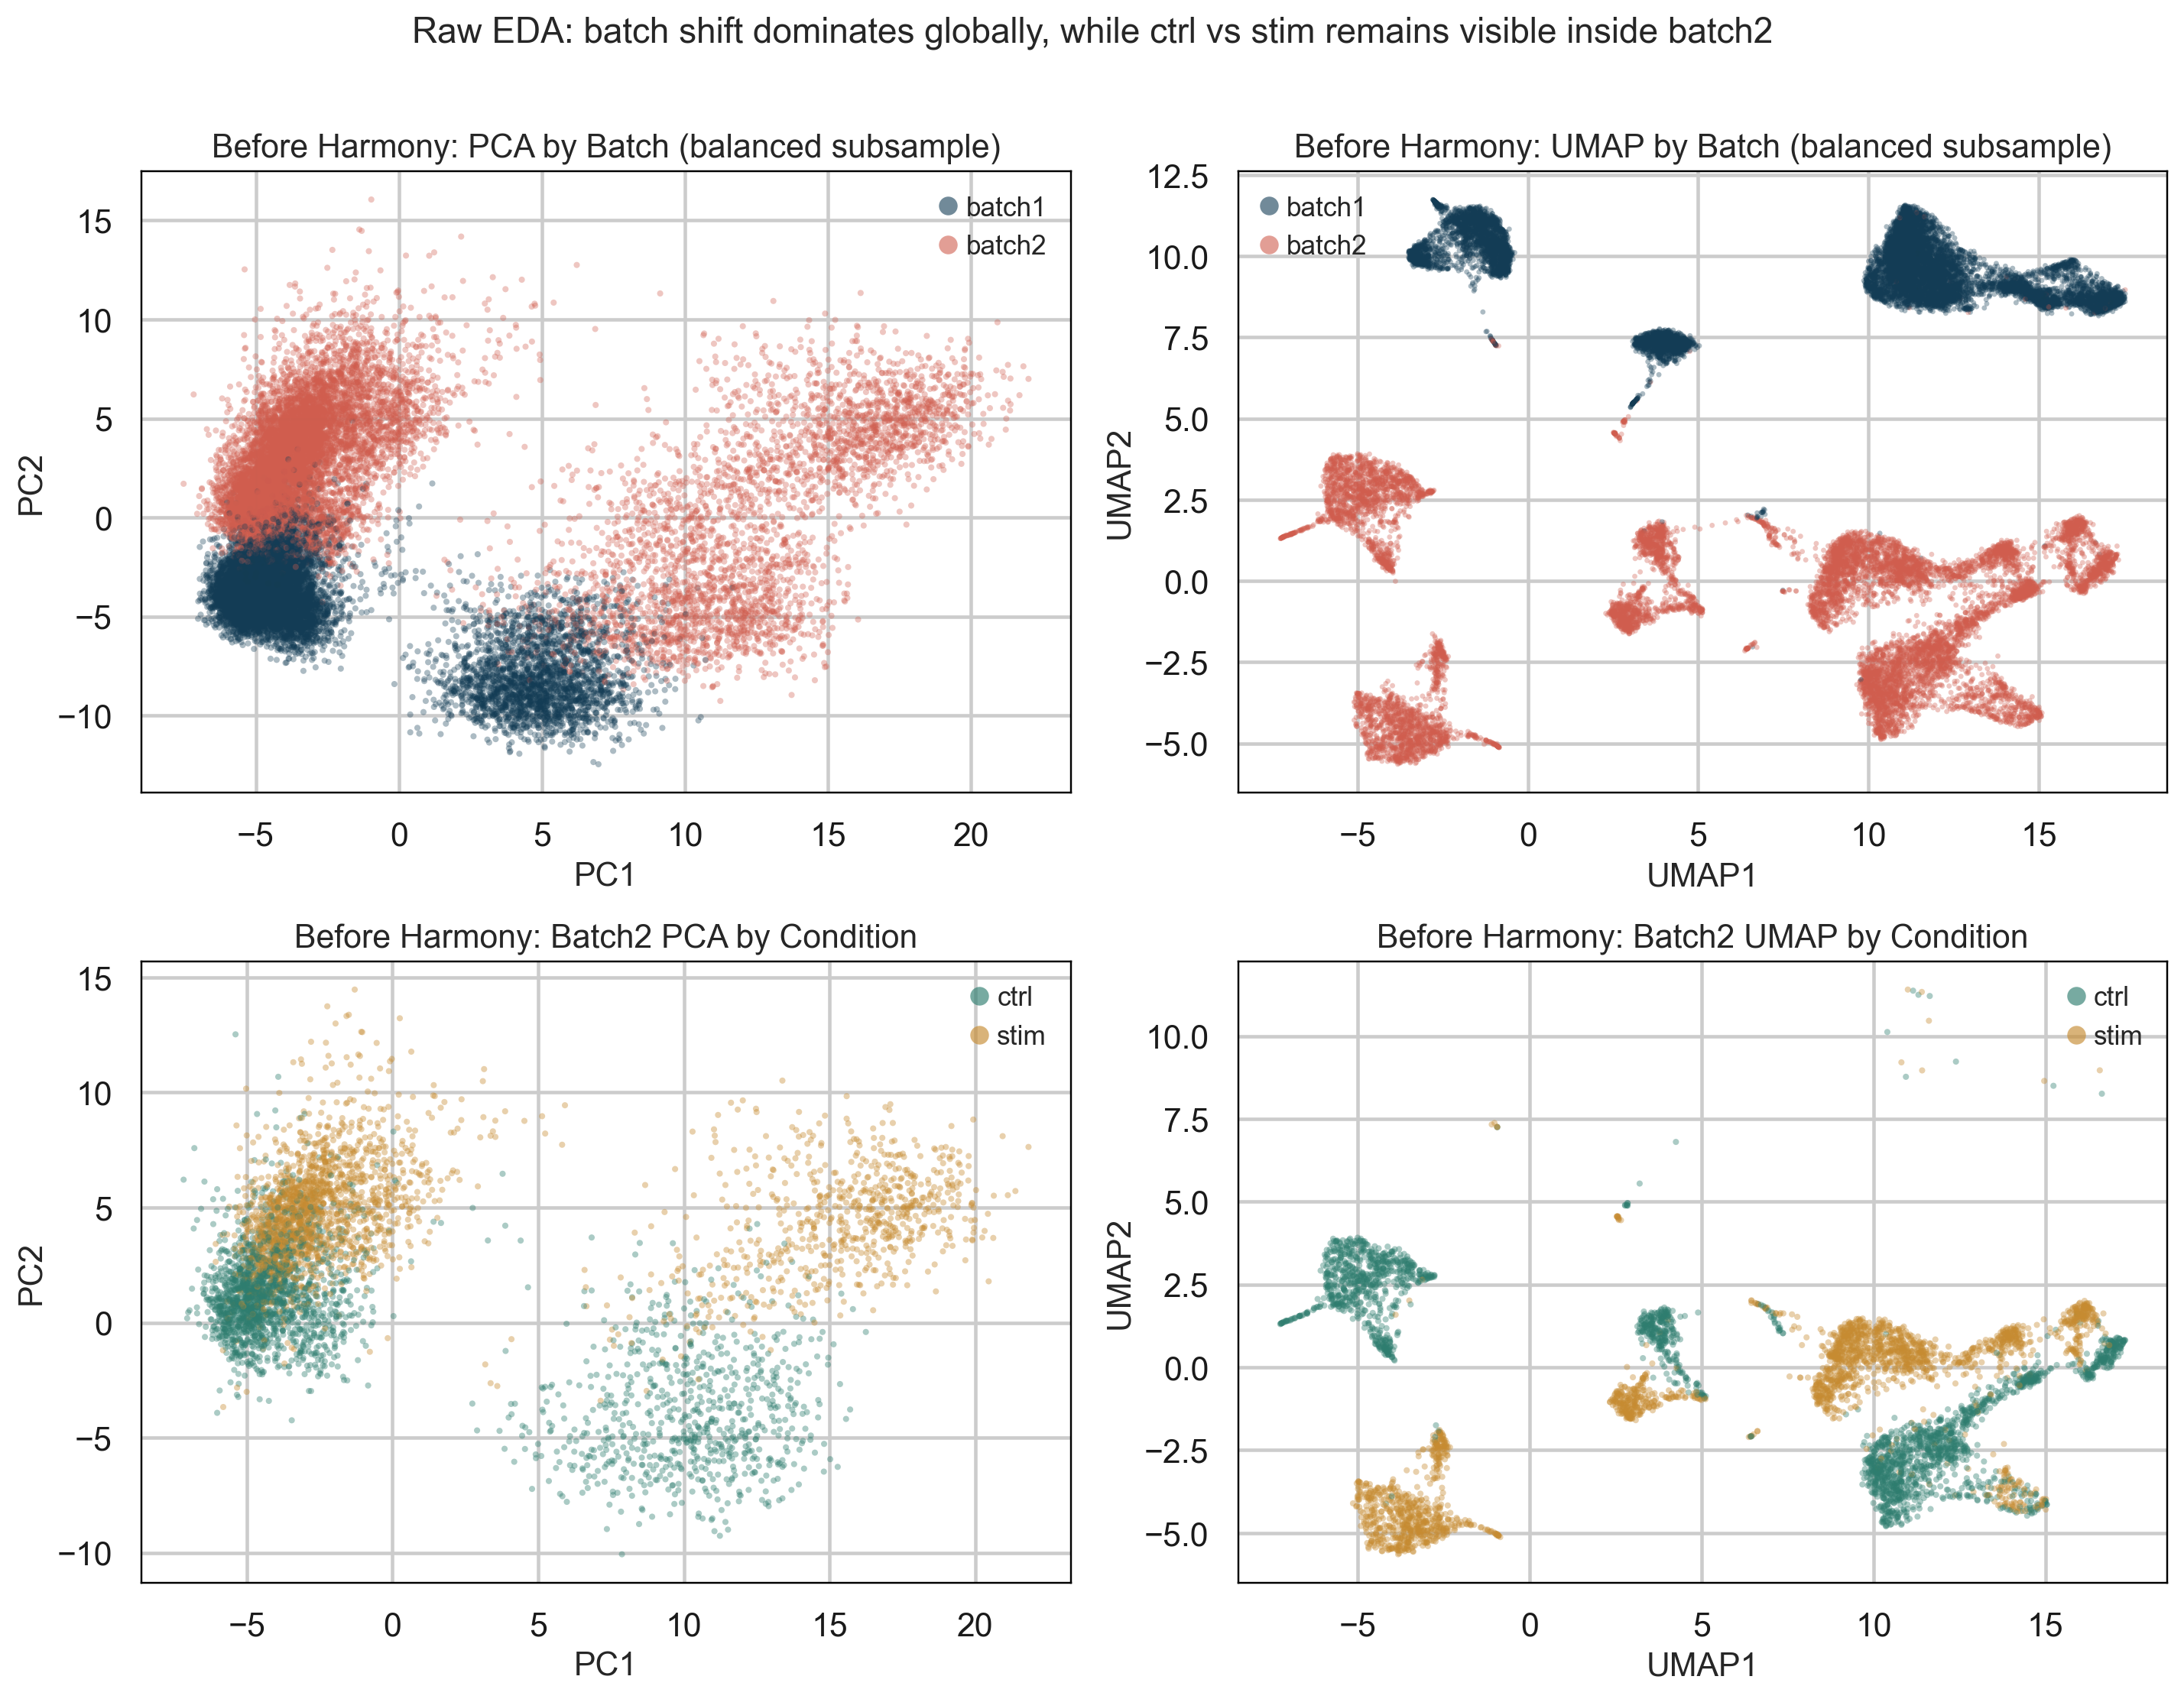

In [8]:
batch_idx = balanced_indices(adata.obs['batch_label'], random_state=0)
cell_idx = capped_indices(adata.obs['cell_type'], max_per_label=2500, random_state=1)
cell_type_order = list(adata.obs['cell_type'].value_counts().index)
condition_palette = {'ctrl': '#2E7D6F', 'stim': '#C68B31'}
batch_order = ['batch1', 'batch2']
condition_order = ['ctrl', 'stim']

batch2_mask = adata.obs['batch_label'].astype(str) == 'batch2'
batch2_condition = adata.obs.loc[batch2_mask, 'condition'].reset_index(drop=True).astype(str)
condition_idx = capped_indices(batch2_condition, max_per_label=2500, random_state=2)

fig, axes = plt.subplots(2, 2, figsize=(13.2, 10.0))

batch_pca = pd.DataFrame({
    'x': adata.obsm['X_pca'][batch_idx, 0],
    'y': adata.obsm['X_pca'][batch_idx, 1],
    'label': adata.obs['batch_label'].iloc[batch_idx].astype(str).to_numpy(),
})
batch_pca = batch_pca.sample(frac=1.0, random_state=0).reset_index(drop=True)
axes[0, 0].scatter(batch_pca['x'], batch_pca['y'], s=7, alpha=0.35, linewidths=0, c=batch_pca['label'].map(BATCH_PALETTE))
axes[0, 0].set_title('Before Harmony: PCA by Batch (balanced subsample)')
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
axes[0, 0].legend(handles=legend_handles(batch_order, BATCH_PALETTE, batch_pca['label'], alpha=0.35), frameon=False, fontsize=11.5, loc='best')

draw_embedding(
    axes[0, 1],
    adata.obsm['X_umap'][batch_idx],
    adata.obs['batch_label'].iloc[batch_idx],
    BATCH_PALETTE,
    'Before Harmony: UMAP by Batch (balanced subsample)',
    batch_order,
    alpha=0.35,
    shuffle=True,
    random_state=1,
)
axes[0, 1].legend(handles=legend_handles(batch_order, BATCH_PALETTE, adata.obs['batch_label'].iloc[batch_idx], alpha=0.35), frameon=False, fontsize=11.5, loc='best')

condition_pca = pd.DataFrame({
    'x': adata.obsm['X_pca'][batch2_mask.to_numpy(), 0][condition_idx],
    'y': adata.obsm['X_pca'][batch2_mask.to_numpy(), 1][condition_idx],
    'label': batch2_condition.iloc[condition_idx].to_numpy(),
})
condition_pca = condition_pca.sample(frac=1.0, random_state=2).reset_index(drop=True)
axes[1, 0].scatter(condition_pca['x'], condition_pca['y'], s=7, alpha=0.4, linewidths=0, c=condition_pca['label'].map(condition_palette))
axes[1, 0].set_title('Before Harmony: Batch2 PCA by Condition')
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
axes[1, 0].legend(handles=legend_handles(condition_order, condition_palette, condition_pca['label'], alpha=0.4), frameon=False, fontsize=11.5, loc='best')

condition_umap = pd.DataFrame({
    'x': adata.obsm['X_umap'][batch2_mask.to_numpy(), 0][condition_idx],
    'y': adata.obsm['X_umap'][batch2_mask.to_numpy(), 1][condition_idx],
    'label': batch2_condition.iloc[condition_idx].to_numpy(),
})
condition_umap = condition_umap.sample(frac=1.0, random_state=3).reset_index(drop=True)
axes[1, 1].scatter(condition_umap['x'], condition_umap['y'], s=7, alpha=0.4, linewidths=0, c=condition_umap['label'].map(condition_palette))
axes[1, 1].set_title('Before Harmony: Batch2 UMAP by Condition')
axes[1, 1].set_xlabel('UMAP1')
axes[1, 1].set_ylabel('UMAP2')
axes[1, 1].legend(handles=legend_handles(condition_order, condition_palette, condition_umap['label'], alpha=0.4), frameon=False, fontsize=11.5, loc='best')

fig.suptitle('Raw EDA: batch shift dominates globally, while ctrl vs stim remains visible inside batch2', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


### Harmony Batch Correction

Harmony is commonly used for batch correction in single-cell analysis. Here we run the Python wrapper `harmonypy` directly in the notebook.

The order of operations is:

- per-batch normalization
- per-batch HVG selection
- union HVG space
- PCA
- Harmony on the PCA representation
- neighbors and UMAP on Harmony-corrected PCs


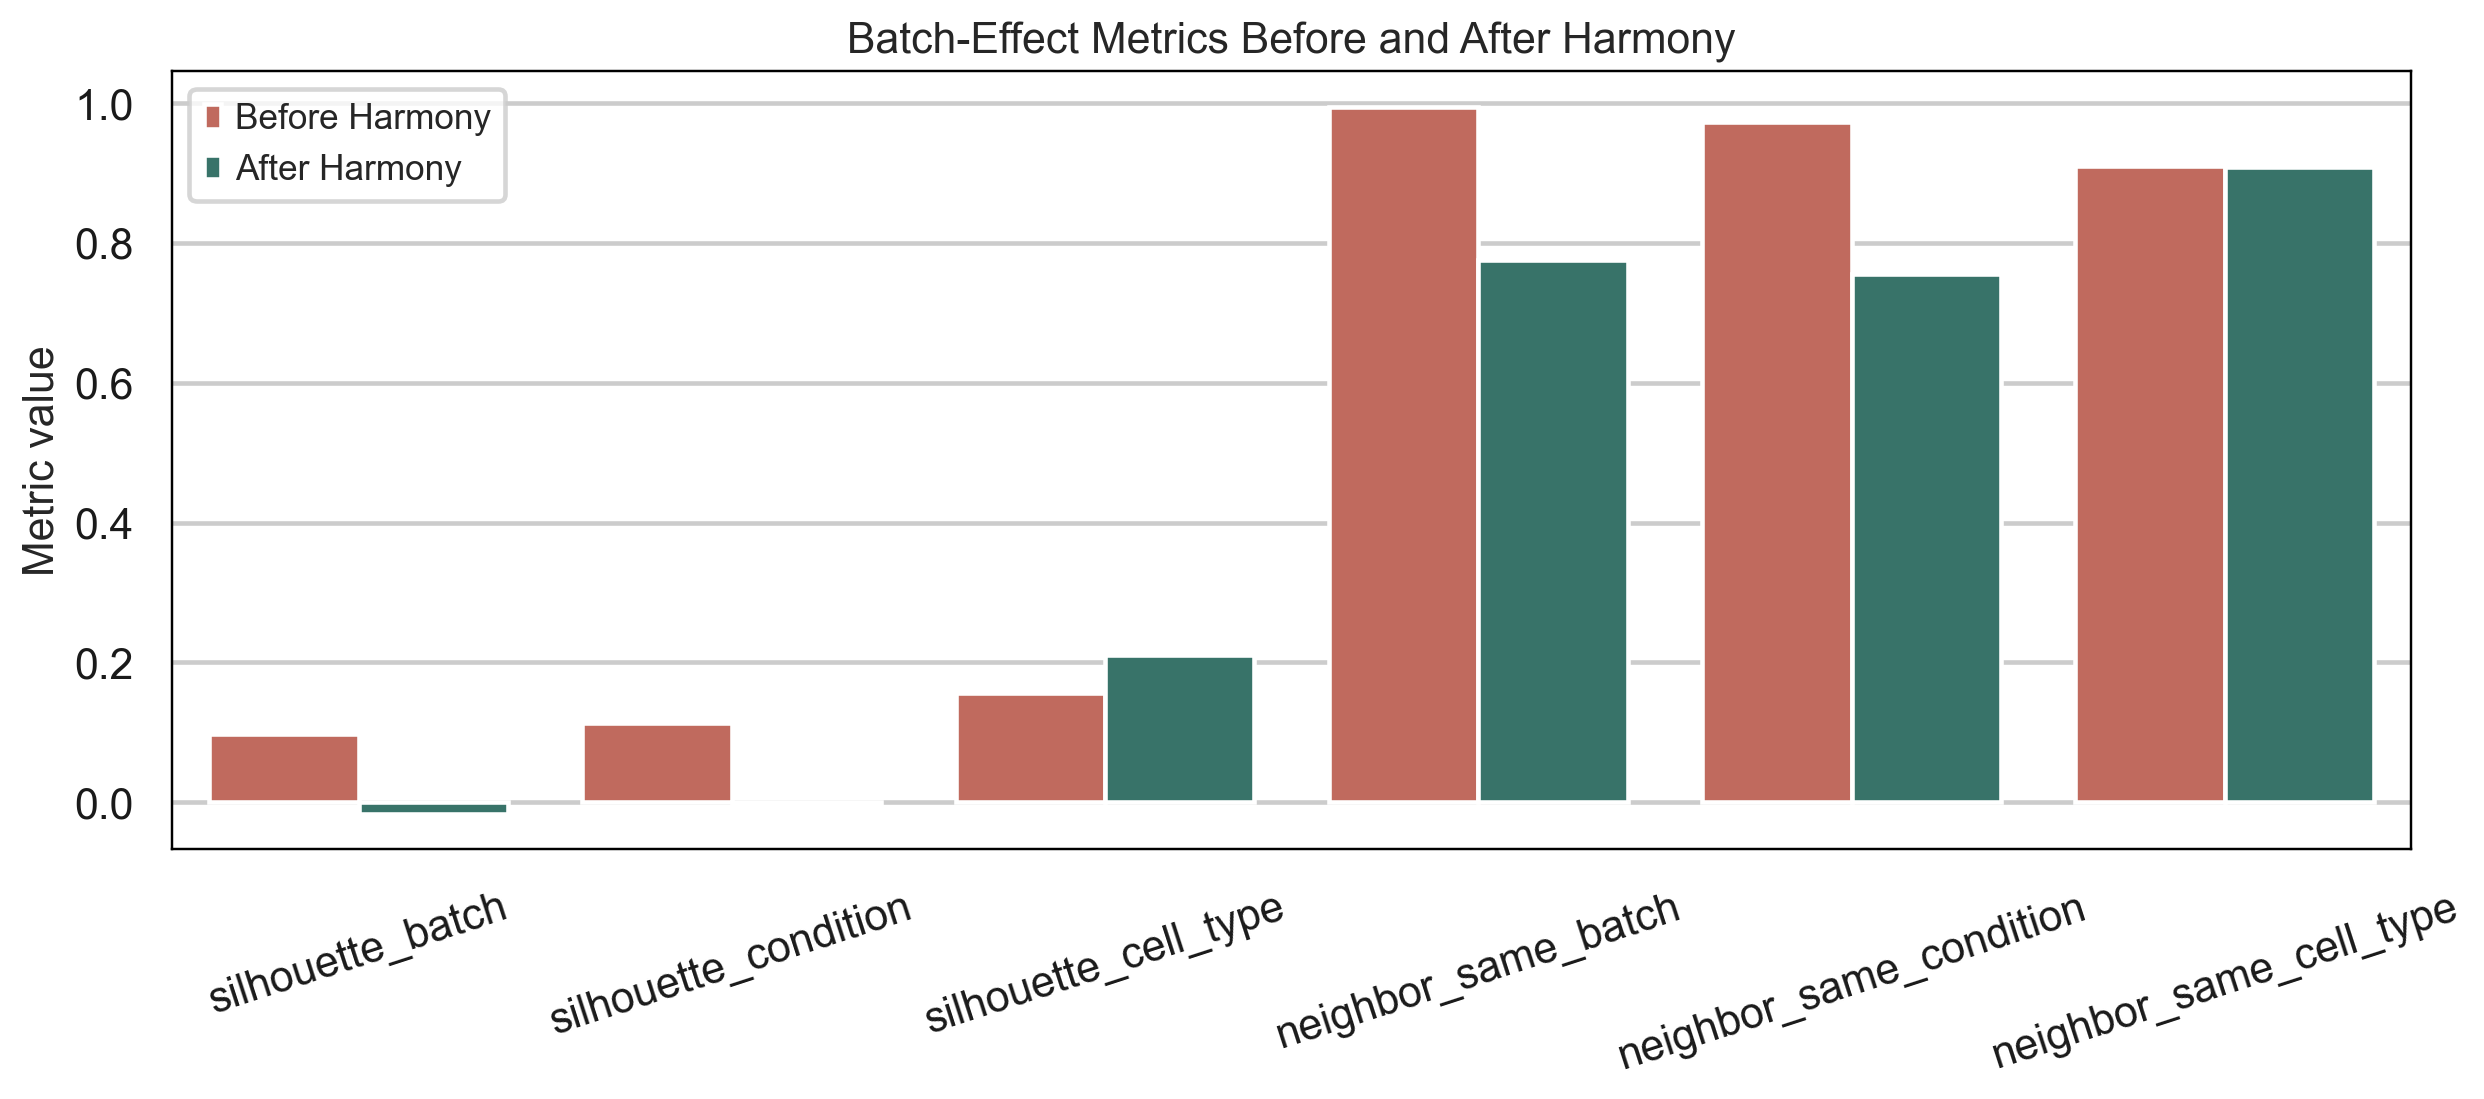

In [9]:
metric_plot = metrics_df.copy()
metric_plot['embedding'] = metric_plot['embedding'].map({'before_harmony': 'Before Harmony', 'after_harmony': 'After Harmony'})
metric_order = [
    'silhouette_batch', 'silhouette_condition', 'silhouette_cell_type',
    'neighbor_same_batch', 'neighbor_same_condition', 'neighbor_same_cell_type'
]

fig, ax = plt.subplots(figsize=(11.6, 5.2))
sns.barplot(data=metric_plot, x='metric', y='value', hue='embedding', order=metric_order, palette={'Before Harmony': '#D05D4E', 'After Harmony': '#2E7D6F'}, ax=ax)
ax.set_title('Batch-Effect Metrics Before and After Harmony')
ax.set_xlabel('')
ax.set_ylabel('Metric value')
ax.tick_params(axis='x', rotation=18)
ax.legend(title='', fontsize=11.5)
plt.tight_layout()
plt.show()


### Embedding Visualization After Harmony

The batch-colored UMAP uses a balanced subsample so batch size does not dominate the plot. The cell-type panel caps very large classes so smaller classes remain visible.


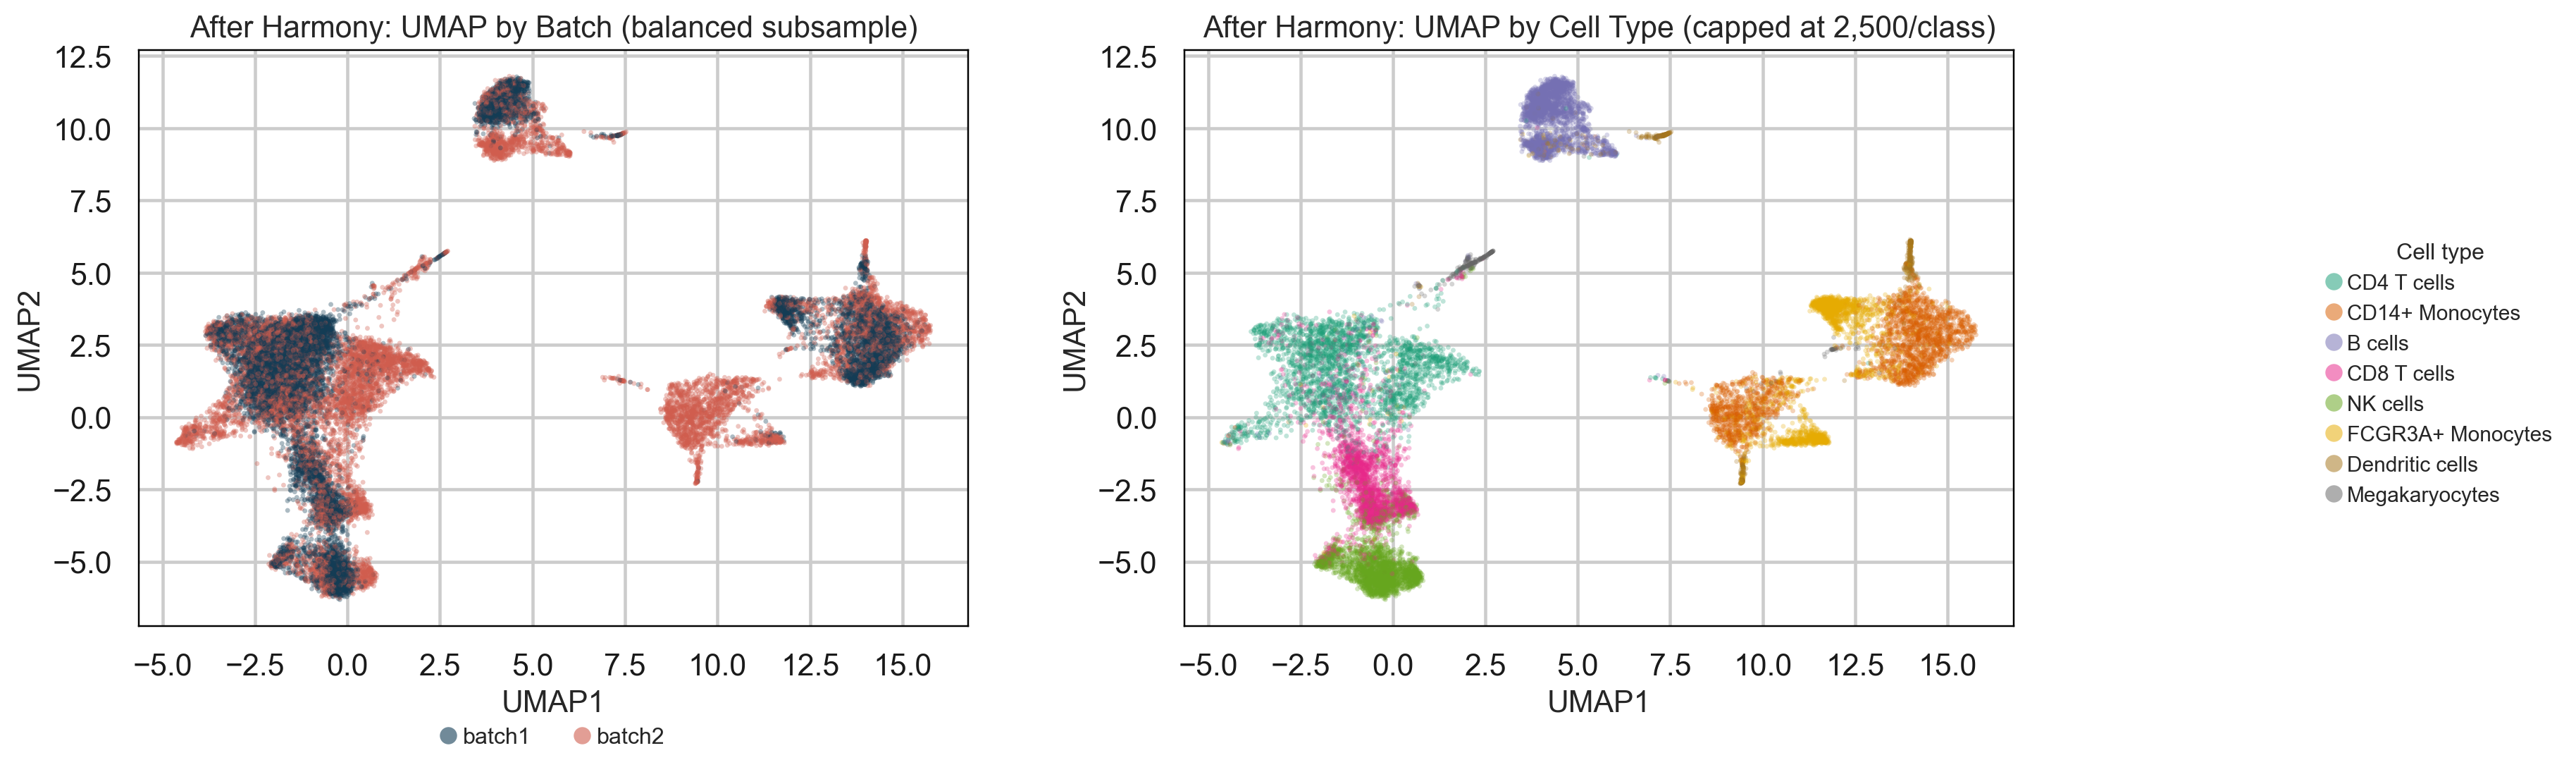

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16.8, 5.8))
draw_embedding(
    axes[0],
    adata.obsm['X_umap_harmony'][batch_idx],
    adata.obs['batch_label'].iloc[batch_idx],
    BATCH_PALETTE,
    'After Harmony: UMAP by Batch (balanced subsample)',
    ['batch1', 'batch2'],
    alpha=0.35,
    shuffle=True,
    random_state=2,
)
draw_embedding(
    axes[1],
    adata.obsm['X_umap_harmony'][cell_idx],
    adata.obs['cell_type'].iloc[cell_idx],
    CELL_PALETTE,
    'After Harmony: UMAP by Cell Type (capped at 2,500/class)',
    cell_type_order,
    alpha=0.28,
)

batch_handles = legend_handles(
    ['batch1', 'batch2'],
    BATCH_PALETTE,
    adata.obs['batch_label'].iloc[batch_idx],
    alpha=0.35,
)
axes[0].legend(
    handles=batch_handles,
    frameon=False,
    fontsize=10.5,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    borderaxespad=0,
)

cell_handles = legend_handles(cell_type_order, CELL_PALETTE, adata.obs['cell_type'].iloc[cell_idx], alpha=0.28)
fig.legend(
    cell_handles,
    [h.get_label() for h in cell_handles],
    title='Cell type',
    frameon=False,
    fontsize=9.8,
    title_fontsize=10.5,
    bbox_to_anchor=(0.99, 0.50),
    loc='center right',
    borderaxespad=0,
)
fig.subplots_adjust(left=0.06, right=0.78, top=0.86, bottom=0.22, wspace=0.26)
fig.savefig(FIGURE_ROOT / 'embedding_after_harmony_fixed.png', dpi=220, bbox_inches='tight')
plt.show()


### Key EDA Findings That Affect Modeling

- **Class imbalance:** CD4 T cells and monocytes dominate, while dendritic cells and megakaryocytes are rare. This motivates macro-F1, per-class F1, balanced accuracy, and explicit imbalance handling in classifiers.
- **Batch structure:** before correction, `batch1` and `batch2` are strongly separated in the shared-gene representation. This motivates explicit shift-aware stress tests instead of relying only on a random split.
- **Condition composition shift:** within `batch2`, `ctrl` and `stim` have similar total cell counts but different cell-type composition, especially for monocyte, CD8 T, NK, and FCGR3A+ monocyte groups.
- **Feature alignment:** using shared genes and the union of per-batch HVGs creates a common feature space for PCA, Harmony, classical baselines, and autoencoder summaries.
- **Evaluation implication:** average accuracy alone is not enough because common classes can hide rare-cell failures.


### Cross-Batch Sanity Check

Before the main model comparison, we run a simple cross-batch sanity check: `PCA (50 components) + Logistic Regression` trained on one batch and evaluated on the other. This is not the final model comparison split; it is an early stress test showing that batch transfer is harder than random same-distribution splitting.


In [11]:
from IPython.display import display
from scipy import sparse
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def to_dense(x):
    return x.toarray() if sparse.issparse(x) else np.asarray(x)


def run_pca_lr_baseline(train, test, direction):
    shared_genes = train.var_names.intersection(test.var_names)
    shared_labels = sorted(set(train.obs['cell_type']) & set(test.obs['cell_type']))

    train_use = train[train.obs['cell_type'].isin(shared_labels), shared_genes].copy()
    test_use = test[test.obs['cell_type'].isin(shared_labels), shared_genes].copy()

    x_train = to_dense(train_use.X)
    x_test = to_dense(test_use.X)
    y_train = train_use.obs['cell_type'].astype(str).to_numpy()
    y_test = test_use.obs['cell_type'].astype(str).to_numpy()

    clf = Pipeline([
        ('scale', StandardScaler(with_mean=False)),
        ('pca', PCA(n_components=50, random_state=0)),
        ('lr', LogisticRegression(max_iter=2000)),
    ])
    clf.fit(x_train, y_train)
    pred = clf.predict(x_test)

    metrics_row = {
        'direction': direction,
        'n_train': int(train_use.n_obs),
        'n_test': int(test_use.n_obs),
        'n_genes': int(train_use.n_vars),
        'accuracy': float(accuracy_score(y_test, pred)),
        'macro_f1': float(f1_score(y_test, pred, average='macro')),
        'weighted_f1': float(f1_score(y_test, pred, average='weighted')),
    }

    report = pd.DataFrame(classification_report(y_test, pred, output_dict=True)).T
    report = report.rename(columns={'f1-score': 'f1_score'})
    per_class = report.loc[shared_labels, ['precision', 'recall', 'f1_score', 'support']].reset_index()
    per_class = per_class.rename(columns={'index': 'cell_type'})
    per_class['direction'] = direction

    cm = pd.DataFrame(
        confusion_matrix(y_test, pred, labels=shared_labels),
        index=shared_labels,
        columns=shared_labels,
    )

    mistakes = []
    for true_label in shared_labels:
        for pred_label in shared_labels:
            if true_label != pred_label and cm.loc[true_label, pred_label] > 0:
                mistakes.append({
                    'direction': direction,
                    'true_label': true_label,
                    'pred_label': pred_label,
                    'count': int(cm.loc[true_label, pred_label]),
                })
    top_mistakes = pd.DataFrame(mistakes).sort_values('count', ascending=False).head(12)
    return metrics_row, per_class, cm, top_mistakes


baseline_rows = []
baseline_parts = []
baseline_confusions = {}
baseline_mistakes = []
for train, test, direction in [
    (adata_b1, adata_b2, 'batch1_to_batch2'),
    (adata_b2, adata_b1, 'batch2_to_batch1'),
]:
    row, part, cm, mistakes = run_pca_lr_baseline(train, test, direction)
    baseline_rows.append(row)
    baseline_parts.append(part)
    baseline_confusions[direction] = cm
    baseline_mistakes.append(mistakes)

baseline_metrics = pd.DataFrame(baseline_rows)
baseline_per_class = pd.concat(baseline_parts, ignore_index=True)
baseline_top_mistakes = pd.concat(baseline_mistakes, ignore_index=True)
class_order_baseline = (
    baseline_per_class.groupby('cell_type')['f1_score']
    .mean()
    .sort_values()
    .index
)
hard_classes = (
    baseline_per_class.groupby('cell_type', as_index=False)
    .agg(mean_f1=('f1_score', 'mean'), mean_recall=('recall', 'mean'), total_support=('support', 'sum'))
    .sort_values(['mean_f1', 'total_support'], ascending=[True, True])
)

display(baseline_metrics)
display(baseline_per_class.sort_values(['direction', 'f1_score']))
display(hard_classes)
display(baseline_top_mistakes)


,direction,n_train,n_test,n_genes,accuracy,macro_f1,weighted_f1
0,batch1_to_batch2,11308,23906,14222,0.839580,0.687558,0.845885
1,batch2_to_batch1,23906,11308,14222,0.883003,0.800543,0.878613


,cell_type,precision,recall,f1_score,support,direction
6,Megakaryocytes,0.289062,0.557789,0.380789,199.0,batch1_to_batch2
4,Dendritic cells,0.261116,0.830334,0.397294,389.0,batch1_to_batch2
5,FCGR3A+ Monocytes,0.742246,0.459603,0.567689,1510.0,batch1_to_batch2
3,CD8 T cells,0.650384,0.594880,0.621395,1992.0,batch1_to_batch2
7,NK cells,0.812840,0.849329,0.830684,1938.0,batch1_to_batch2
1,CD14+ Monocytes,0.856105,0.869734,0.862866,5151.0,batch1_to_batch2
0,B cells,0.951663,0.858057,0.902439,2501.0,batch1_to_batch2
2,CD4 T cells,0.947179,0.927635,0.937305,10226.0,batch1_to_batch2
14,Megakaryocytes,0.420000,0.893617,0.571429,47.0,batch2_to_batch1
11,CD8 T cells,0.741667,0.530947,0.618861,1341.0,batch2_to_batch1


,cell_type,mean_f1,mean_recall,total_support
6,Megakaryocytes,0.476109,0.725703,246.0
4,Dendritic cells,0.556061,0.712635,547.0
3,CD8 T cells,0.620128,0.562913,3333.0
5,FCGR3A+ Monocytes,0.692587,0.707400,2068.0
7,NK cells,0.853355,0.836316,3234.0
1,CD14+ Monocytes,0.892229,0.875303,6939.0
0,B cells,0.927451,0.894793,3684.0
2,CD4 T cells,0.934482,0.956019,15163.0


,direction,true_label,pred_label,count
0,batch1_to_batch2,FCGR3A+ Monocytes,CD14+ Monocytes,660
1,batch1_to_batch2,CD14+ Monocytes,Dendritic cells,654
2,batch1_to_batch2,CD4 T cells,CD8 T cells,433
3,batch1_to_batch2,CD8 T cells,CD4 T cells,399
4,batch1_to_batch2,CD8 T cells,NK cells,357
5,batch1_to_batch2,NK cells,CD8 T cells,197
6,batch1_to_batch2,B cells,Megakaryocytes,139
7,batch1_to_batch2,CD4 T cells,FCGR3A+ Monocytes,125
8,batch1_to_batch2,FCGR3A+ Monocytes,Dendritic cells,124
9,batch1_to_batch2,B cells,Dendritic cells,100


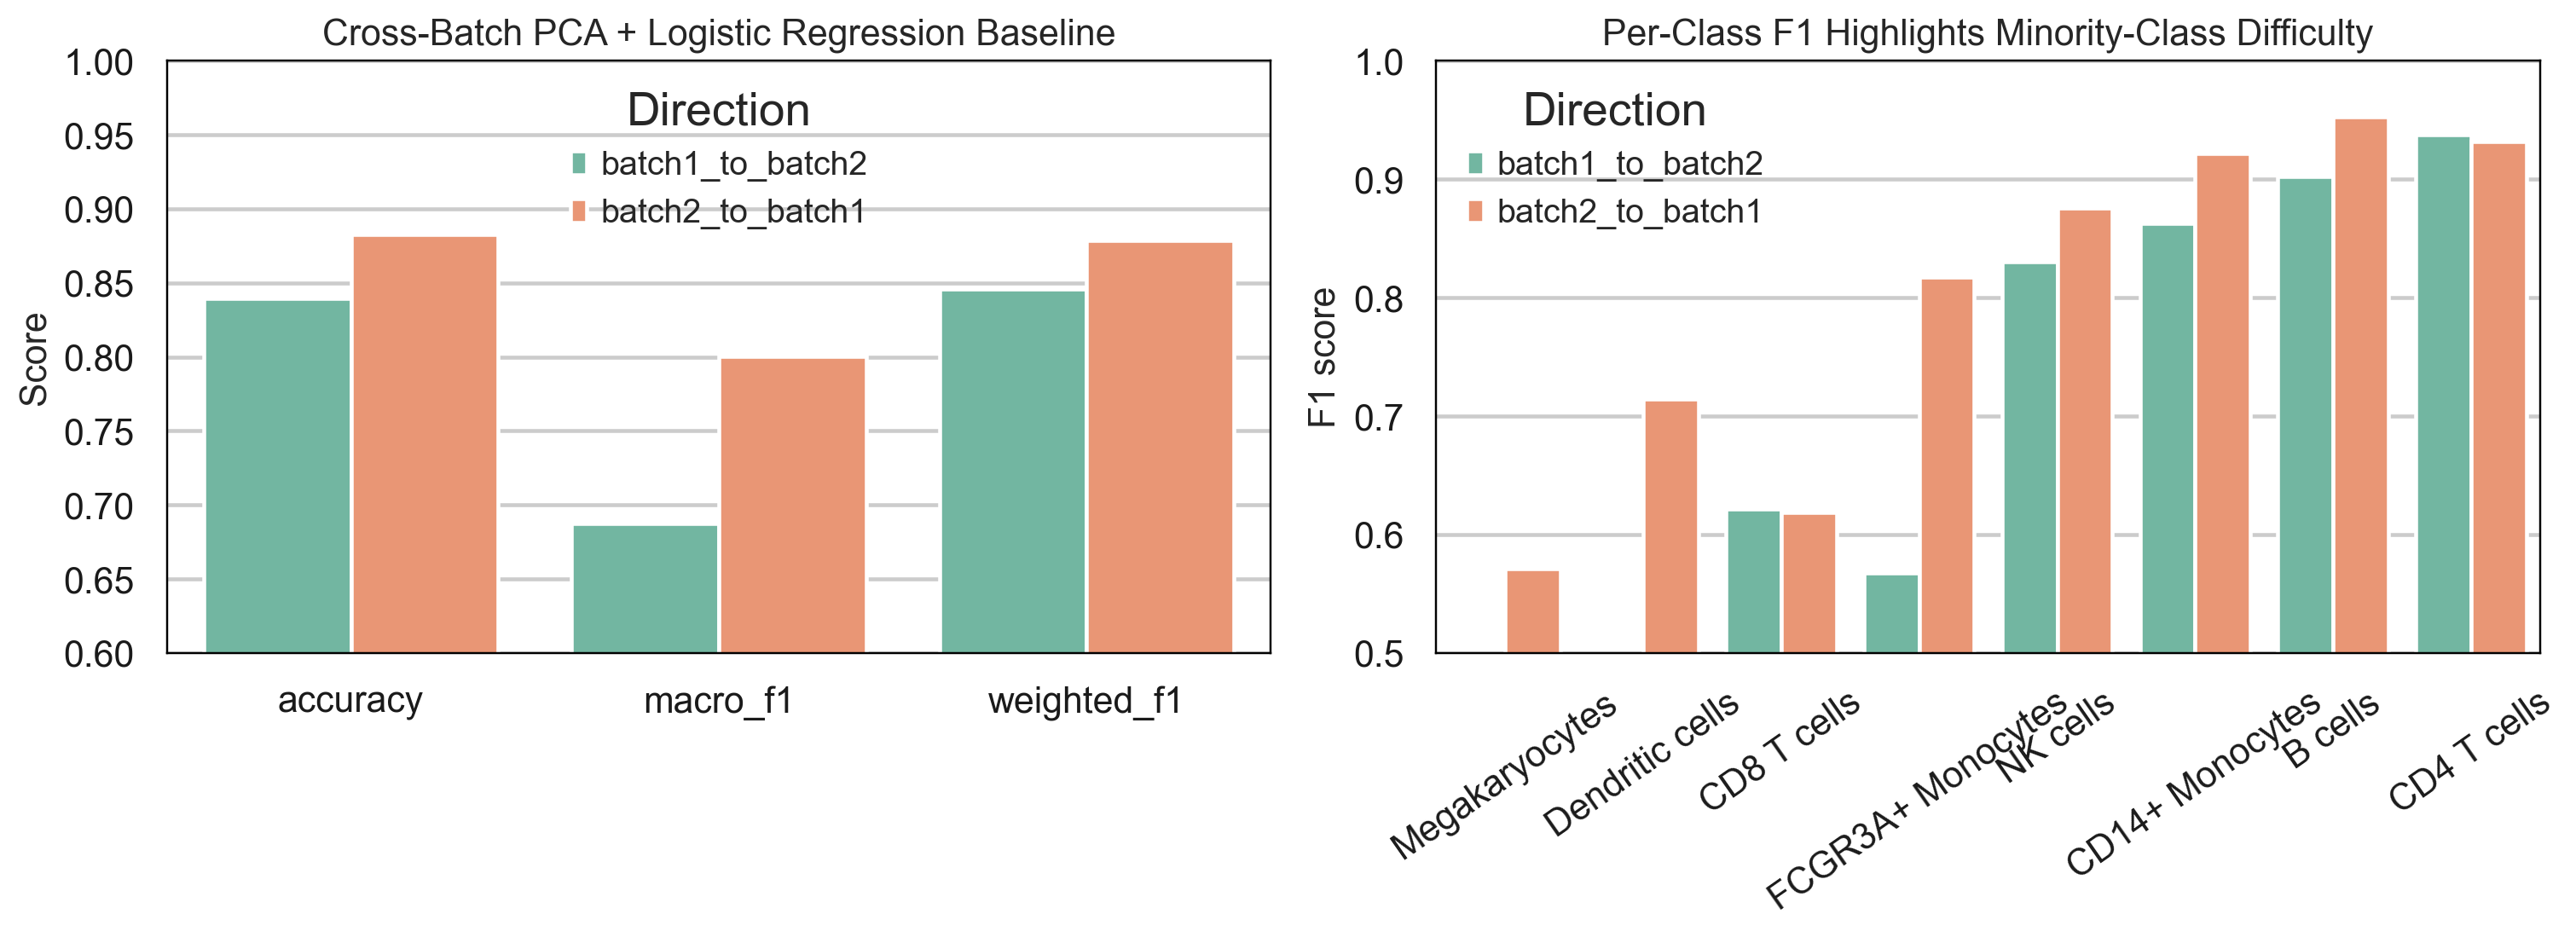

In [12]:
metric_plot = baseline_metrics.melt(
    id_vars='direction',
    value_vars=['accuracy', 'macro_f1', 'weighted_f1'],
    var_name='metric',
    value_name='score',
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
sns.barplot(data=metric_plot, x='metric', y='score', hue='direction', ax=axes[0], palette='Set2')
axes[0].set_title('Cross-Batch PCA + Logistic Regression Baseline', fontsize=14)
axes[0].set_xlabel('')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.6, 1.0)
axes[0].legend(frameon=False, title='Direction')

sns.barplot(
    data=baseline_per_class,
    x='cell_type',
    y='f1_score',
    hue='direction',
    order=class_order_baseline,
    ax=axes[1],
    palette='Set2',
)
axes[1].set_title('Per-Class F1 Highlights Minority-Class Difficulty', fontsize=14)
axes[1].set_xlabel('')
axes[1].set_ylabel('F1 score')
axes[1].set_ylim(0.5, 1.0)
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(frameon=False, title='Direction')

plt.tight_layout()
plt.show()


### Baseline Model Findings

- The first cross-batch `PCA + Logistic Regression` baseline is useful as a quick sanity check: PCA features already capture strong cell-type structure, but performance is not uniform across classes or transfer directions.
- Macro-F1 is lower than accuracy, which means minority classes matter. Common classes such as `CD4 T cells`, `B cells`, and `CD14+ Monocytes` are easier, but rare classes lower the balanced score.
- `Megakaryocytes` and `Dendritic cells` are difficult because they have the smallest support.
- `CD8 T cells` and `FCGR3A+ Monocytes` are also useful stress tests because they can overlap with nearby immune states under shift.
- The baseline comparison below extends this single-model sanity check by comparing three classifiers on the same fixed PCA feature set.


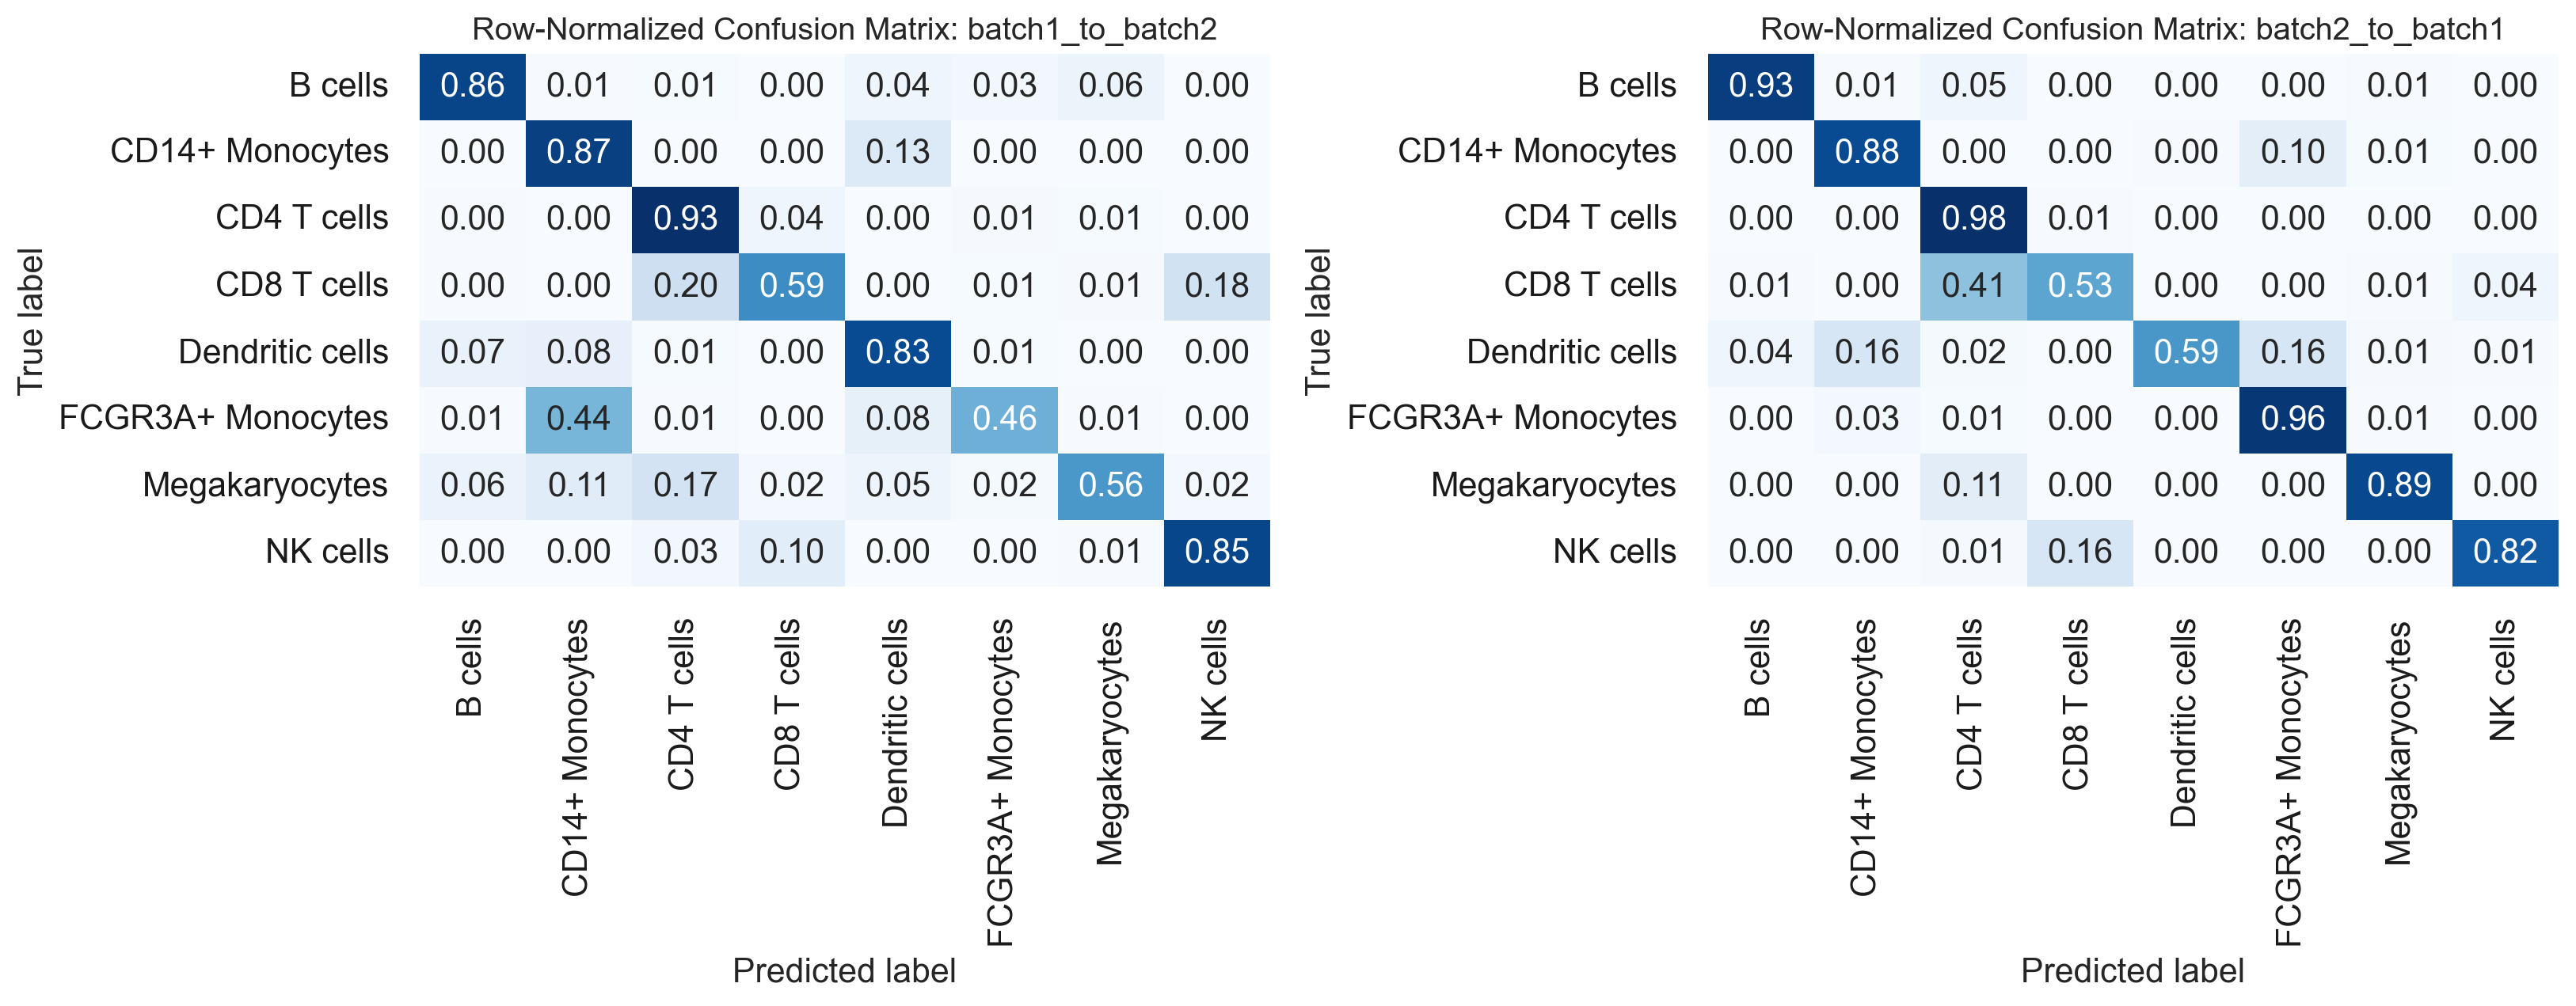

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, direction in zip(axes, ['batch1_to_batch2', 'batch2_to_batch1']):
    cm = baseline_confusions[direction]
    row_norm = cm.div(cm.sum(axis=1), axis=0)
    sns.heatmap(row_norm, annot=True, fmt='.2f', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Row-Normalized Confusion Matrix: {direction}', fontsize=13)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
plt.tight_layout()
plt.show()


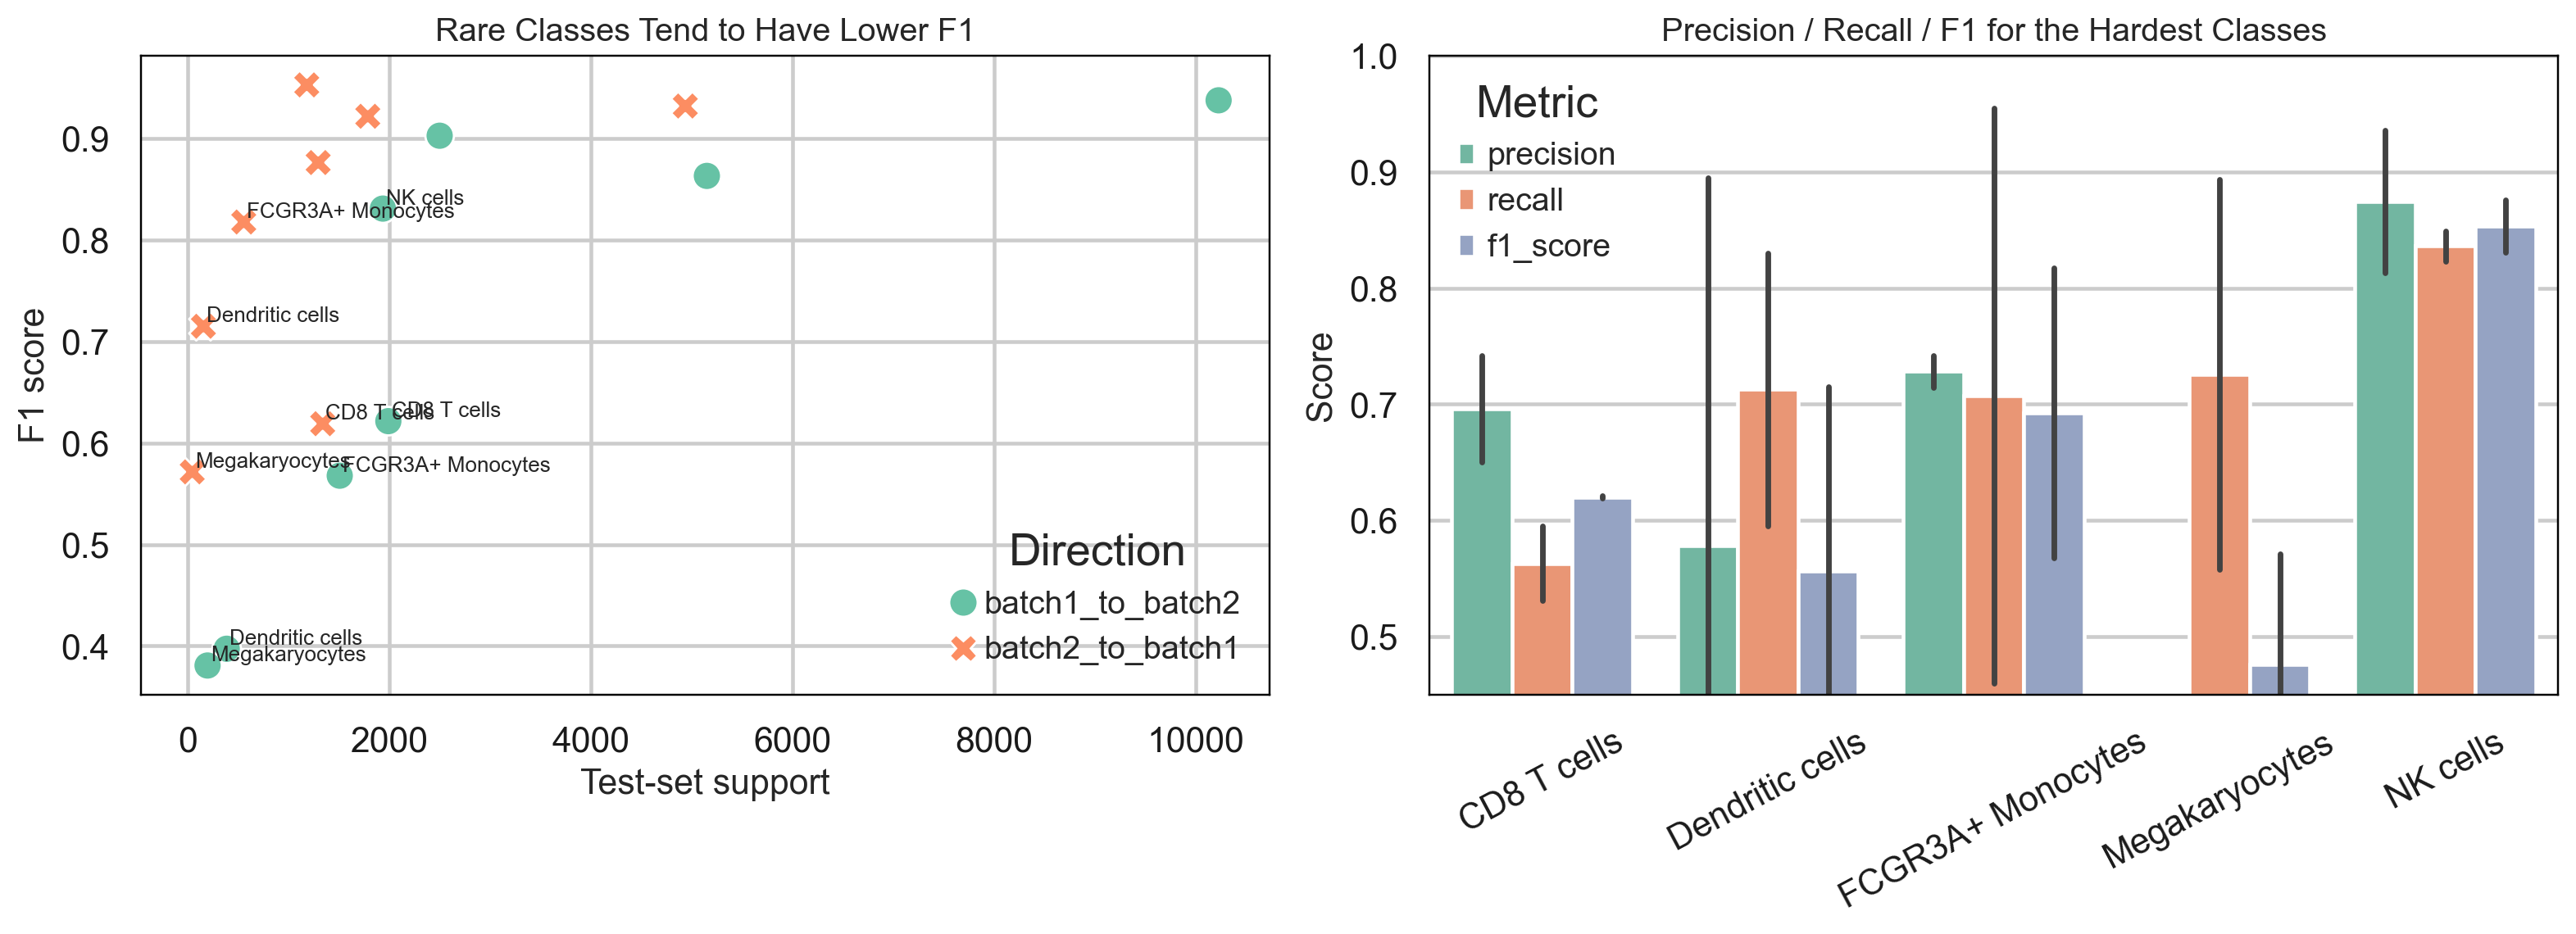

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))

sns.scatterplot(
    data=baseline_per_class,
    x='support',
    y='f1_score',
    hue='direction',
    style='direction',
    s=130,
    ax=axes[0],
    palette='Set2',
)
for _, row in baseline_per_class.iterrows():
    if row['f1_score'] < 0.85 or row['support'] < 500:
        axes[0].text(row['support'] + 30, row['f1_score'] + 0.004, row['cell_type'], fontsize=8.5)
axes[0].set_title('Rare Classes Tend to Have Lower F1', fontsize=13)
axes[0].set_xlabel('Test-set support')
axes[0].set_ylabel('F1 score')
axes[0].legend(frameon=False, title='Direction')

prf_long = baseline_per_class.melt(
    id_vars=['direction', 'cell_type'],
    value_vars=['precision', 'recall', 'f1_score'],
    var_name='metric',
    value_name='score',
)
focus_order = hard_classes['cell_type'].head(5).tolist()
sns.barplot(
    data=prf_long[prf_long['cell_type'].isin(focus_order)],
    x='cell_type',
    y='score',
    hue='metric',
    ax=axes[1],
    palette='Set2',
)
axes[1].set_title('Precision / Recall / F1 for the Hardest Classes', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.45, 1.0)
axes[1].tick_params(axis='x', rotation=28)
axes[1].legend(frameon=False, title='Metric')

plt.tight_layout()
plt.show()


### Final Project Scope

The final benchmark focuses on `GSE96583` because one public dataset already contains usable PBMC labels, a technical batch contrast, and a biological condition contrast.

We use two evaluation regimes:

- **Primary same-split comparison:** a fixed stratified `train / val / test` split used to compare PCA baselines and autoencoder variants on identical cells.
- **Shift-aware stress tests:** explicit holdout designs for `batch1 -> batch2`, `batch2 -> batch1`, `ctrl -> stim`, and `stim -> ctrl`, used to describe robustness limits under distribution shift.

This separation avoids over-claiming: the same-split DAE comparison tests representation quality under a controlled split, while the shift-aware tests quantify how much harder true batch or condition transfer can be.


In [15]:
scope_summary = pd.DataFrame([
    {
        'design_choice': 'Use GSE96583 as the primary benchmark',
        'why_this_choice': 'It contains PBMC labels, batch structure, and ctrl/stim condition structure in one study',
        'benefit_for_project': 'Cleaner interpretation and less cross-dataset label harmonization overhead',
    },
    {
        'design_choice': 'Use one fixed random split for model comparison',
        'why_this_choice': 'All PCA and DAE variants see the same train/val/test cells',
        'benefit_for_project': 'Fair same-split comparison of representation choices',
    },
    {
        'design_choice': 'Add explicit shift-aware stress tests',
        'why_this_choice': 'A stratified random split is not a true batch or condition holdout',
        'benefit_for_project': 'Keeps shift claims honest and directly addresses robustness limits',
    },
])

revised_questions = pd.DataFrame([
    {
        'question_type': 'Main prediction question',
        'text': 'Can processed PBMC gene-expression profiles predict cell type accurately while preserving minority-class performance?'
    },
    {
        'question_type': 'Representation question',
        'text': 'On the same fixed split, do denoising autoencoder representations improve over PCA features?'
    },
    {
        'question_type': 'Shift question',
        'text': 'How much does performance change when evaluation uses explicit batch or condition holdouts rather than a random split?'
    },
])

display(scope_summary)
display(revised_questions)


,design_choice,why_this_choice,benefit_for_project
0,Use GSE96583 as the primary benchmark,"It contains PBMC labels, batch structure, and ctrl/stim condition structure in one study",Cleaner interpretation and less cross-dataset label harmonization overhead
1,Use one fixed random split for model comparison,All PCA and DAE variants see the same train/val/test cells,Fair same-split comparison of representation choices
2,Add explicit shift-aware stress tests,A stratified random split is not a true batch or condition holdout,Keeps shift claims honest and directly addresses robustness limits


,question_type,text
0,Main prediction question,Can processed PBMC gene-expression profiles predict cell type accurately while preserving minority-class performance?
1,Representation question,"On the same fixed split, do denoising autoencoder representations improve over PCA features?"
2,Shift question,How much does performance change when evaluation uses explicit batch or condition holdouts rather than a random split?


C:\Users\96398\AppData\Local\Temp\ipykernel_38080\589543502.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch2_only.obs.groupby(['condition', 'cell_type']).size().reset_index(name='cells')


condition,ctrl,stim,ctrl_minus_stim,ctrl_to_stim_ratio
cell_type,,,,
CD14+ Monocytes,2702,2449,253,1.103307
CD8 T cells,1070,922,148,1.160521
NK cells,904,1034,-130,0.874275
FCGR3A+ Monocytes,710,800,-90,0.887500
B cells,1284,1217,67,1.055053
CD4 T cells,5145,5081,64,1.012596
Dendritic cells,188,201,-13,0.935323
Megakaryocytes,94,105,-11,0.895238


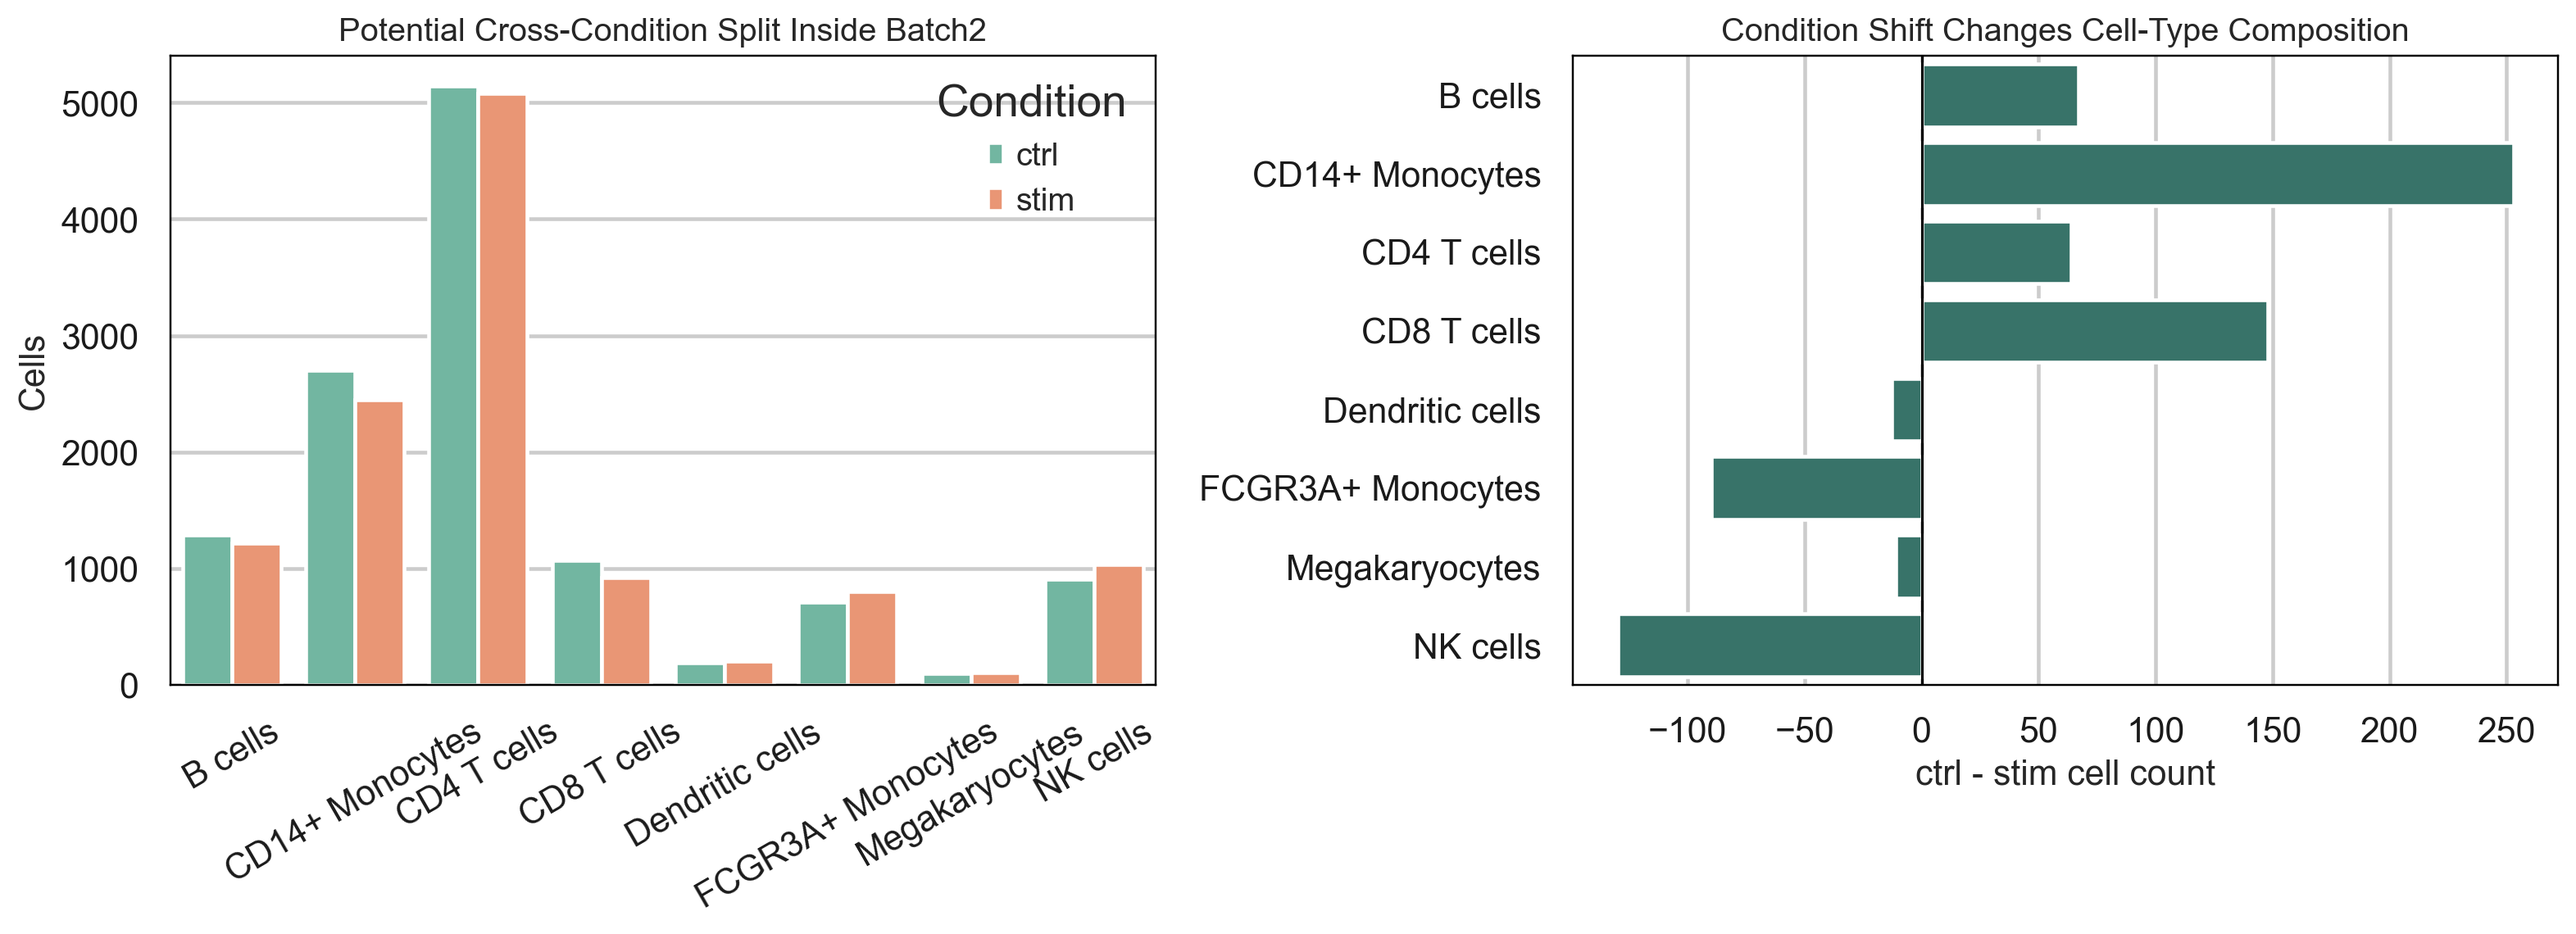

In [16]:
batch2_only = adata[adata.obs['batch_label'] == 'batch2'].copy()
cross_condition_counts = (
    batch2_only.obs.groupby(['condition', 'cell_type']).size().reset_index(name='cells')
)
cross_condition_pivot = cross_condition_counts.pivot(index='cell_type', columns='condition', values='cells').fillna(0).astype(int)
cross_condition_pivot['ctrl_minus_stim'] = cross_condition_pivot.get('ctrl', 0) - cross_condition_pivot.get('stim', 0)
cross_condition_pivot['ctrl_to_stim_ratio'] = (
    cross_condition_pivot.get('ctrl', 0) / cross_condition_pivot.get('stim', 1).replace(0, np.nan)
)
display(cross_condition_pivot.sort_values('ctrl_minus_stim', key=lambda s: s.abs(), ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))
sns.barplot(data=cross_condition_counts, x='cell_type', y='cells', hue='condition', ax=axes[0], palette='Set2')
axes[0].set_title('Potential Cross-Condition Split Inside Batch2', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Cells')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(frameon=False, title='Condition')

delta_plot = cross_condition_pivot.reset_index()[['cell_type', 'ctrl_minus_stim']].sort_values('ctrl_minus_stim')
sns.barplot(data=delta_plot, x='ctrl_minus_stim', y='cell_type', ax=axes[1], color='#2E7D6F')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Condition Shift Changes Cell-Type Composition', fontsize=13)
axes[1].set_xlabel('ctrl - stim cell count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### PCA Representation and Split Checks

This block groups the fixed-split PCA setup and the shift-aware PCA stress tests. It can be collapsed as one section in Jupyter Lab.

### Primary Same-Split Train / Validation / Test Split

This split is the controlled comparison split for PCA baselines and autoencoder variants. It is stratified by cell type and fixed with `random_state=1090`, producing one canonical dataset object with split labels in `obs['split']`.

Important limitation: this is **not** a shift split. Because train, validation, and test cells are randomly sampled across the full dataset, batches and conditions are mixed across splits. We therefore add explicit shift-aware stress tests in the next section.


In [17]:
# Create reproducible splits for downstream modeling
from sklearn.model_selection import train_test_split

def make_fixed_splits(adata, label_col="cell_type", train_size=0.70, val_size=0.15, test_size=0.15, random_state=1090):
    """Create reproducible train/val/test splits and store them in adata.obs."""
    if not abs(train_size + val_size + test_size - 1.0) < 1e-8:
        raise ValueError("train_size + val_size + test_size must sum to 1.")
    if label_col not in adata.obs.columns:
        raise KeyError(f"{label_col} not found in adata.obs")

    split_adata = adata.copy()
    labels = split_adata.obs[label_col].astype(str)
    indices = split_adata.obs_names.to_numpy()

    train_idx, temp_idx = train_test_split(
        indices,
        test_size=(1.0 - train_size),
        random_state=random_state,
        stratify=labels.loc[indices],
    )

    temp_labels = labels.loc[temp_idx]
    val_fraction_of_temp = val_size / (val_size + test_size)
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=(1.0 - val_fraction_of_temp),
        random_state=random_state,
        stratify=temp_labels,
    )

    split_adata.obs["split"] = "unassigned"
    split_adata.obs.loc[train_idx, "split"] = "train"
    split_adata.obs.loc[val_idx, "split"] = "val"
    split_adata.obs.loc[test_idx, "split"] = "test"
    split_adata.obs["split"] = split_adata.obs["split"].astype("category")

    split_adata.uns["split_config"] = {
        "label_col": label_col,
        "train_size": train_size,
        "val_size": val_size,
        "test_size": test_size,
        "random_state": random_state,
    }

    train_adata = split_adata[split_adata.obs["split"] == "train"].copy()
    val_adata = split_adata[split_adata.obs["split"] == "val"].copy()
    test_adata = split_adata[split_adata.obs["split"] == "test"].copy()
    return split_adata, train_adata, val_adata, test_adata

split_adata, train_adata, val_adata, test_adata = make_fixed_splits(adata)
split_adata.obs["split"].value_counts().rename_axis("split").to_frame("cells")


,cells
split,
train,24649
test,5283
val,5282


### Shift-Aware Stress Tests

The fixed random split above is useful for fair model comparison, but it does not isolate distribution shift. To address this directly, we create four explicit holdout tasks:

- `batch1 -> batch2`: train/validate within `batch1`, test on all `batch2` cells.
- `batch2 -> batch1`: train/validate within `batch2`, test on all `batch1` cells.
- `ctrl -> stim`: train/validate on `ctrl` cells inside `batch2`, test on `stim` cells.
- `stim -> ctrl`: train/validate on `stim` cells inside `batch2`, test on `ctrl` cells.

For these stress tests, PCA is fit only on the training cells, then reused for validation and test. This avoids leaking target-holdout information into the feature representation. The goal is not to replace the same-split DAE comparison, but to report what happens under real batch or condition transfer.


In [18]:
# Explicit shift-aware splits and train-only PCA baseline
from scipy import sparse
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SHIFT_RANDOM_STATE = 1090
SHIFT_N_PCS = 50


def make_source_target_split(adata, source_mask, target_mask, split_name, label_col='cell_type', val_fraction=0.15):
    source_idx = adata.obs_names[source_mask].to_numpy()
    target_idx = adata.obs_names[target_mask].to_numpy()
    source_labels = adata.obs.loc[source_idx, label_col].astype(str)

    train_idx, val_idx = train_test_split(
        source_idx,
        test_size=val_fraction,
        random_state=SHIFT_RANDOM_STATE,
        stratify=source_labels,
    )
    return {
        'split_name': split_name,
        'train_idx': train_idx,
        'val_idx': val_idx,
        'test_idx': target_idx,
    }


def get_shift_matrix(adata):
    hvg_mask = adata.var['highly_variable'].to_numpy() if 'highly_variable' in adata.var else np.ones(adata.n_vars, dtype=bool)
    if int(hvg_mask.sum()) < 2:
        hvg_mask = np.ones(adata.n_vars, dtype=bool)
    return adata[:, hvg_mask].X, int(hvg_mask.sum())


def subset_rows(matrix, row_positions):
    return matrix[row_positions] if sparse.issparse(matrix) else np.asarray(matrix)[row_positions]


def run_shift_pca_lr(adata, split_spec, label_col='cell_type'):
    matrix, n_features = get_shift_matrix(adata)
    obs_names = pd.Index(adata.obs_names.astype(str))
    pos = pd.Series(np.arange(adata.n_obs), index=obs_names)
    train_pos = pos.loc[pd.Index(split_spec['train_idx']).astype(str)].to_numpy()
    val_pos = pos.loc[pd.Index(split_spec['val_idx']).astype(str)].to_numpy()
    test_pos = pos.loc[pd.Index(split_spec['test_idx']).astype(str)].to_numpy()

    y = adata.obs[label_col].astype(str)
    y_train = y.iloc[train_pos].to_numpy()
    y_val = y.iloc[val_pos].to_numpy()
    y_test = y.iloc[test_pos].to_numpy()

    n_pcs = min(SHIFT_N_PCS, n_features - 1, len(train_pos) - 1)
    clf = Pipeline([
        ('scale', StandardScaler(with_mean=False)),
        ('pca', PCA(n_components=n_pcs, random_state=SHIFT_RANDOM_STATE)),
        ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SHIFT_RANDOM_STATE)),
    ])
    clf.fit(subset_rows(matrix, train_pos), y_train)

    rows = []
    for eval_name, eval_pos, y_true in [('val', val_pos, y_val), ('shift_test', test_pos, y_test)]:
        pred = clf.predict(subset_rows(matrix, eval_pos))
        rows.append({
            'shift_task': split_spec['split_name'],
            'split': eval_name,
            'n_train': int(len(train_pos)),
            'n_eval': int(len(eval_pos)),
            'n_input_hvgs': int(n_features),
            'n_pcs': int(n_pcs),
            'accuracy': float(accuracy_score(y_true, pred)),
            'balanced_accuracy': float(balanced_accuracy_score(y_true, pred)),
            'macro_f1': float(f1_score(y_true, pred, average='macro')),
            'weighted_f1': float(f1_score(y_true, pred, average='weighted')),
        })
    return rows


batch = adata.obs['batch_label'].astype(str)
condition = adata.obs['condition'].astype(str)
shift_specs = [
    make_source_target_split(adata, (batch == 'batch1').to_numpy(), (batch == 'batch2').to_numpy(), 'batch1_to_batch2'),
    make_source_target_split(adata, (batch == 'batch2').to_numpy(), (batch == 'batch1').to_numpy(), 'batch2_to_batch1'),
    make_source_target_split(adata, (condition == 'ctrl').to_numpy(), (condition == 'stim').to_numpy(), 'ctrl_to_stim'),
    make_source_target_split(adata, (condition == 'stim').to_numpy(), (condition == 'ctrl').to_numpy(), 'stim_to_ctrl'),
]

shift_split_summary = pd.DataFrame([
    {
        'shift_task': spec['split_name'],
        'train_cells': len(spec['train_idx']),
        'val_cells': len(spec['val_idx']),
        'shift_test_cells': len(spec['test_idx']),
    }
    for spec in shift_specs
])

shift_metric_rows = []
for spec in shift_specs:
    shift_metric_rows.extend(run_shift_pca_lr(adata, spec))
shift_metrics = pd.DataFrame(shift_metric_rows)
shift_test_metrics = shift_metrics[shift_metrics['split'] == 'shift_test'].copy()

shift_split_summary.to_csv(ROOT / 'deliverables' / 'ms2_ab' / 'shift_split_summary.csv', index=False)
shift_metrics.to_csv(ROOT / 'deliverables' / 'ms2_ab' / 'shift_pca_lr_metrics.csv', index=False)

display(shift_split_summary)
display(shift_test_metrics.round(4))


,shift_task,train_cells,val_cells,shift_test_cells
0,batch1_to_batch2,9611,1697,23906
1,batch2_to_batch1,20320,3586,11308
2,ctrl_to_stim,10282,1815,11809
3,stim_to_ctrl,10037,1772,12097


,shift_task,split,n_train,n_eval,n_input_hvgs,n_pcs,accuracy,balanced_accuracy,macro_f1,weighted_f1
1,batch1_to_batch2,shift_test,9611,23906,3656,50,0.8454,0.7996,0.7346,0.8677
3,batch2_to_batch1,shift_test,20320,11308,3656,50,0.8989,0.8971,0.7927,0.9062
5,ctrl_to_stim,shift_test,10282,11809,3656,50,0.8444,0.8070,0.7574,0.8533
7,stim_to_ctrl,shift_test,10037,12097,3656,50,0.9025,0.8753,0.8131,0.9081


### Shift-Aware Interpretation

These stress tests are the notebook's explicit answer to the split-design risk. The same-split model comparison remains valid for comparing PCA and DAE representations, but it should not be described as a true shift evaluation. Batch and condition robustness should be discussed using the holdout results above, where the target batch or condition is excluded from PCA fitting and classifier training.


### Data and EDA Summary for Final Report

### Report-ready processed object

- Final object: `35,214` PBMC cells in a shared `14,222`-gene space.
- Batch sizes: `11,308` cells from `batch1`, `23,906` cells from `batch2`.
- Condition sizes inside `batch2`: `12,097` `ctrl` cells and `11,809` `stim` cells.
- Target classes: 8 PBMC cell types.
- Feature setup: per-batch normalization, `log1p`, shared genes, and union of per-batch HVGs (`3,656` HVGs).

### Modeling decisions from EDA

- Class imbalance motivates macro-F1, balanced accuracy, per-class F1, and explicit imbalance handling in the baseline classifiers.
- Rare dendritic cells and megakaryocytes require per-class interpretation instead of accuracy-only reporting.
- Batch and condition structure motivate explicit shift-aware stress tests in addition to the fixed same-split comparison.
- The fixed random split is retained only for fair PCA-vs-DAE comparison; shift claims should refer to the holdout tests above.


## Baseline Models Block

This section contains the baseline model comparison. It keeps the feature representation fixed and compares several simple classifiers on the same PCA embedding, so the model comparison is fair and easy to explain. Because the training labels are imbalanced, we compare three training strategies: the original split, minority-class upsampling, and class-weighted training.

### Baseline Model Motivation

- Before using a self-supervised autoencoder, we need to know how much signal is already present in the PCA embedding.
- These baselines answer whether a simple classifier can separate PBMC cell types from PCA features alone.
- The comparison also tells us whether later representation-learning models need to beat a weak baseline or a genuinely competitive one.
- Because rare classes matter for macro-F1, we test explicit imbalance handling instead of assuming that one method will help every classifier.

### Why LR / RF / SVM / XGBoost

| Model | Purpose | Reason |
| --- | --- | --- |
| Logistic Regression | Linear baseline | Tests whether cell types are close to linearly separable in PCA space. |
| Random Forest | Nonlinear tree-based baseline | Tests whether nonlinear decision boundaries improve over the linear baseline. |
| Linear SVM | Margin-based baseline | Tests whether a max-margin classifier is more stable on PCA features. |
| XGBoost (gbtree) | Strong boosting baseline | Tests whether a stronger tabular boosting model can improve over RF and the linear models. |

We kept the baseline family focused on standard course-style models first, then added XGBoost as an optional stronger tree baseline. This keeps the story simple while still checking whether a stronger boosting model changes the ranking.

### Model Setup

- Input features: first 50 dimensions from `adata.obsm["X_pca"]`.
- These same-split baselines reuse the PCA representation already stored in the processed object, so every classifier sees the same feature space.
- For a stricter shift evaluation, we separately fit PCA on training cells only in the shift-aware section above.
- Split: the fixed stratified `train / val / test` split created above.
- Labels: `obs["cell_type"]`.
- Metrics: accuracy, balanced accuracy, macro-F1, and weighted-F1.
- Main comparison: test macro-F1, with validation-test gap used as a simple stability check.
- Imbalance strategies: original training, upsampled training, and class-weighted training.
- XGBoost note: if the `xgboost` package is not installed in the current environment, the notebook skips that model and prints a message.

The code below generates the result table, confusion matrices, top confused cell-type pairs, and slide-ready interpretation bullets.

In [19]:
from collections import OrderedDict
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

BASELINE_FEATURE_KEY = "X_pca"
BASELINE_N_COMPONENTS = 50
BASELINE_RANDOM_STATE = 1090


def get_baseline_data(split_adata, feature_key=BASELINE_FEATURE_KEY, n_components=BASELINE_N_COMPONENTS, label_col="cell_type"):
    features = np.asarray(split_adata.obsm[feature_key])[:, :n_components]
    labels = split_adata.obs[label_col].astype(str)
    splits = split_adata.obs["split"].astype(str)
    data = {"feature_key": feature_key, "n_components": features.shape[1]}
    for split_name in ["train", "val", "test"]:
        mask = splits.to_numpy() == split_name
        data[f"x_{split_name}"] = features[mask]
        data[f"y_{split_name}"] = labels.to_numpy()[mask]
    data["label_order"] = pd.Series(data["y_train"]).value_counts().index.tolist()
    return data


def make_baseline_models(strategy="original_train", random_state=BASELINE_RANDOM_STATE):
    lr_kwargs = {"max_iter": 2000, "random_state": random_state}
    rf_kwargs = {"n_estimators": 300, "min_samples_leaf": 2, "n_jobs": -1, "random_state": random_state}
    svm_kwargs = {"C": 1.0, "max_iter": 10000, "random_state": random_state}
    if strategy == "class_weighted_train":
        lr_kwargs["class_weight"] = "balanced"
        rf_kwargs["class_weight"] = "balanced_subsample"
        svm_kwargs["class_weight"] = "balanced"
    models = OrderedDict([
        ("Logistic Regression", Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(**lr_kwargs))])),
        ("Random Forest", RandomForestClassifier(**rf_kwargs)),
        ("Linear SVM", Pipeline([("scale", StandardScaler()), ("model", LinearSVC(**svm_kwargs))])),
    ])
    models["XGBoost (gbtree)"] = XGBClassifier(
        objective="multi:softprob",
        num_class=None,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=random_state,
        tree_method="hist",
        eval_metric="mlogloss",
        )
    return models


def upsample_training_split(x_train, y_train, random_state=BASELINE_RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    counts = pd.Series(y_train).value_counts().sort_index()
    target = int(counts.max())
    sampled = []
    rows = []
    for label in counts.index:
        idx = np.where(y_train == label)[0]
        draw = rng.choice(idx, size=target, replace=True)
        sampled.append(draw)
        rows.append({"cell_type": label, "original_train_cells": int(len(idx)), "upsampled_train_cells": target})
    sampled = np.concatenate(sampled)
    rng.shuffle(sampled)
    summary = pd.DataFrame(rows).sort_values("original_train_cells", ascending=False)
    return x_train[sampled], y_train[sampled], summary


def score_predictions(y_true, y_pred, model_name, split_name):
    return {
        "model": model_name,
        "split": split_name,
        "n_cells": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }


def per_class_report(y_true, y_pred, model_name, split_name, label_order):
    report = classification_report(y_true, y_pred, labels=label_order, output_dict=True, zero_division=0)
    return pd.DataFrame([
        {
            "model": model_name,
            "split": split_name,
            "cell_type": label,
            "precision": report[label]["precision"],
            "recall": report[label]["recall"],
            "f1_score": report[label]["f1-score"],
            "support": report[label]["support"],
        }
        for label in label_order
    ])


def fit_predict_model(model_name, estimator, x_train, y_train, x_eval, label_order):
    if model_name == "XGBoost (gbtree)":
        classes = pd.Index(label_order)
        lookup = {label: i for i, label in enumerate(classes)}
        y_train_encoded = np.array([lookup[label] for label in y_train])
        estimator.set_params(num_class=len(classes))
        estimator.fit(x_train, y_train_encoded)
        pred_int = estimator.predict(x_eval).astype(int)
        return estimator, classes.to_numpy()[pred_int]
    estimator.fit(x_train, y_train)
    return estimator, estimator.predict(x_eval)


def run_baseline_suite(baseline_data, models, x_train_fit=None, y_train_fit=None, train_strategy="original_train"):
    metrics = []
    per_class = []
    confusion_matrices = {}
    predictions = {}
    fitted_models = {}
    label_order = baseline_data["label_order"]
    x_train_fit = baseline_data["x_train"] if x_train_fit is None else x_train_fit
    y_train_fit = baseline_data["y_train"] if y_train_fit is None else y_train_fit
    for model_name, estimator in models.items():
        model = clone(estimator)
        fitted_models[model_name] = model
        for split_name in ["val", "test"]:
            x_split = baseline_data[f"x_{split_name}"]
            y_true = baseline_data[f"y_{split_name}"]
            if split_name == "val":
                fitted_model, y_pred = fit_predict_model(model_name, model, x_train_fit, y_train_fit, x_split, label_order)
                fitted_models[model_name] = fitted_model
            else:
                if model_name == "XGBoost (gbtree)":
                    pred_int = fitted_models[model_name].predict(x_split).astype(int)
                    y_pred = np.array(label_order)[pred_int]
                else:
                    y_pred = fitted_models[model_name].predict(x_split)
            metric_row = score_predictions(y_true, y_pred, model_name, split_name)
            metric_row["train_strategy"] = train_strategy
            metric_row["n_train_used"] = int(len(y_train_fit))
            metrics.append(metric_row)
            part = per_class_report(y_true, y_pred, model_name, split_name, label_order)
            part["train_strategy"] = train_strategy
            per_class.append(part)
            confusion_matrices[(model_name, split_name)] = pd.DataFrame(confusion_matrix(y_true, y_pred, labels=label_order), index=label_order, columns=label_order)
            predictions[(model_name, split_name)] = {"y_true": y_true, "y_pred": y_pred}
    return pd.DataFrame(metrics), pd.concat(per_class, ignore_index=True), confusion_matrices, predictions, fitted_models

In [20]:
baseline_data = get_baseline_data(split_adata)
x_train_up, y_train_up, baseline_upsample_summary = upsample_training_split(baseline_data["x_train"], baseline_data["y_train"])

strategy_specs = [
    {"train_strategy": "original_train", "x_train_fit": baseline_data["x_train"], "y_train_fit": baseline_data["y_train"]},
    {"train_strategy": "upsampled_train", "x_train_fit": x_train_up, "y_train_fit": y_train_up},
    {"train_strategy": "class_weighted_train", "x_train_fit": baseline_data["x_train"], "y_train_fit": baseline_data["y_train"]},
]

strategy_outputs = {
    spec["train_strategy"]: run_baseline_suite(
        baseline_data,
        make_baseline_models(spec["train_strategy"]),
        x_train_fit=spec["x_train_fit"],
        y_train_fit=spec["y_train_fit"],
        train_strategy=spec["train_strategy"],
    )
    for spec in strategy_specs
}

baseline_metrics_original, baseline_per_class_original, baseline_confusions_original, baseline_predictions_original, fitted_baseline_models_original = strategy_outputs["original_train"]
baseline_metrics_upsampled, baseline_per_class_upsampled, baseline_confusions_upsampled, baseline_predictions_upsampled, fitted_baseline_models_upsampled = strategy_outputs["upsampled_train"]
baseline_metrics_class_weighted, baseline_per_class_class_weighted, baseline_confusions_class_weighted, baseline_predictions_class_weighted, fitted_baseline_models_class_weighted = strategy_outputs["class_weighted_train"]

baseline_strategy_comparison = pd.concat([baseline_metrics_original, baseline_metrics_upsampled, baseline_metrics_class_weighted], ignore_index=True)

best_strategy_per_model = (
    baseline_strategy_comparison[baseline_strategy_comparison["split"] == "val"]
    .sort_values(["model", "macro_f1", "balanced_accuracy", "accuracy"], ascending=[True, False, False, False])
    .drop_duplicates(subset=["model"])
    [["model", "train_strategy", "macro_f1", "balanced_accuracy", "accuracy"]]
    .rename(columns={"train_strategy": "selected_train_strategy", "macro_f1": "val_macro_f1", "balanced_accuracy": "val_balanced_accuracy", "accuracy": "val_accuracy"})
    .sort_values("model")
    .reset_index(drop=True)
)

selected_pairs = best_strategy_per_model.rename(columns={"selected_train_strategy": "train_strategy"})[["model", "train_strategy"]]
baseline_metrics = baseline_strategy_comparison.merge(selected_pairs, on=["model", "train_strategy"], how="inner")
baseline_per_class = pd.concat([baseline_per_class_original, baseline_per_class_upsampled, baseline_per_class_class_weighted], ignore_index=True).merge(selected_pairs, on=["model", "train_strategy"], how="inner")

confusion_lookup = {
    "original_train": baseline_confusions_original,
    "upsampled_train": baseline_confusions_upsampled,
    "class_weighted_train": baseline_confusions_class_weighted,
}
prediction_lookup = {
    "original_train": baseline_predictions_original,
    "upsampled_train": baseline_predictions_upsampled,
    "class_weighted_train": baseline_predictions_class_weighted,
}
model_lookup = {
    "original_train": fitted_baseline_models_original,
    "upsampled_train": fitted_baseline_models_upsampled,
    "class_weighted_train": fitted_baseline_models_class_weighted,
}

baseline_confusions = {}
baseline_predictions = {}
fitted_baseline_models = {}
for model_name, strategy_name in dict(zip(best_strategy_per_model["model"], best_strategy_per_model["selected_train_strategy"])).items():
    fitted_baseline_models[model_name] = model_lookup[strategy_name][model_name]
    for split_name in ["val", "test"]:
        baseline_confusions[(model_name, split_name)] = confusion_lookup[strategy_name][(model_name, split_name)]
        baseline_predictions[(model_name, split_name)] = prediction_lookup[strategy_name][(model_name, split_name)]

baseline_result_table = baseline_metrics.pivot(index="model", columns="split", values=["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]).swaplevel(axis=1).sort_index(axis=1)

display(best_strategy_per_model.round(4))
display(baseline_result_table.round(4))

,model,selected_train_strategy,val_macro_f1,val_balanced_accuracy,val_accuracy
0,Linear SVM,original_train,0.8907,0.8697,0.9411
1,Logistic Regression,original_train,0.8903,0.8768,0.9432
2,Random Forest,upsampled_train,0.8798,0.8650,0.9387
3,XGBoost (gbtree),original_train,0.8863,0.8699,0.9411


split                   test                                             val  \
                    accuracy balanced_accuracy macro_f1 weighted_f1 accuracy   
model                                                                          
Linear SVM            0.9379            0.8628   0.8874      0.9366   0.9411   
Logistic Regression   0.9379            0.8713   0.8903      0.9371   0.9432   
Random Forest         0.9366            0.8673   0.8879      0.9358   0.9387   
XGBoost (gbtree)      0.9383            0.8627   0.8892      0.9373   0.9411   

split                                                       
                    balanced_accuracy macro_f1 weighted_f1  
model                                                       
Linear SVM                     0.8697   0.8907      0.9400  
Logistic Regression            0.8768   0.8903      0.9426  
Random Forest                  0.8650   0.8798      0.9383  
XGBoost (gbtree)               0.8699   0.8863      0.9404

### Imbalance-Handling Control Experiment

Before focusing on the final baseline table, we compare three training strategies on the same fixed split:

- **Original training split:** the raw training labels are left imbalanced.
- **Upsampled training split:** minority classes are resampled up to the size of the largest training class.
- **Class-weighted training:** the original training split is kept, but the loss gives more weight to minority classes.

This control experiment checks whether an imbalance-handling step actually improves macro-F1 or balanced accuracy, instead of assuming that it helps automatically.

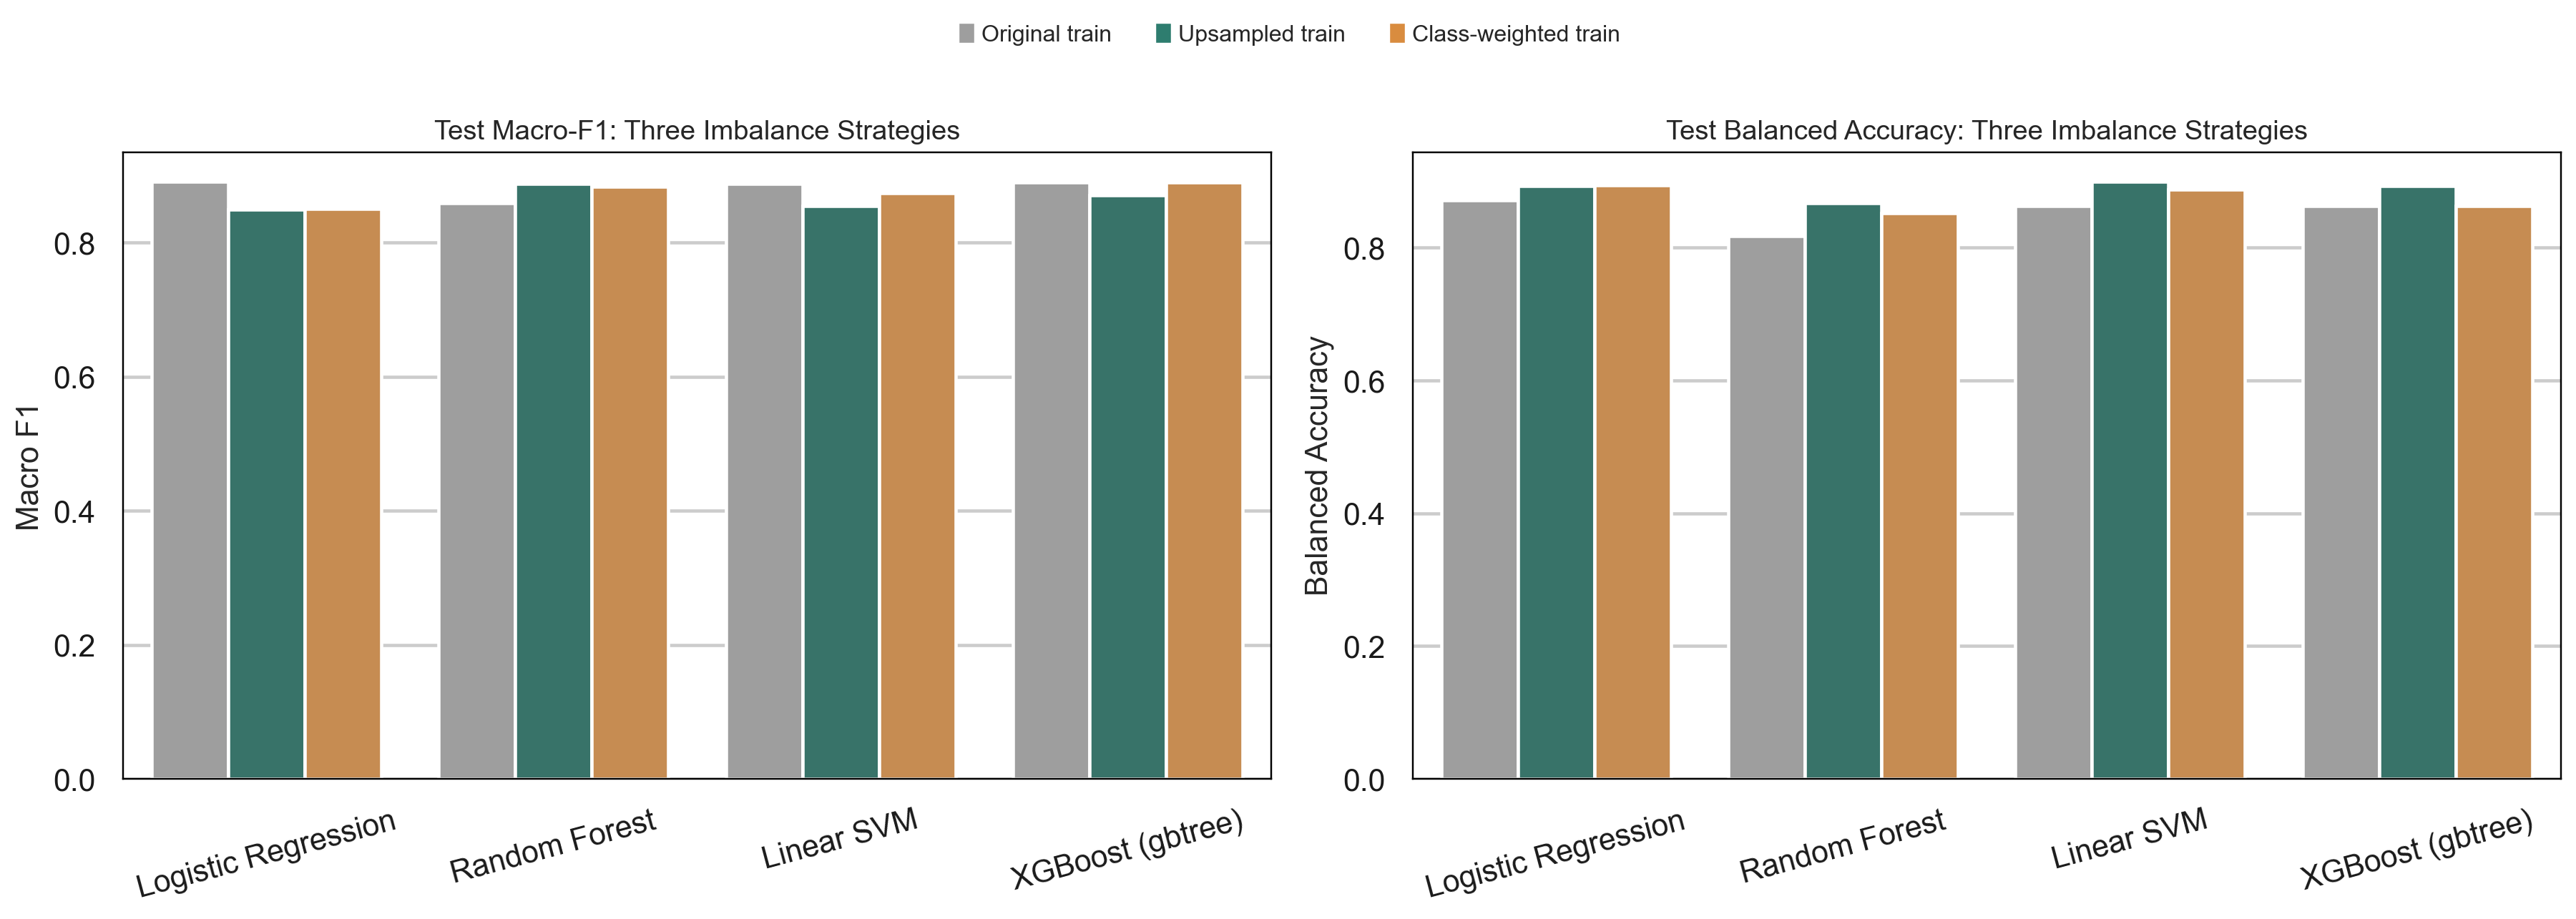

,model,train_strategy,balanced_accuracy,macro_f1
5,Linear SVM,original_train,0.8628,0.8874
21,Linear SVM,class_weighted_train,0.8873,0.8737
13,Linear SVM,upsampled_train,0.8990,0.8545
1,Logistic Regression,original_train,0.8713,0.8903
17,Logistic Regression,class_weighted_train,0.8940,0.8504
9,Logistic Regression,upsampled_train,0.8931,0.8495
11,Random Forest,upsampled_train,0.8673,0.8879
19,Random Forest,class_weighted_train,0.8526,0.8836
3,Random Forest,original_train,0.8178,0.8589
7,XGBoost (gbtree),original_train,0.8627,0.8892


In [21]:
strategy_plot = baseline_strategy_comparison.melt(
    id_vars=["model", "split", "train_strategy"],
    value_vars=["macro_f1", "balanced_accuracy"],
    var_name="metric",
    value_name="score",
)
strategy_plot["train_strategy"] = strategy_plot["train_strategy"].map({
    "original_train": "Original train",
    "upsampled_train": "Upsampled train",
    "class_weighted_train": "Class-weighted train",
})

fig, axes = plt.subplots(1, 2, figsize=(16.6, 5.8))
for ax, metric_name, title in zip(
    axes,
    ["macro_f1", "balanced_accuracy"],
    ["Test Macro-F1: Three Imbalance Strategies", "Test Balanced Accuracy: Three Imbalance Strategies"],
):
    sns.barplot(
        data=strategy_plot[(strategy_plot["split"] == "test") & (strategy_plot["metric"] == metric_name)],
        x="model",
        y="score",
        hue="train_strategy",
        palette={"Original train": "#9E9E9E", "Upsampled train": "#2E7D6F", "Class-weighted train": "#D98C3F"},
        ax=ax,
    )
    ax.set_title(title, fontsize=12.5)
    ax.set_xlabel("")
    ax.set_ylabel(metric_name.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=15)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

handles = [
    plt.Rectangle((0, 0), 1, 1, color="#9E9E9E"),
    plt.Rectangle((0, 0), 1, 1, color="#2E7D6F"),
    plt.Rectangle((0, 0), 1, 1, color="#D98C3F"),
]
labels = ["Original train", "Upsampled train", "Class-weighted train"]
fig.legend(handles, labels, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=10.5)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

strategy_test_summary = baseline_strategy_comparison[baseline_strategy_comparison["split"] == "test"][["model", "train_strategy", "balanced_accuracy", "macro_f1"]].sort_values(["model", "macro_f1"], ascending=[True, False])
display(strategy_test_summary.round(4))

### Control-Experiment Interpretation

- Logistic Regression works best with the original training split.
- Linear SVM also works best with the original training split.
- Random Forest benefits from upsampling.
- XGBoost is strongest with the original training split, and upsampling hurts its macro-F1.

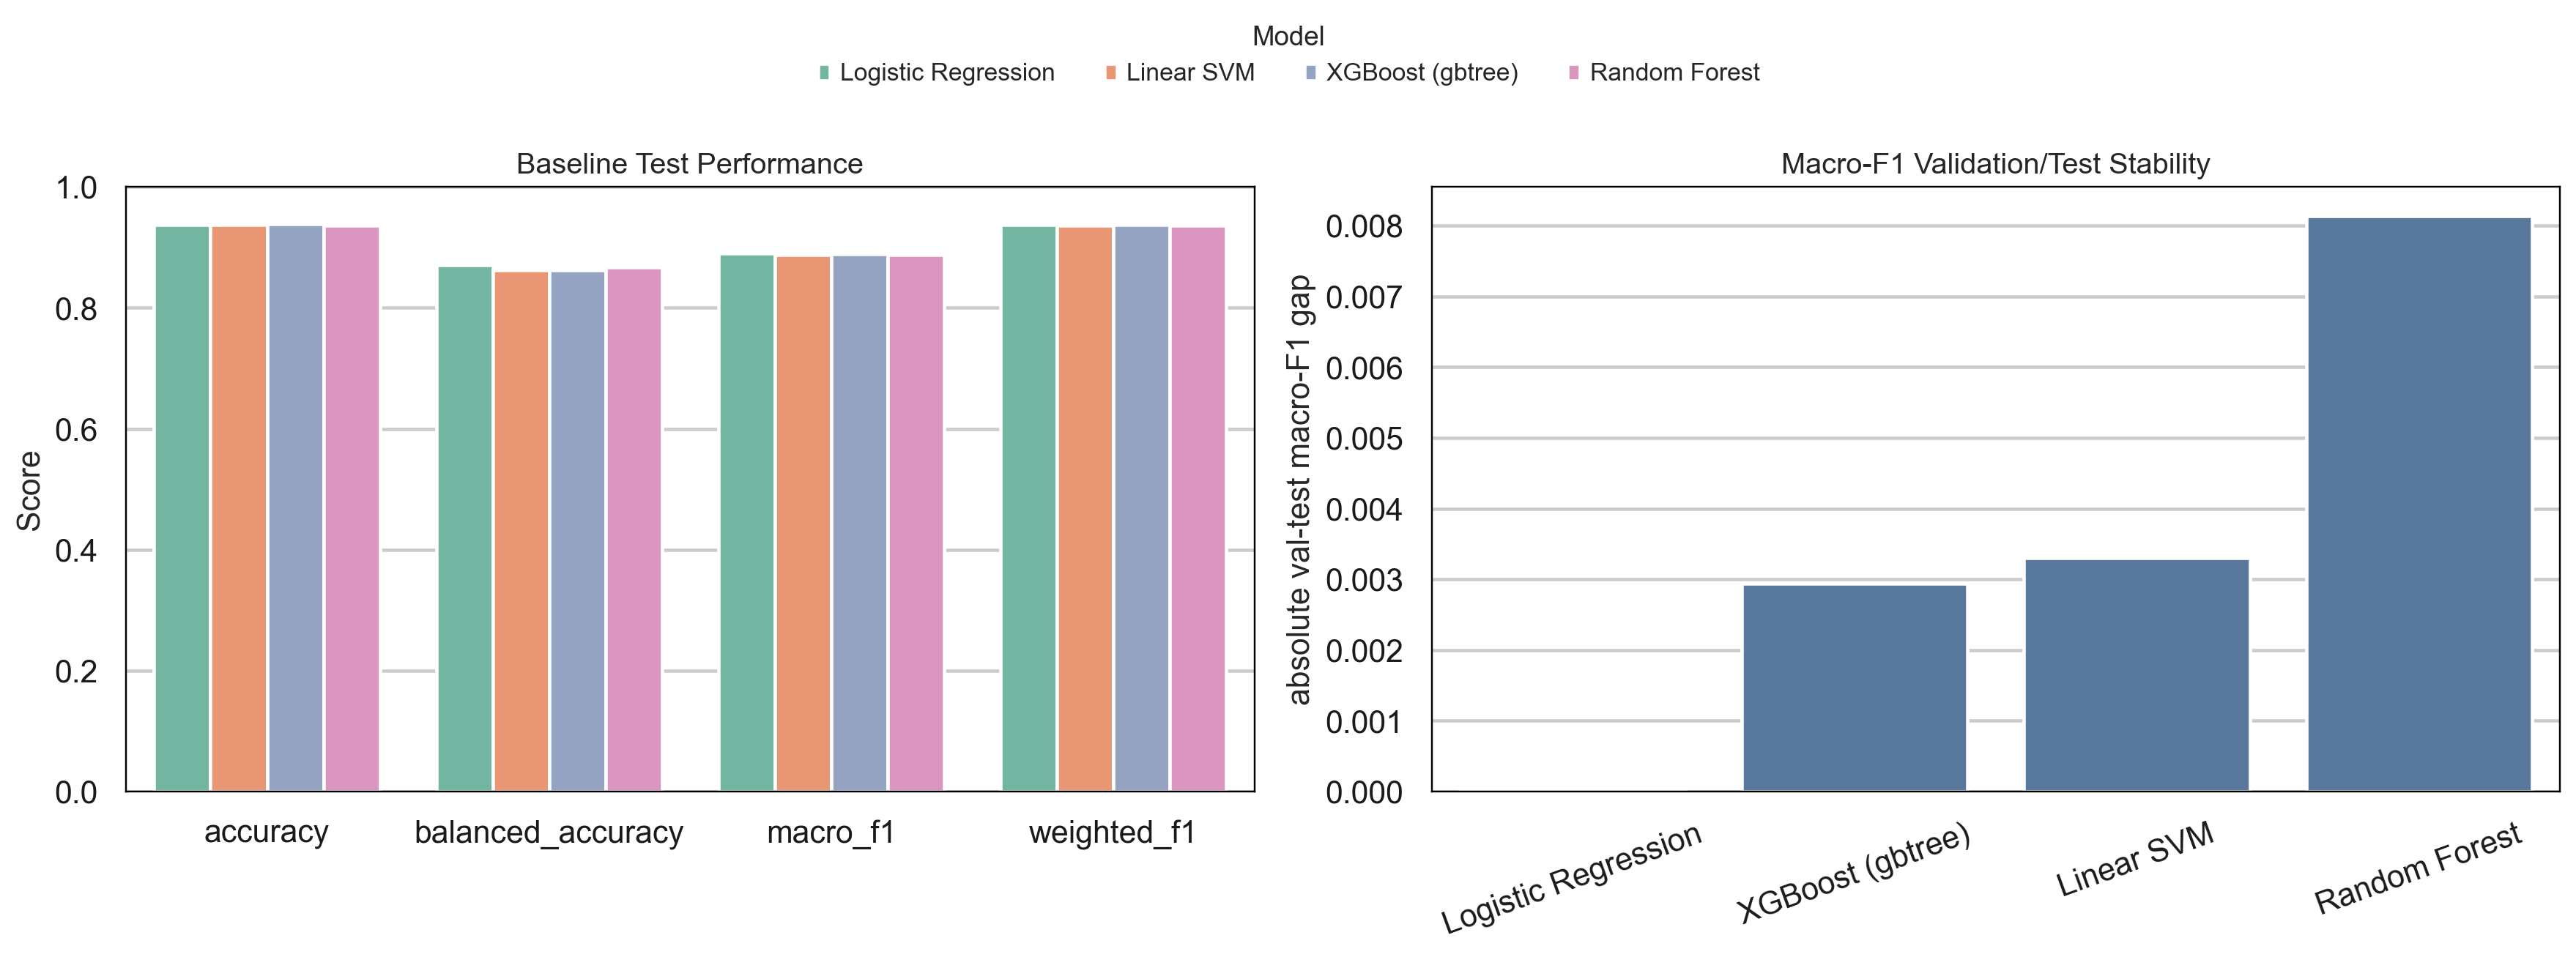

split,test,val,val_test_gap
model,,,
Logistic Regression,0.8903,0.8903,0.0000
XGBoost (gbtree),0.8892,0.8863,0.0029
Linear SVM,0.8874,0.8907,0.0033
Random Forest,0.8879,0.8798,0.0081


In [22]:
metric_order = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]
metric_plot = baseline_metrics.melt(id_vars=["model", "split"], value_vars=metric_order, var_name="metric", value_name="score")

fig, axes = plt.subplots(1, 2, figsize=(16.2, 5.9))

sns.barplot(
    data=metric_plot[metric_plot["split"] == "test"],
    x="metric",
    y="score",
    hue="model",
    order=metric_order,
    ax=axes[0],
    palette="Set2",
)
axes[0].set_title("Baseline Test Performance", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0.0, 1.0)
handles, labels = axes[0].get_legend_handles_labels()
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()

stability_table = baseline_metrics.pivot(index="model", columns="split", values="macro_f1").assign(val_test_gap=lambda df: (df["val"] - df["test"]).abs()).sort_values("val_test_gap")
sns.barplot(data=stability_table.reset_index(), x="model", y="val_test_gap", ax=axes[1], color="#4C78A8")
axes[1].set_title("Macro-F1 Validation/Test Stability", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("absolute val-test macro-F1 gap")
axes[1].tick_params(axis="x", rotation=20)

fig.legend(handles, labels, title="Model", frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=max(3, len(labels)), fontsize=11, title_fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.90])
fig.savefig(FIGURE_ROOT / 'benchmark_performance_fixed.png', dpi=220, bbox_inches='tight')
plt.show()

display(stability_table.round(4))

### Baseline Confusion Matrix

The confusion matrix slide should focus on the test split. Row-normalized matrices are easiest to explain because each row sums to 1, so the plot shows where each true cell type is predicted.

Use the top-confusion table after the plot to name the specific cell-type pairs that are most often mixed up.


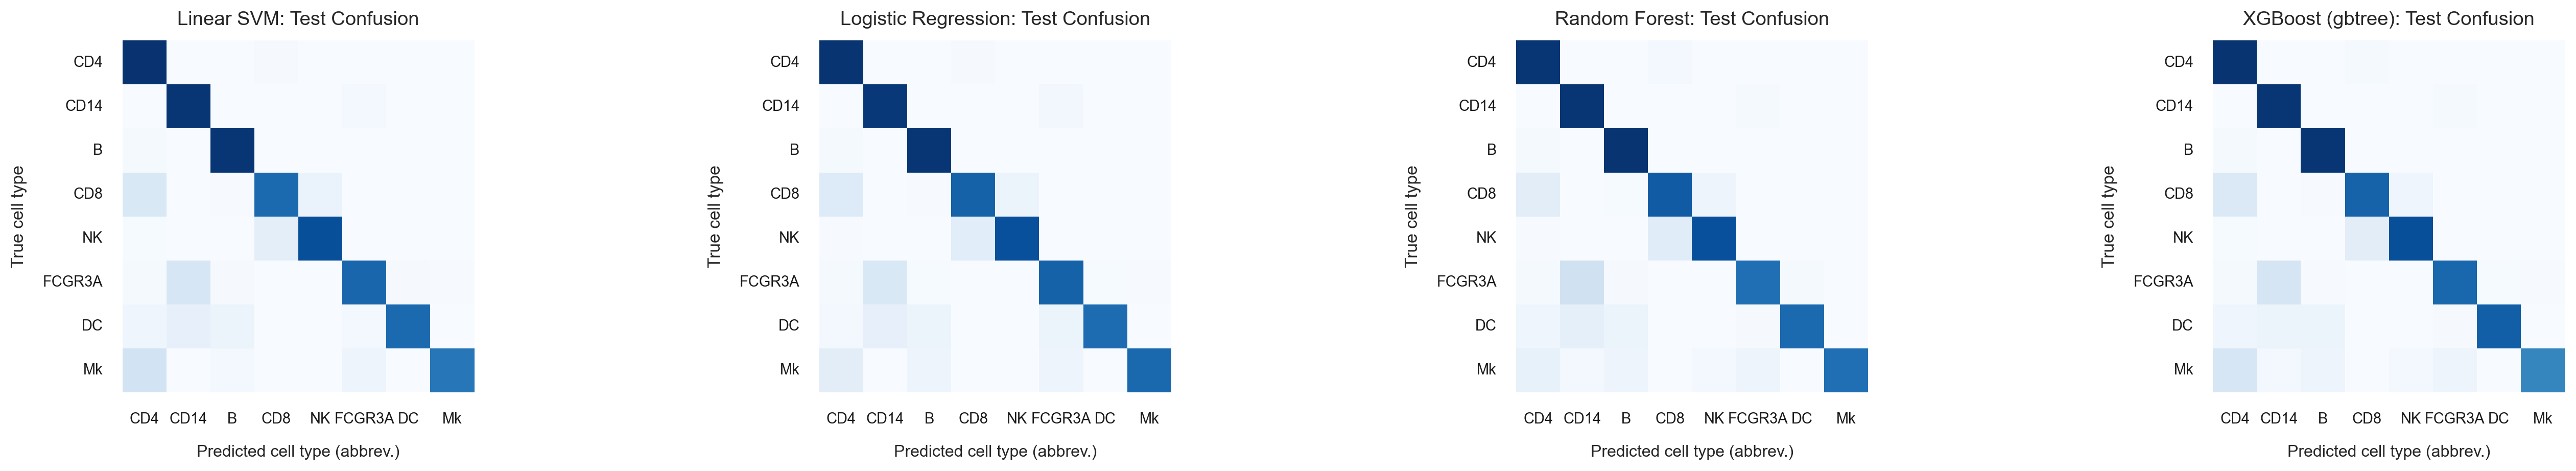

,model,split,true_label,pred_label,count,row_rate
0,Linear SVM,test,CD8 T cells,CD4 T cells,75,0.150
1,Linear SVM,test,NK cells,CD8 T cells,51,0.105
2,Linear SVM,test,FCGR3A+ Monocytes,CD14+ Monocytes,50,0.161
3,Linear SVM,test,CD8 T cells,NK cells,33,0.066
4,Linear SVM,test,CD4 T cells,CD8 T cells,27,0.012
5,Linear SVM,test,CD14+ Monocytes,FCGR3A+ Monocytes,23,0.022
6,Linear SVM,test,B cells,CD4 T cells,9,0.016
7,Linear SVM,test,Megakaryocytes,CD4 T cells,7,0.189
8,Logistic Regression,test,CD8 T cells,CD4 T cells,66,0.132
9,Logistic Regression,test,NK cells,CD8 T cells,54,0.111


In [23]:
def normalize_confusion(cm):
    return cm.div(cm.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)


def top_confusion_pairs(cm, model_name, split_name, top_n=8):
    records = []
    row_totals = cm.sum(axis=1).replace(0, np.nan)
    for true_label in cm.index:
        for pred_label in cm.columns:
            if true_label != pred_label and int(cm.loc[true_label, pred_label]) > 0:
                count = int(cm.loc[true_label, pred_label])
                records.append({
                    "model": model_name,
                    "split": split_name,
                    "true_label": true_label,
                    "pred_label": pred_label,
                    "count": count,
                    "row_rate": float(count / row_totals.loc[true_label]),
                })
    return pd.DataFrame(records).sort_values(["count", "row_rate"], ascending=False).head(top_n)

confusion_label_map = {
    "CD4 T cells": "CD4",
    "CD14+ Monocytes": "CD14",
    "B cells": "B",
    "CD8 T cells": "CD8",
    "NK cells": "NK",
    "FCGR3A+ Monocytes": "FCGR3A",
    "Dendritic cells": "DC",
    "Megakaryocytes": "Mk",
}

baseline_model_names = best_strategy_per_model["model"].tolist()
fig, axes = plt.subplots(1, len(baseline_model_names), figsize=(23.0, 6.6))
if len(baseline_model_names) == 1:
    axes = [axes]

for ax, model_name in zip(axes, baseline_model_names):
    plot_cm = normalize_confusion(baseline_confusions[(model_name, "test")]).rename(index=confusion_label_map, columns=confusion_label_map)
    sns.heatmap(plot_cm, cmap="Blues", vmin=0, vmax=1, cbar=False, square=True, ax=ax)
    ax.set_title(f"{model_name}: Test Confusion", fontsize=12.5, pad=10)
    ax.set_xlabel("Predicted cell type (abbrev.)", fontsize=10.5, labelpad=12)
    ax.set_ylabel("True cell type", fontsize=11, labelpad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9.5)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9.5)

fig.subplots_adjust(left=0.045, right=0.99, top=0.86, bottom=0.21, wspace=0.98)
fig.savefig(FIGURE_ROOT / 'benchmark_confusion_matrices_fixed.png', dpi=220, bbox_inches='tight')
plt.show()

baseline_top_confusions = pd.concat([top_confusion_pairs(baseline_confusions[(model_name, "test")], model_name, "test") for model_name in baseline_model_names], ignore_index=True)
display(baseline_top_confusions.round({"row_rate": 3}))

### Baseline Per-Class Performance

This figure makes the class-level story clearer than the aggregate table alone.

- The left panel compares test F1 for every cell type across the baseline models.
- The right panel shows the largest off-diagonal confusion pairs, so we can name the exact cell types that the baselines mix up.

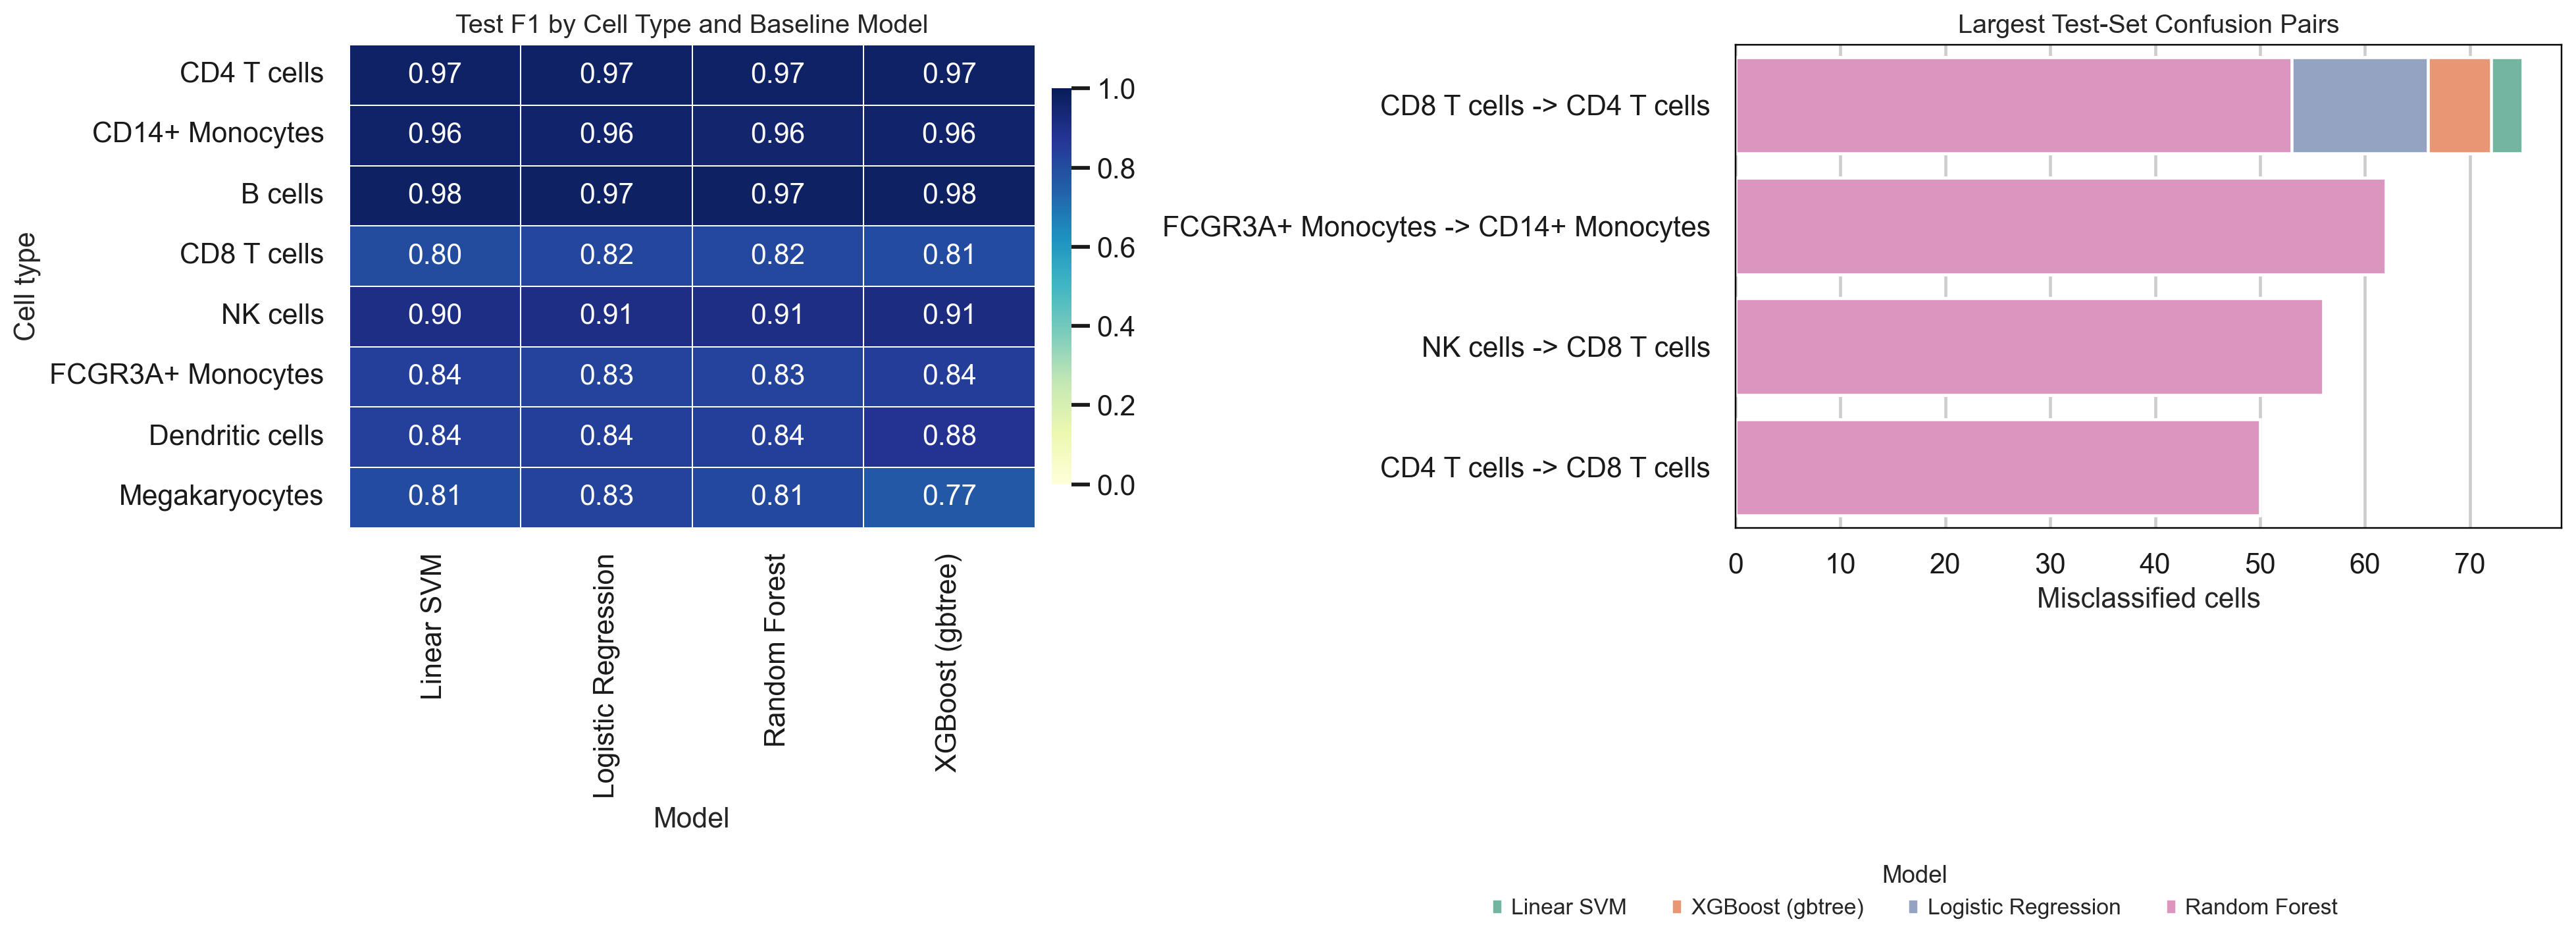

model,Linear SVM,Logistic Regression,Random Forest,XGBoost (gbtree)
cell_type,,,,
CD4 T cells,0.971,0.972,0.970,0.969
CD14+ Monocytes,0.961,0.957,0.955,0.961
B cells,0.976,0.973,0.974,0.977
CD8 T cells,0.805,0.817,0.815,0.808
NK cells,0.903,0.905,0.906,0.910
FCGR3A+ Monocytes,0.842,0.829,0.828,0.844
Dendritic cells,0.837,0.840,0.842,0.876
Megakaryocytes,0.806,0.829,0.812,0.769


In [24]:
per_class_test = baseline_per_class[baseline_per_class["split"] == "test"].copy()
per_class_f1 = per_class_test.pivot(index="cell_type", columns="model", values="f1_score").loc[baseline_data["label_order"]]

top_confusion_plot = baseline_top_confusions.sort_values(["count", "row_rate"], ascending=False).head(12).copy()
top_confusion_plot["confusion_pair"] = top_confusion_plot["true_label"] + " -> " + top_confusion_plot["pred_label"]

fig, axes = plt.subplots(1, 2, figsize=(18.0, 6.6))

sns.heatmap(per_class_f1, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, linewidths=0.5, cbar_kws={"shrink": 0.82, "pad": 0.02}, ax=axes[0])
axes[0].set_title("Test F1 by Cell Type and Baseline Model", fontsize=13)
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Cell type")

sns.barplot(data=top_confusion_plot, y="confusion_pair", x="count", hue="model", dodge=False, ax=axes[1], palette="Set2")
axes[1].set_title("Largest Test-Set Confusion Pairs", fontsize=13)
axes[1].set_xlabel("Misclassified cells")
axes[1].set_ylabel("")
handles, labels = axes[1].get_legend_handles_labels()
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

fig.legend(handles, labels, title="Model", frameon=False, loc="lower center", bbox_to_anchor=(0.74, 0.0), ncol=max(3, len(labels)), fontsize=11, title_fontsize=12)
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(FIGURE_ROOT / 'benchmark_per_class_confusions_fixed.png', dpi=220, bbox_inches='tight')
plt.show()

display(per_class_f1.round(3))

### Baseline Interpretation

- PCA features already give a strong baseline. The best test model is Logistic Regression with accuracy 0.938 and macro-F1 0.890.
- XGBoost is very close, but it still does not beat Logistic Regression on macro-F1.
- The best imbalance setting depends on the model: Logistic Regression, Linear SVM, and XGBoost use the original training split, while Random Forest works best with upsampling.
- The most stable model is Logistic Regression.
- The main confusion pairs are CD8 T cells vs CD4 T cells, FCGR3A+ Monocytes vs CD14+ Monocytes, and NK cells vs CD8 T cells.
- We still keep the autoencoder because a strong PCA baseline does not mean PCA is the best representation for harder cell-type overlap or future shift settings.


## Autoencoder Block

This section adds the autoencoder benchmark to the same notebook. The goal is to compare PCA features with denoising autoencoder representations on a fixed `train / val / test` split.

The section uses the completed autoencoder result files under `results/` so the notebook can reproduce the result tables and figures without retraining neural networks every time. The loaded run summaries record the model setup, split source, and training configuration.


In [25]:
# Autoencoder result paths and model labels
RESULTS_ROOT = ROOT / 'results'
MS3_FIGURE_ROOT = FIGURE_ROOT
MS3_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

MS3_RESULT_PREFIXES = {
    'DAE-32 + LR': 'gse96583_dae_lr_noise010_e10',
    'SupDAE w=1.0': 'gse96583_supdae_head_noise010_e10',
    'SupDAE w=0.5': 'gse96583_supdae_head_w05_noise010_e10',
    'SupDAE w=2.0': 'gse96583_supdae_head_w20_noise010_e10',
}

MS3_DISPLAY_ORDER = [
    'PCA-50',
    'DAE-32 + LR',
    'SupDAE w=1.0',
    'SupDAE w=0.5',
    'SupDAE w=2.0',
]

MS3_REP_LABELS = {
    'PCA-50': 'PCA-50',
    'DAE-32-LR-noise0.10': 'DAE-32 + LR',
    'SupDAE-32-head-noise0.10': 'SupDAE w=1.0',
    'SupDAE-32-head-w0.5-noise0.10': 'SupDAE w=0.5',
    'SupDAE-32-head-w2.0-noise0.10': 'SupDAE w=2.0',
}

BEST_MS3_LABEL = None
BEST_MS3_PREFIX = None

required_ms3_files = []
for prefix in MS3_RESULT_PREFIXES.values():
    required_ms3_files.extend([
        RESULTS_ROOT / f'{prefix}_metrics.csv',
        RESULTS_ROOT / f'{prefix}_per_class.csv',
        RESULTS_ROOT / f'{prefix}_training_history.csv',
        RESULTS_ROOT / f'{prefix}_run_summary.json',
    ])
missing_ms3_files = [str(path) for path in required_ms3_files if not path.exists()]
if missing_ms3_files:
    raise FileNotFoundError('Missing MS3 result files:\n' + '\n'.join(missing_ms3_files))

print('Autoencoder result files found:', len(required_ms3_files))
print('Autoencoder variants:', ', '.join(MS3_RESULT_PREFIXES.keys()))


Autoencoder result files found: 16
Autoencoder variants: DAE-32 + LR, SupDAE w=1.0, SupDAE w=0.5, SupDAE w=2.0


In [26]:
# Validate that autoencoder results use the same fixed split as the current notebook
current_split_manifest = split_adata.obs[['split', 'cell_type', 'batch_label', 'condition']].copy()
current_split_manifest.index = current_split_manifest.index.astype(str)

split_checks = []
for display_label, prefix in MS3_RESULT_PREFIXES.items():
    manifest_path = RESULTS_ROOT / f'{prefix}_split_manifest.csv'
    manifest = pd.read_csv(manifest_path, index_col=0)
    manifest.index = manifest.index.astype(str)
    manifest = manifest[['split', 'cell_type', 'batch_label', 'condition']]
    same_index = current_split_manifest.index.equals(manifest.index)
    same_split = current_split_manifest['split'].astype(str).equals(manifest['split'].astype(str))
    same_metadata = current_split_manifest[['cell_type', 'batch_label', 'condition']].astype(str).equals(
        manifest[['cell_type', 'batch_label', 'condition']].astype(str)
    )
    split_checks.append({
        'run': display_label,
        'manifest_rows': len(manifest),
        'current_rows': len(current_split_manifest),
        'same_cell_order': same_index,
        'same_split_assignment': same_split,
        'same_metadata': same_metadata,
    })

ms3_split_check = pd.DataFrame(split_checks)
display(ms3_split_check)
if not ms3_split_check[['same_cell_order', 'same_split_assignment', 'same_metadata']].all().all():
    raise ValueError('At least one MS3 result file does not match the current MS2 split_adata split.')


,run,manifest_rows,current_rows,same_cell_order,same_split_assignment,same_metadata
0,DAE-32 + LR,35214,35214,True,True,True
1,SupDAE w=1.0,35214,35214,True,True,True
2,SupDAE w=0.5,35214,35214,True,True,True
3,SupDAE w=2.0,35214,35214,True,True,True


### Autoencoder Model Setup

The autoencoder benchmark compares three representation choices:

| Representation | Classifier | Purpose |
| --- | --- | --- |
| `PCA-50` | Logistic Regression | Strong linear baseline from PCA features. |
| `DAE-32` | Logistic Regression | Tests whether an unsupervised denoising autoencoder learns a better latent representation. |
| `SupDAE-32` | Supervised head | Tests whether adding label guidance to the latent space improves classification. |

The supervised model uses the combined loss `reconstruction loss + lambda * classification loss`. The tested supervised weights are `0.5`, `1.0`, and `2.0`.


In [27]:
# Load autoencoder run summaries and build a compact setup table
import json

ms3_run_summaries = {}
for display_label, prefix in MS3_RESULT_PREFIXES.items():
    with open(RESULTS_ROOT / f'{prefix}_run_summary.json', 'r') as handle:
        ms3_run_summaries[display_label] = json.load(handle)

ms3_setup_rows = []
for display_label, summary in ms3_run_summaries.items():
    config = summary['config']
    ms3_setup_rows.append({
        'run': display_label,
        'dataset_source': summary.get('dataset_source', 'unknown'),
        'input_dim': config['input_dim'],
        'latent_dim': config['latent_dim'],
        'noise_level': config['noise_level'],
        'classifier': config['classifier'],
        'supervised_loss_weight': config['supervised_loss_weight'],
        'epochs': config['epochs'],
        'best_val_loss': summary.get('best_val_loss', np.nan),
    })

ms3_setup_table = pd.DataFrame(ms3_setup_rows)
display(ms3_setup_table.round({'best_val_loss': 4}))


,run,dataset_source,input_dim,latent_dim,noise_level,classifier,supervised_loss_weight,epochs,best_val_loss
0,DAE-32 + LR,full_ms2_processed,14222,32,0.1,logistic_regression,1.0,10,0.1305
1,SupDAE w=1.0,full_ms2_processed,14222,32,0.1,supervised_head,1.0,10,0.3173
2,SupDAE w=0.5,full_ms2_processed,14222,32,0.1,supervised_head,0.5,10,0.2267
3,SupDAE w=2.0,full_ms2_processed,14222,32,0.1,supervised_head,2.0,10,0.5019


### Autoencoder Result Table

This table summarizes the autoencoder benchmark on the fixed same-split. We first compare each autoencoder run to the PCA-50 result saved with the same MS3 result files. After that, we also compare the best autoencoder to the current best baseline in this notebook.

In [28]:
# Load test metrics for all autoencoder variants and compare against PCA-50
metric_parts = []
for prefix in MS3_RESULT_PREFIXES.values():
    df = pd.read_csv(RESULTS_ROOT / f'{prefix}_metrics.csv')
    metric_parts.append(df[df['split'] == 'test'].copy())

ms3_metrics = pd.concat(metric_parts, ignore_index=True)
ms3_metrics['representation_label'] = ms3_metrics['representation'].map(MS3_REP_LABELS).fillna(ms3_metrics['representation'])
ms3_metrics = ms3_metrics.drop_duplicates(subset=['representation_label'], keep='last')
ms3_metrics['display_order'] = ms3_metrics['representation_label'].map({label: i for i, label in enumerate(MS3_DISPLAY_ORDER)})
ms3_metrics = ms3_metrics.sort_values('display_order').reset_index(drop=True)

pca_row = ms3_metrics.loc[ms3_metrics['representation_label'] == 'PCA-50'].iloc[0]
for metric in ['accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1']:
    ms3_metrics[f'delta_{metric}_vs_pca'] = ms3_metrics[metric] - pca_row[metric]


# Pick the best supervised autoencoder from the current same-split results.
best_supervised = (
    ms3_metrics[ms3_metrics['representation_label'].str.startswith('SupDAE')]
    .sort_values(['macro_f1', 'accuracy'], ascending=False)
    .iloc[0]
)
BEST_MS3_LABEL = best_supervised['representation_label']
BEST_MS3_PREFIX = MS3_RESULT_PREFIXES[BEST_MS3_LABEL]
print(f'Best same-split supervised DAE: {BEST_MS3_LABEL} ({BEST_MS3_PREFIX})')

ms3_result_table = ms3_metrics[[
    'representation_label', 'classifier', 'n_cells',
    'accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1',
    'delta_accuracy_vs_pca', 'delta_balanced_accuracy_vs_pca', 'delta_macro_f1_vs_pca'
]].rename(columns={'representation_label': 'representation'})

display(ms3_result_table.round(3))
ms3_result_table.to_csv(ROOT / 'deliverables' / 'ms2_ab' / 'ms3_autoencoder_result_table.csv', index=False)


Best same-split supervised DAE: SupDAE w=2.0 (gse96583_supdae_head_w20_noise010_e10)


,representation,classifier,n_cells,accuracy,balanced_accuracy,macro_f1,weighted_f1,delta_accuracy_vs_pca,delta_balanced_accuracy_vs_pca,delta_macro_f1_vs_pca
0,PCA-50,Logistic Regression,5283,0.922,0.894,0.850,0.924,0.000,0.000,0.000
1,DAE-32 + LR,Logistic Regression,5283,0.864,0.797,0.752,0.884,-0.058,-0.097,-0.099
2,SupDAE w=1.0,Supervised Head,5283,0.933,0.834,0.866,0.933,0.011,-0.060,0.016
3,SupDAE w=0.5,Supervised Head,5283,0.932,0.834,0.866,0.932,0.010,-0.060,0.016
4,SupDAE w=2.0,Supervised Head,5283,0.933,0.835,0.867,0.933,0.011,-0.059,0.017


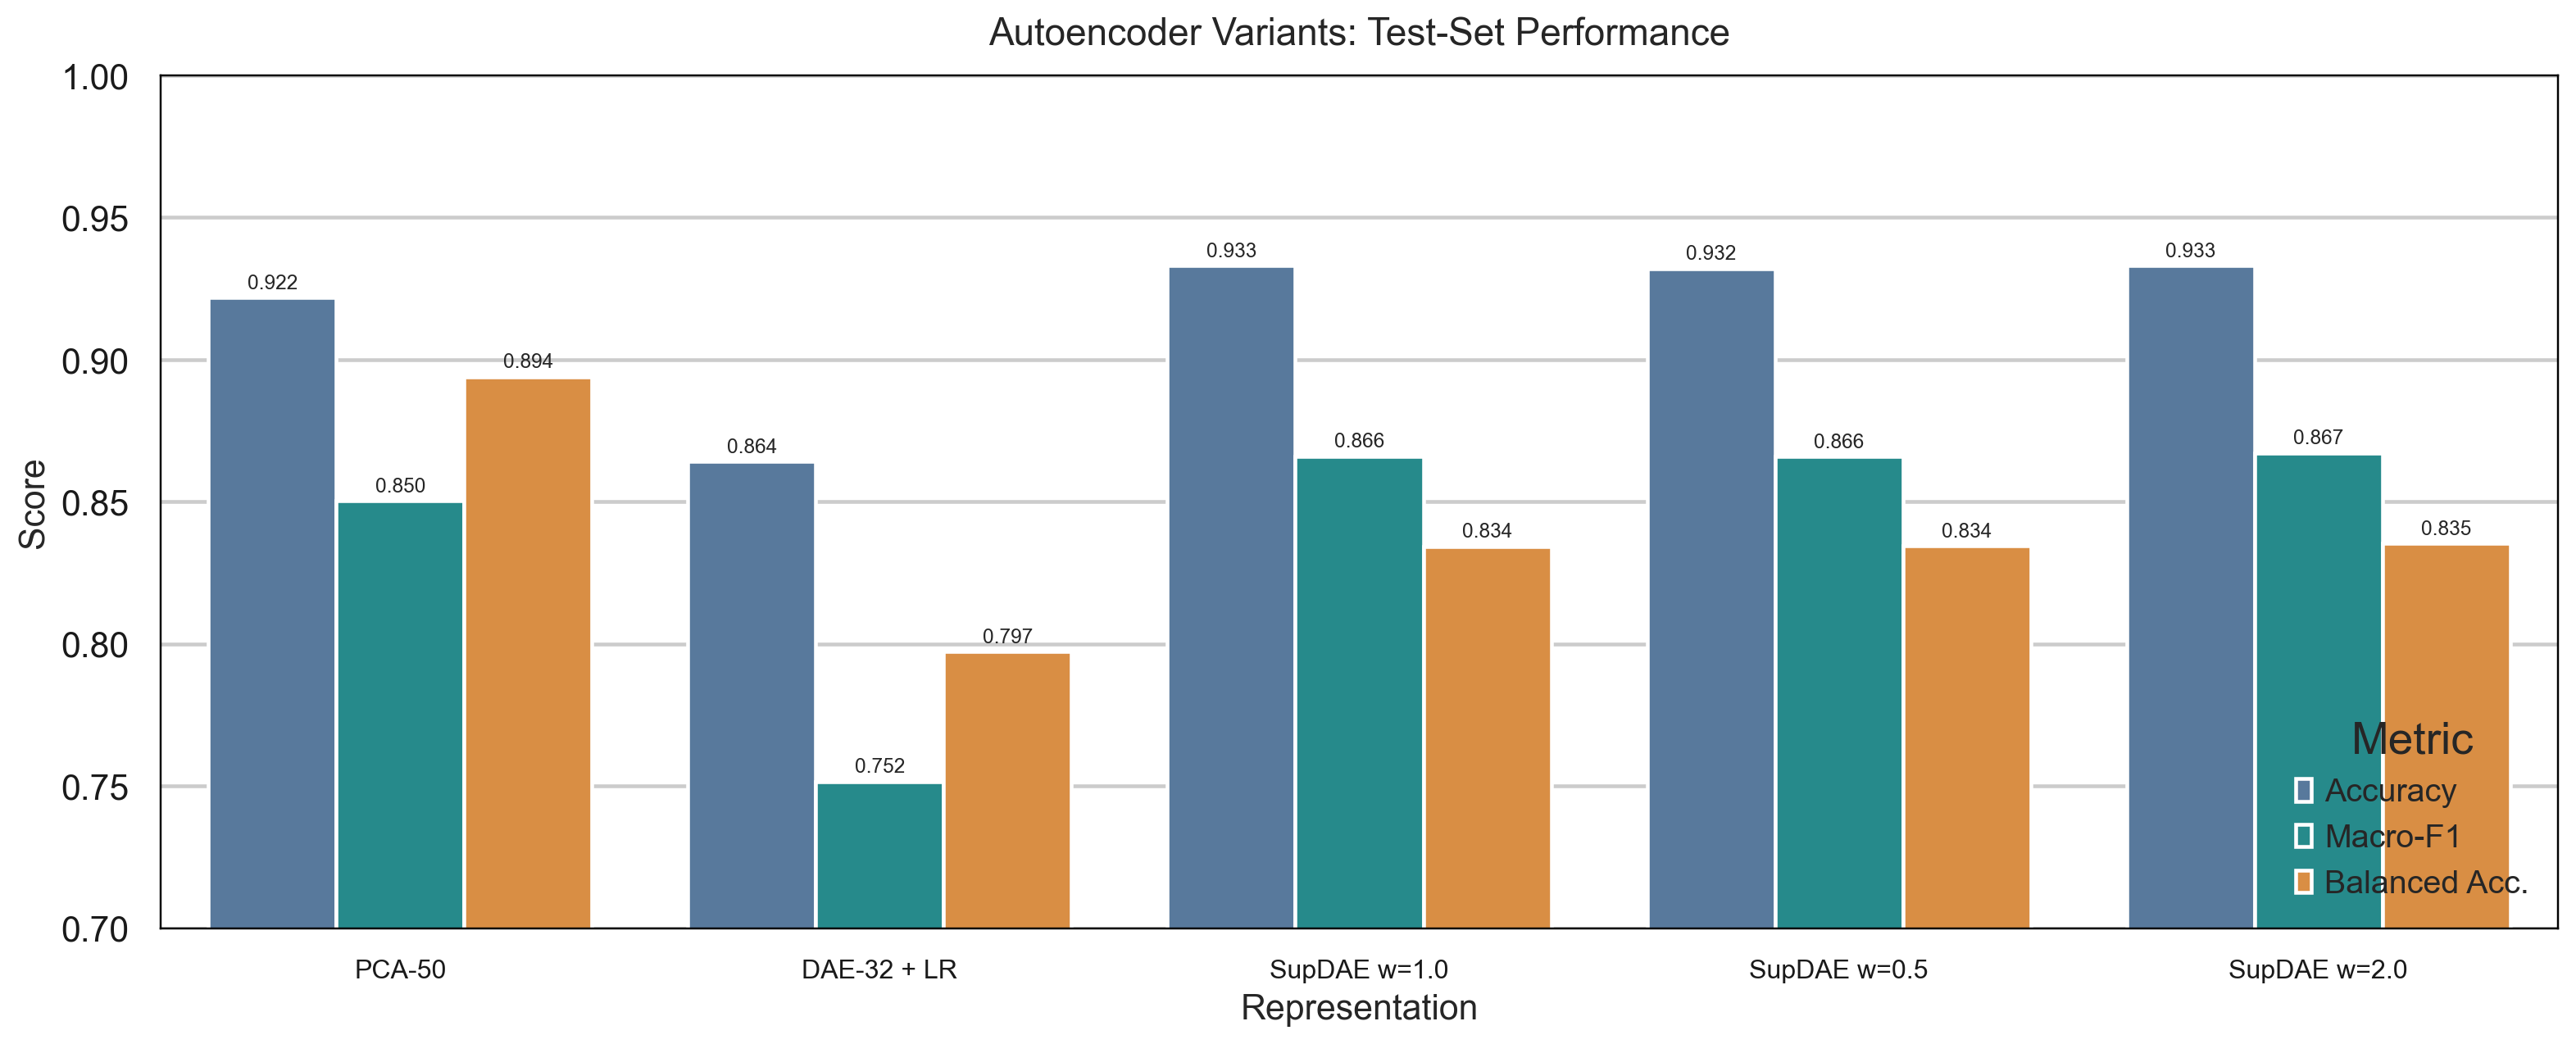

In [29]:
# Visualize autoencoder test-set performance across variants
metric_plot = ms3_metrics.melt(
    id_vars=['representation_label'],
    value_vars=['accuracy', 'macro_f1', 'balanced_accuracy'],
    var_name='metric',
    value_name='score',
)
metric_plot['metric'] = metric_plot['metric'].map({
    'accuracy': 'Accuracy',
    'macro_f1': 'Macro-F1',
    'balanced_accuracy': 'Balanced Acc.',
})

fig, ax = plt.subplots(figsize=(14.5, 6.0))
sns.barplot(
    data=metric_plot,
    x='representation_label',
    y='score',
    hue='metric',
    order=MS3_DISPLAY_ORDER,
    palette=['#4C78A8', '#159A9C', '#F28E2B'],
    ax=ax,
)
ax.set_title('Autoencoder Variants: Test-Set Performance', fontsize=15, pad=12)
ax.set_xlabel('Representation')
ax.set_ylabel('Score')
ax.set_ylim(0.70, 1.00)
ax.tick_params(axis='x', rotation=0, labelsize=10.5)
ax.legend(title='Metric', frameon=False, loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
fig.tight_layout()
fig.savefig(MS3_FIGURE_ROOT / 'ms3_variant_performance.png', dpi=220, bbox_inches='tight')
plt.show()


### Best Autoencoder Run vs PCA

The best supervised autoencoder run is selected from the saved same-split autoencoder results using test macro-F1, with accuracy as the tie-breaker. This gives one best supervised DAE for a clean comparison table.

,metric,PCA-50,SupDAE w=2.0,delta
0,Accuracy,0.922,0.933,0.011
1,Macro-F1,0.850,0.867,0.017
2,Balanced Accuracy,0.894,0.835,-0.059
3,Weighted-F1,0.924,0.933,0.009


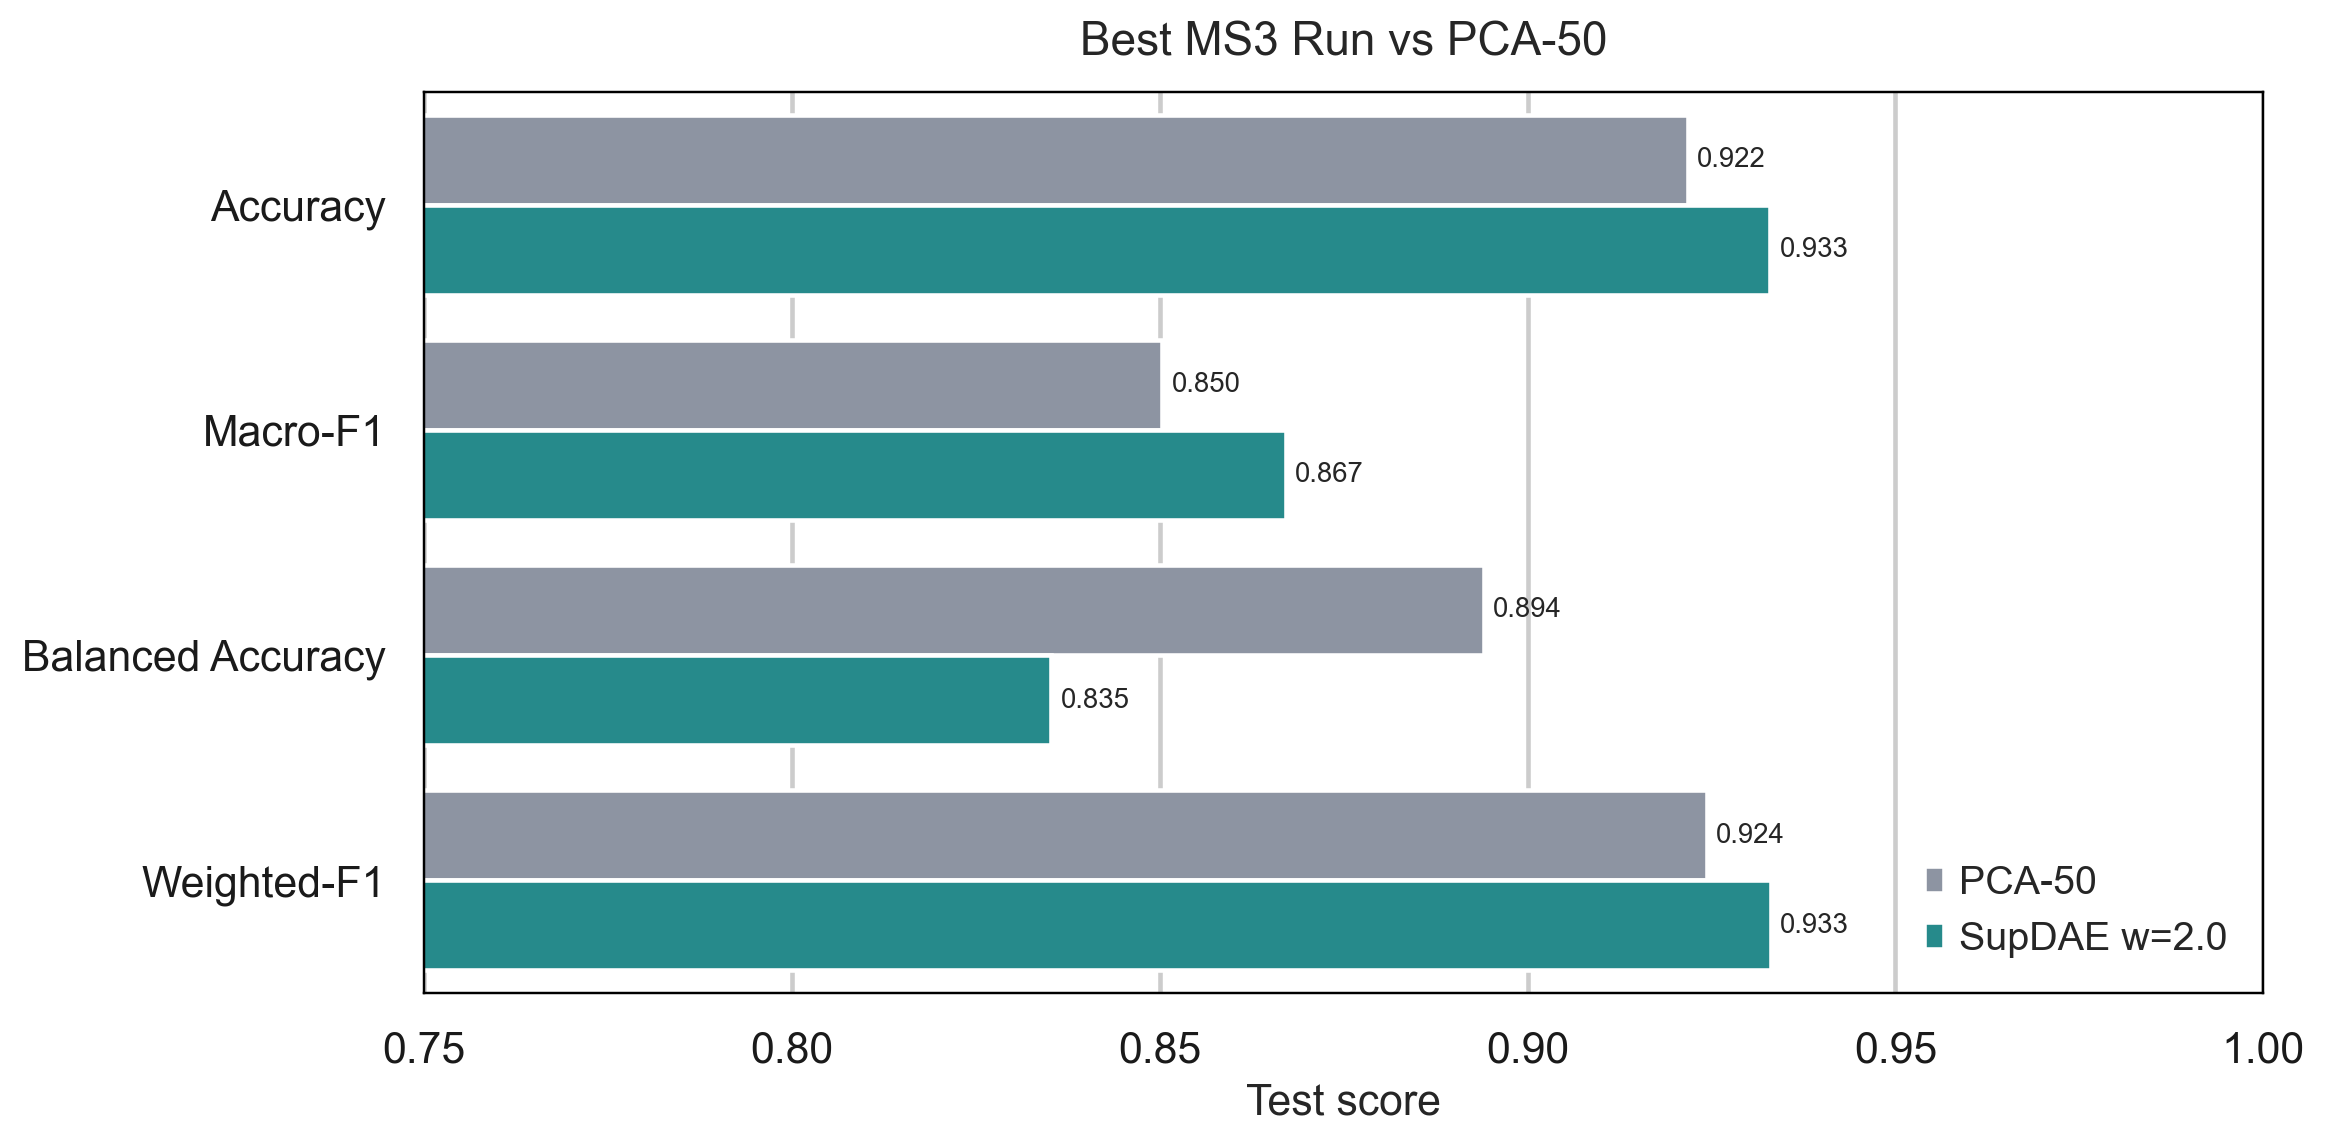

In [30]:
# Best run comparison table and figure
best_compare = ms3_metrics[ms3_metrics['representation_label'].isin(['PCA-50', BEST_MS3_LABEL])].copy()
best_compare = best_compare.set_index('representation_label').loc[['PCA-50', BEST_MS3_LABEL]]

best_vs_pca_table = pd.DataFrame([
    {
        'metric': 'Accuracy',
        'PCA-50': best_compare.loc['PCA-50', 'accuracy'],
        BEST_MS3_LABEL: best_compare.loc[BEST_MS3_LABEL, 'accuracy'],
    },
    {
        'metric': 'Macro-F1',
        'PCA-50': best_compare.loc['PCA-50', 'macro_f1'],
        BEST_MS3_LABEL: best_compare.loc[BEST_MS3_LABEL, 'macro_f1'],
    },
    {
        'metric': 'Balanced Accuracy',
        'PCA-50': best_compare.loc['PCA-50', 'balanced_accuracy'],
        BEST_MS3_LABEL: best_compare.loc[BEST_MS3_LABEL, 'balanced_accuracy'],
    },
    {
        'metric': 'Weighted-F1',
        'PCA-50': best_compare.loc['PCA-50', 'weighted_f1'],
        BEST_MS3_LABEL: best_compare.loc[BEST_MS3_LABEL, 'weighted_f1'],
    },
])
best_vs_pca_table['delta'] = best_vs_pca_table[BEST_MS3_LABEL] - best_vs_pca_table['PCA-50']
display(best_vs_pca_table.round(3))

fig, ax = plt.subplots(figsize=(10.8, 5.4))
plot_df = best_vs_pca_table.melt(id_vars='metric', value_vars=['PCA-50', BEST_MS3_LABEL], var_name='model', value_name='score')
sns.barplot(data=plot_df, y='metric', x='score', hue='model', palette=['#8A93A5', '#159A9C'], ax=ax)
ax.set_title('Best MS3 Run vs PCA-50', fontsize=15, pad=12)
ax.set_xlabel('Test score')
ax.set_ylabel('')
ax.set_xlim(0.75, 1.0)
ax.legend(title='', frameon=False, loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=3)
fig.tight_layout()
fig.savefig(MS3_FIGURE_ROOT / 'ms3_best_vs_pca_metrics.png', dpi=220, bbox_inches='tight')
plt.show()


### Class-Level Effect

The class-level view shows where the supervised autoencoder changes performance relative to PCA. This is important because macro-F1 is sensitive to rare or difficult cell types.


representation_label,PCA-50,SupDAE w=2.0,delta
cell_type,,,
CD8 T cells,0.801,0.795,-0.006
CD4 T cells,0.960,0.961,0.001
Megakaryocytes,0.640,0.643,0.003
NK cells,0.908,0.919,0.011
CD14+ Monocytes,0.949,0.960,0.012
B cells,0.960,0.976,0.016
FCGR3A+ Monocytes,0.821,0.869,0.048
Dendritic cells,0.765,0.814,0.049


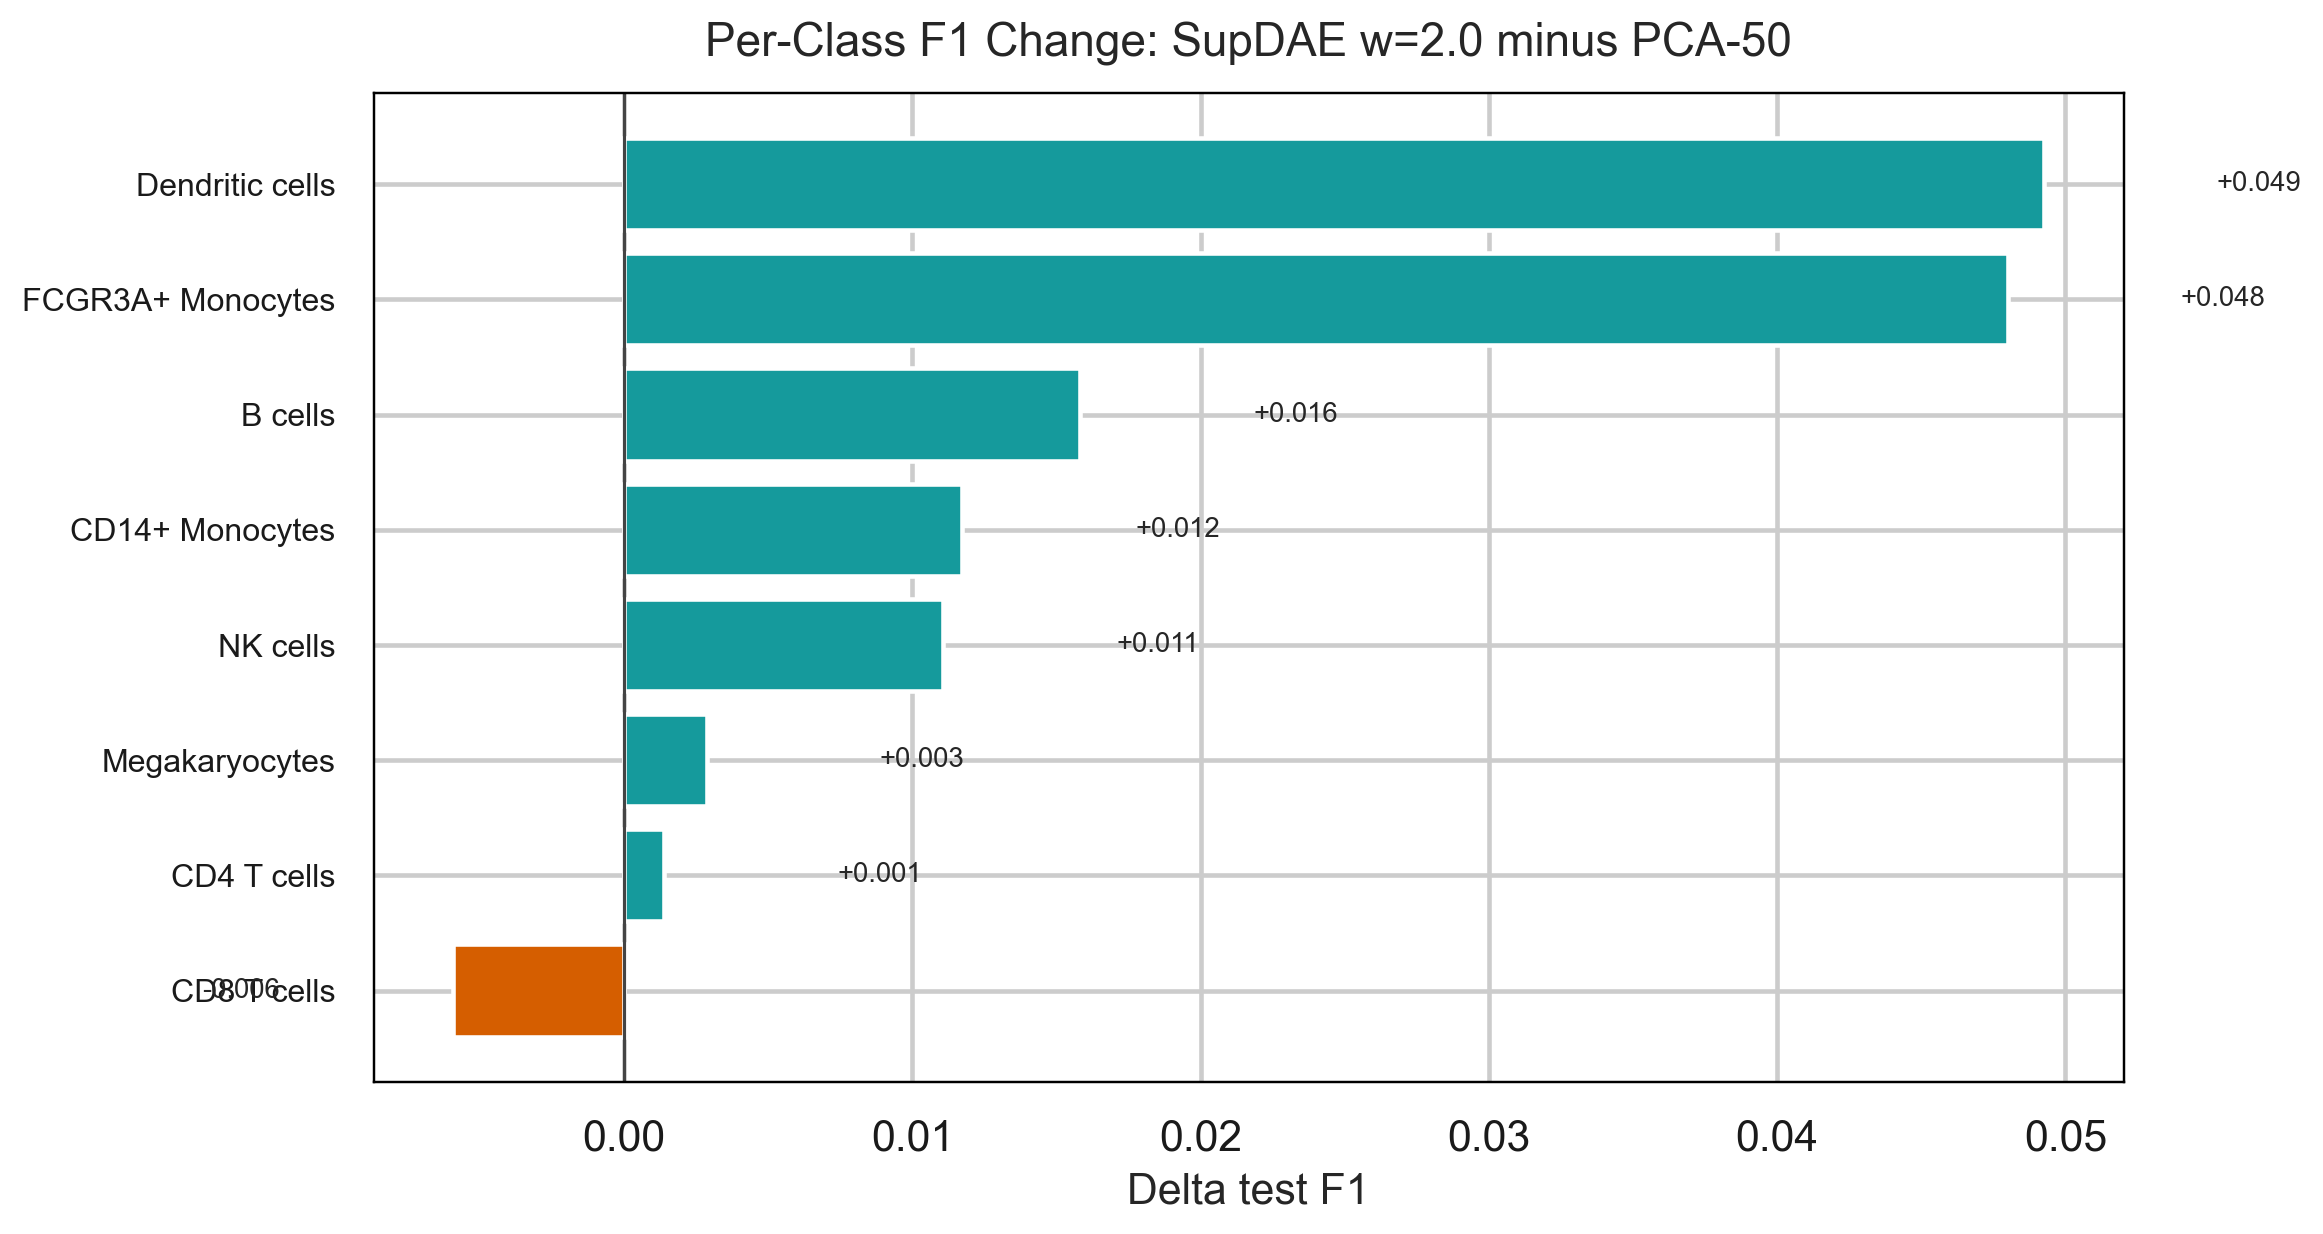

In [31]:
# Per-class F1 delta for the best supervised autoencoder vs PCA
best_per_class = pd.read_csv(RESULTS_ROOT / f'{BEST_MS3_PREFIX}_per_class.csv')
best_per_class = best_per_class[best_per_class['split'] == 'test'].copy()
best_per_class['representation_label'] = best_per_class['representation'].map(MS3_REP_LABELS).fillna(best_per_class['representation'])

per_class_compare = (
    best_per_class
    .pivot(index='cell_type', columns='representation_label', values='f1_score')
    .loc[:, ['PCA-50', BEST_MS3_LABEL]]
    .assign(delta=lambda df: df[BEST_MS3_LABEL] - df['PCA-50'])
    .sort_values('delta', ascending=True)
)

display(per_class_compare.round(3))
per_class_compare.reset_index().to_csv(ROOT / 'deliverables' / 'ms2_ab' / 'ms3_best_per_class_delta.csv', index=False)

fig, ax = plt.subplots(figsize=(10.8, 5.8))
colors = np.where(per_class_compare['delta'] >= 0, '#159A9C', '#D55E00')
ax.barh(per_class_compare.index, per_class_compare['delta'], color=colors)
ax.axvline(0, color='#444444', linewidth=1)
ax.set_title(f'Per-Class F1 Change: {BEST_MS3_LABEL} minus PCA-50', fontsize=15, pad=12)
ax.set_xlabel('Delta test F1')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10.5)
for y, value in enumerate(per_class_compare['delta']):
    ha = 'left' if value >= 0 else 'right'
    offset = 0.006 if value >= 0 else -0.006
    ax.text(value + offset, y, f'{value:+.3f}', va='center', ha=ha, fontsize=9)
fig.tight_layout()
fig.savefig(MS3_FIGURE_ROOT / 'ms3_best_per_class_delta.png', dpi=220, bbox_inches='tight')
plt.show()


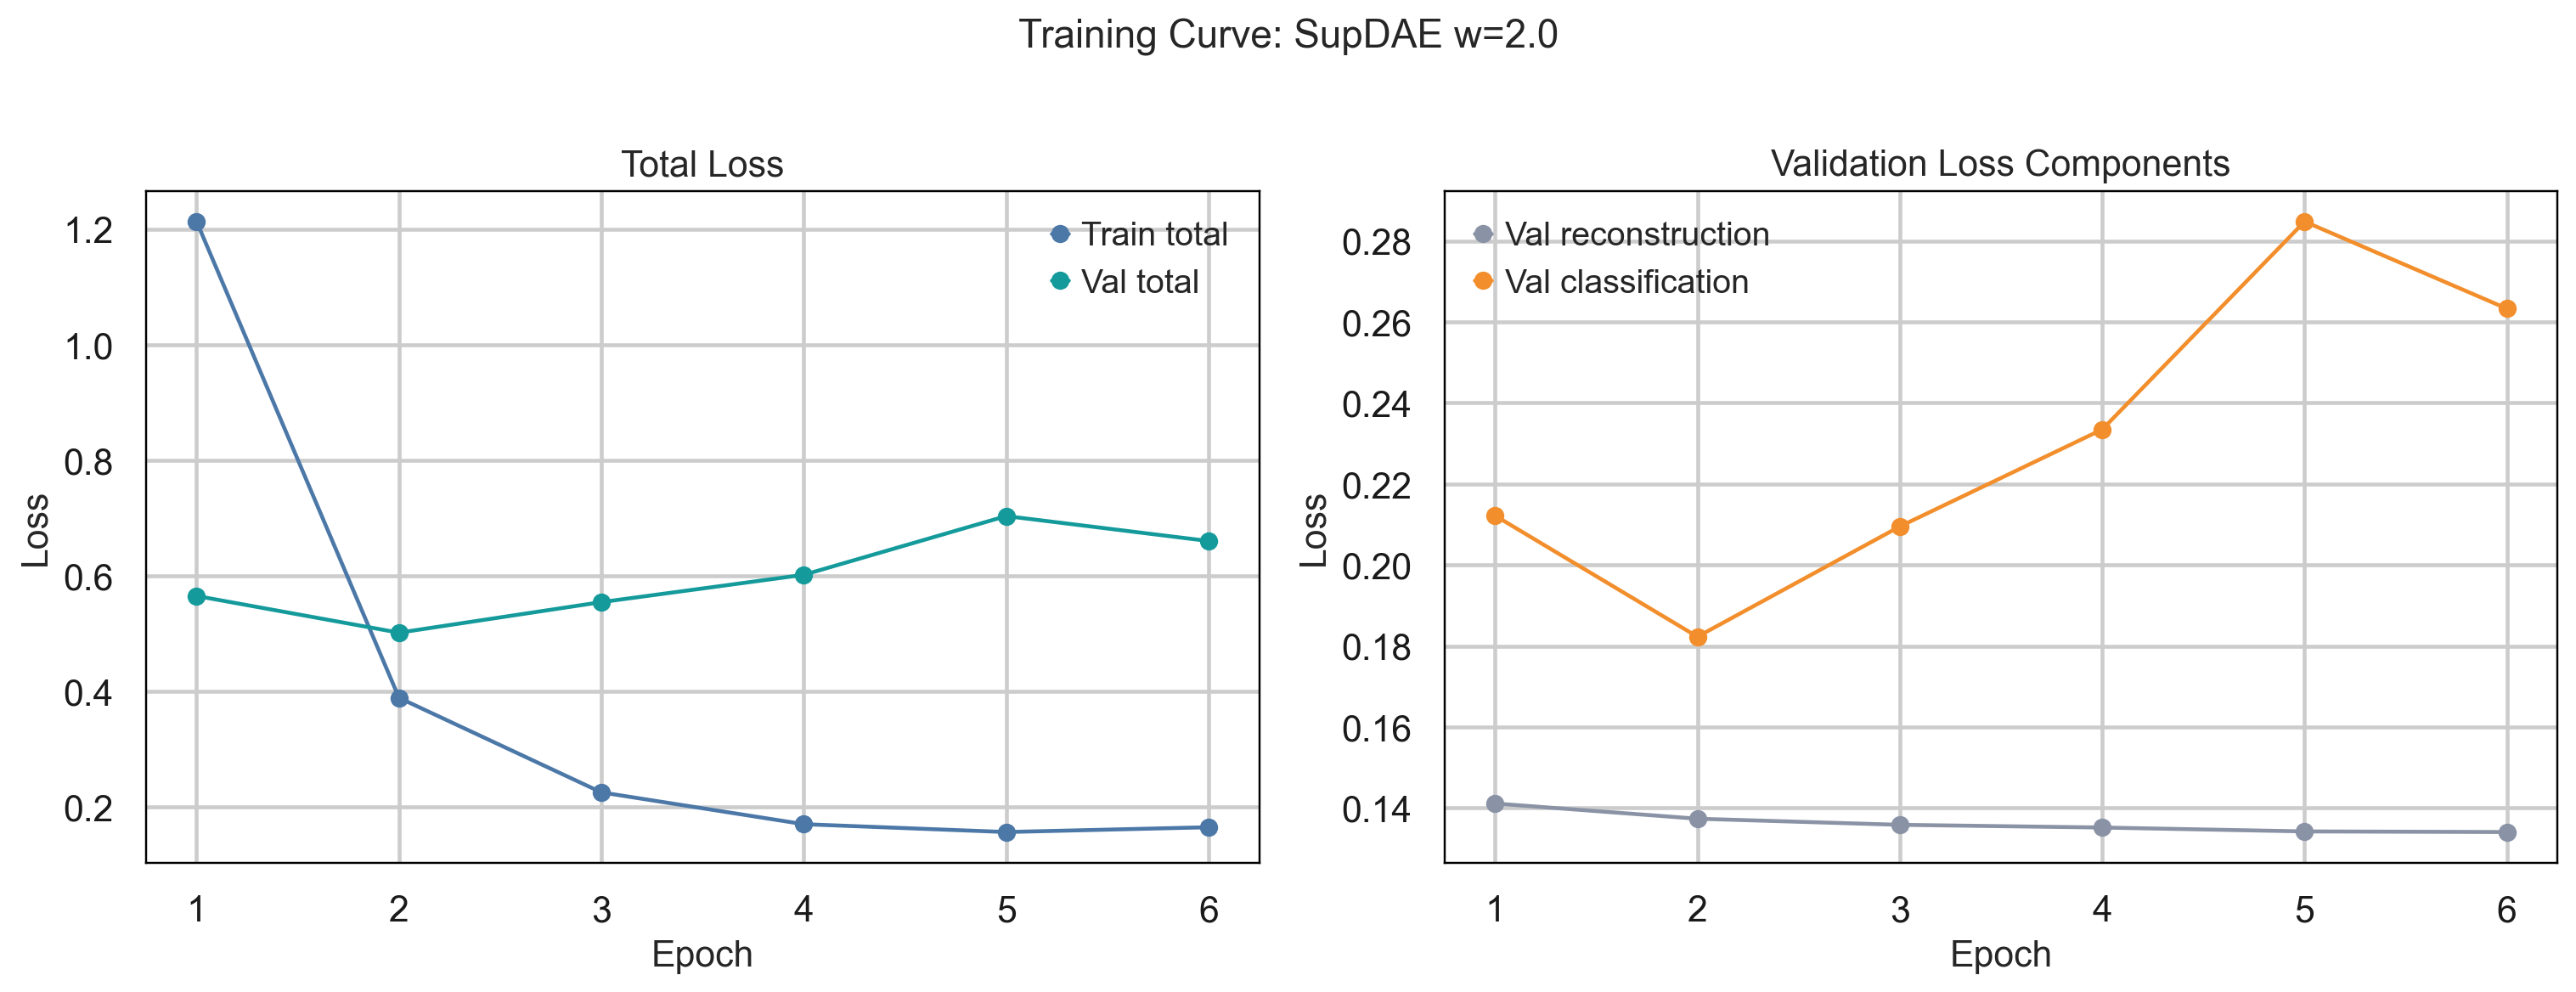

In [32]:
# Training curve for the best supervised autoencoder run
history = pd.read_csv(RESULTS_ROOT / f'{BEST_MS3_PREFIX}_training_history.csv')

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.2))
axes[0].plot(history['epoch'], history['train_loss'], marker='o', label='Train total', color='#4C78A8')
axes[0].plot(history['epoch'], history['val_loss'], marker='o', label='Val total', color='#159A9C')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(frameon=False)

axes[1].plot(history['epoch'], history['val_recon_loss'], marker='o', label='Val reconstruction', color='#8A93A5')
axes[1].plot(history['epoch'], history['val_class_loss'], marker='o', label='Val classification', color='#F28E2B')
axes[1].set_title('Validation Loss Components')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(frameon=False)

fig.suptitle(f'Training Curve: {BEST_MS3_LABEL}', fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(MS3_FIGURE_ROOT / 'ms3_best_training_curve.png', dpi=220, bbox_inches='tight')
plt.show()


### Autoencoder Result Interpretation

This section gives short answers in simple English. It also separates two comparisons:

- comparison to the saved PCA-50 result inside the MS3 autoencoder files
- comparison to the current best baseline in this notebook

### Autoencoder Interpretation

- The unsupervised DAE does not beat PCA.
- The best supervised autoencoder is SupDAE w=2.0.
- Compared with the saved PCA-50 result in the MS3 files, SupDAE w=2.0 is better on accuracy and macro-F1, but worse on balanced accuracy.
- Compared with the current best baseline in this notebook, the supervised autoencoder is still worse.
- The largest F1 gains are for Dendritic cells and FCGR3A+ Monocytes.

In [33]:
# Generate simple autoencoder interpretation from the saved result tables and the current baseline
best_row = ms3_metrics.loc[ms3_metrics['representation_label'] == BEST_MS3_LABEL].iloc[0]
dae_row = ms3_metrics.loc[ms3_metrics['representation_label'] == 'DAE-32 + LR'].iloc[0]
pca_saved_row = ms3_metrics.loc[ms3_metrics['representation_label'] == 'PCA-50'].iloc[0]
current_best_baseline = baseline_metrics[baseline_metrics['split'] == 'test'].sort_values(['macro_f1', 'accuracy'], ascending=False).iloc[0]

largest_gains = per_class_compare.sort_values('delta', ascending=False).head(3)
most_negative = per_class_compare.sort_values('delta', ascending=True).head(1)

gain_text = '; '.join(f'{idx} {row["delta"]:+.3f}' for idx, row in largest_gains.iterrows())
negative_text = '; '.join(f'{idx} {row["delta"]:+.3f}' for idx, row in most_negative.iterrows())

saved_pca_text = (
    f"Compared with the saved PCA-50 result in the MS3 files, {BEST_MS3_LABEL} is better on accuracy and macro-F1. "
    f"Its test accuracy is {best_row['accuracy']:.3f} and its macro-F1 is {best_row['macro_f1']:.3f}."
)

current_baseline_text = (
    f"Compared with the current best baseline in this notebook, it is still worse. "
    f"The current best baseline is {current_best_baseline['model']} with accuracy {current_best_baseline['accuracy']:.3f} "
    f"and macro-F1 {current_best_baseline['macro_f1']:.3f}."
)

ms3_interpretation = pd.DataFrame([
    {
        'question': 'Does an unsupervised DAE beat PCA?',
        'answer': (
            f'No. DAE-32 + LR has test macro-F1 {dae_row["macro_f1"]:.3f}, '
            f'which is {dae_row["delta_macro_f1_vs_pca"]:+.3f} compared with saved PCA-50.'
        ),
    },
    {
        'question': 'Does the best supervised DAE improve over the saved PCA result?',
        'answer': saved_pca_text,
    },
    {
        'question': 'Does the best supervised DAE beat the current baseline above?',
        'answer': current_baseline_text,
    },
    {
        'question': 'What is the main caution?',
        'answer': (
            f'Balanced accuracy is {best_row["balanced_accuracy"]:.3f}, '
            f'which is {best_row["delta_balanced_accuracy_vs_pca"]:+.3f} compared with saved PCA-50. '
            'So the autoencoder is not better on every metric.'
        ),
    },
    {
        'question': 'Which cell types improved most?',
        'answer': f'The largest F1 gains are: {gain_text}. The largest drop is: {negative_text}.',
    },
])